A repeat of rfmix14, now with an addendum wherein I compare the Tanzania results with the close references in Serengeti/Mikumi.

In [2]:
c_r_g_df = pd.read_csv("../steps/rfmix_stats_df/call_recomb_genes.txt")
c_r_g_df

,chrom,start,callable_frac,end,cM,end_cM,average_cM_window,genes,genic
0,chr1,0,0.795,100000,0,0.36,3.6e-06,"['RNF223', 'C1H1orf159', 'C1H1orf159', 'C1H1or...",True
1,chr1,100000,0.89,200000,0.36,0.477,1.16e-06,"['TTLL10', 'TTLL10', 'TTLL10', 'TTLL10', 'TTLL...",True
2,chr1,200000,0.919,300000,0.477,0.547,7.05e-07,"['B3GALT6', 'C1QTNF12', 'UBE2J2', 'UBE2J2', 'U...",True
3,chr1,300000,0.878,400000,0.547,0.626,7.94e-07,"['DVL1', 'DVL1', 'DVL1', 'MXRA8', 'MXRA8', 'MX...",True
4,chr1,400000,0.485,500000,0.626,1.37,7.4e-06,"['VWA1', 'TMEM240', 'SSU72']",True
...,...,...,...,...,...,...,...,...,...
27377,chrX,143200000,0.67,143300000,127,127,2.56e-07,"['TMLHE', 'TMLHE', 'TMLHE', 'TMLHE', 'TMLHE']",True
27378,chrX,143300000,0.905,143400000,127,127,3.37e-07,"['TMLHE', 'TMLHE', 'TMLHE', 'TMLHE']",True
27379,chrX,143400000,0.789,143500000,127,127,2.8e-07,['SPRY3'],True
27380,chrX,143500000,0.836,143600000,127,127,7.53e-07,['VAMP7'],True


Section on outgroup diversity

In [3]:
zarr_chrX_dir = "/home/eriks/baboondiversity/data/PG_panu3_zarr_12_03_2021/callset.zarr/chrX"
#Opening the zarr data
callset_f = zarr.open_group(zarr_chrX_dir, mode="r")
gt_f = allel.GenotypeArray(callset_f["calldata/GT"])
pos_f = callset_f["variants/POS"][:]

zarr_all_chrX_dir = "/home/eriks/baboondiversity/data/PG_panu3_zarr_12_03_2021/callset.zarr/all_chrX"
#Opening the zarr data
callset_all_chrX = zarr.open_group(zarr_all_chrX_dir, mode="r")
gt_all_chrX = allel.GenotypeArray(callset_all_chrX["calldata/GT"])
pos_all_chrX = callset_all_chrX["variants/POS"][:]

zarr_dipmale_chrX = "/home/eriks/baboondiversity/data/PG_panu3_zarr_12_03_2021/callset.zarr/dipmale_chrX"
#Opening the zarr data
callset_dipmale_chrX = zarr.open_group(zarr_dipmale_chrX, mode="r")

meta_data_samples_sci = pd.read_csv("../data/Papio_metadata_with_clustering_sci.txt", sep =" ")
meta_data_samples = pd.read_csv("../data/Papio_metadata_with_clustering.txt", sep =" ")

#Generate a mapping between metadata and callset - repeat for chrX females to be sure of no errors.
ID_to_callset_f = dict(zip(callset_f["samples"][:], range(len(callset_f["samples"][:]))))
meta_data_samples_f = meta_data_samples_sci.loc[meta_data_samples_sci.PGDP_ID.isin(callset_f["samples"][:])].copy()
meta_data_samples_f["callset_index"] = meta_data_samples_f.PGDP_ID.map(ID_to_callset_f)

ID_to_callset_dip = dict(zip(callset_dipmale_chrX["samples"][:], range(len(callset_dipmale_chrX["samples"][:]))))
meta_data_samples_dip = meta_data_samples_sci.loc[meta_data_samples_sci.PGDP_ID.isin(callset_dipmale_chrX["samples"][:])].copy()
meta_data_samples_dip["callset_index"] = meta_data_samples_dip.PGDP_ID.map(ID_to_callset_dip)

In [4]:
rfmix_path = "../steps/rfmix_gen100/eth_olive_focus/"
df_l = []
chroms = ["chr{}".format(x) for x in (range(1, 21))]+["all_chrX"]
for c in chroms:
    read_file = rfmix_path + "{}.windows.txt".format(c)
    df = pd.read_csv(read_file, sep="\t")
    df_l.append(df)
window_df_eth = pd.concat(df_l)
mean_window_df_eth = window_df_eth.groupby(["chrom", "individual", "start", "end"]).mean().reset_index()

In [5]:
rfmix_path = "../steps/rfmix_gen100/tanzania_focus/"

df_l = []
chroms = ["chr{}".format(x) for x in (range(1, 21))]+["all_chrX"]
for c in chroms:
    read_file = rfmix_path + "{}.windows.txt".format(c)
    df = pd.read_csv(read_file, sep="\t")
    df_l.append(df)
window_df_tanz = pd.concat(df_l)
mean_window_df_tanz = window_df_tanz.groupby(["chrom", "individual", "start", "end"]).mean().reset_index()
tanz_olives = meta_data_samples_sci.loc[meta_data_samples_sci.C_origin == "Anubis, Tanzania"].PGDP_ID
mean_window_df_tanz_olive = mean_window_df_tanz.loc[mean_window_df_tanz.individual.isin(tanz_olives)]

In [6]:
meta_data_samples.Origin.unique()

array(['Mikumi, Tanzania', 'Aberdare, Kenya', 'Chunga, Zambia', 'captive',
       'Awash, Ethiopia', 'Serengeti, Tanzania', 'Arusha, Tanzania',
       'Ngorongoro, Tanzania', 'Ruaha, Tanzania', 'Gombe, Tanzania',
       'Udzungwa, Tanzania', 'Mahale, Tanzania', 'Katavi, Tanzania',
       'Selous, Tanzania', 'Lake Manyara, Tanzania',
       'Tarangire, Tanzania', 'Niokolo-Koba, Senegal',
       'Issa Valley, Tanzania', 'Dendro Park, Zambia', 'Filoha, Ethiopia',
       'Gog Woreda, Gambella region, Ethiopia'], dtype=object)

In [7]:
focus_pop_tags = ["Chunga, Zambia", "Dendro Park, Zambia", "Niokolo-Koba, Senegal", "Filoha, Ethiopia"]
window_size = 100000
all_chroms = ["chr{}".format(x) for x in (range(1, 21))]+["chrX"]

c_df_l = []
for c in all_chroms:
    print(c)
    zarr_dir = "/home/eriks/baboondiversity/data/PG_panu3_zarr_12_03_2021/callset.zarr/" + c
    #Opening the zarr data
    callset = zarr.open_group(zarr_dir, mode="r")
    gt = allel.GenotypeArray(callset["calldata/GT"])
    pos = callset["variants/POS"][:]
    # Loading in the IDs and gt
    df_l = []
    for p in focus_pop_tags:
        if c == "chrX":
            metadata = meta_data_samples_f
            focus_pop_gt = gt.take(metadata.loc[(metadata.Origin == p) &
                                            (metadata.Sex == "F")].callset_index,
                       axis=1)
        else:
            metadata = meta_data_samples
            focus_pop_gt = gt.take(metadata.loc[metadata.Origin == p].callset_index,
                       axis=1)
        pi, windows, n_bases, counts = allel.windowed_diversity(pos, focus_pop_gt.count_alleles(),
                          size=window_size, start=0)
        df_l.append(pd.DataFrame({"chrom": c, "population": p, "start": windows[:,0], "diversity": pi}))
    focus_df = pd.concat(df_l)
    if c == "chrX":
        rf_c = "female_chrX"
    elif c == "dipmale_chrX":
        rf_c = "all_chrX"
    else:
        rf_c = c
    print(c, rf_c)
    c_df_l.append(focus_df)

chr1
chr1 chr1
chr2
chr2 chr2
chr3
chr3 chr3
chr4
chr4 chr4
chr5
chr5 chr5
chr6
chr6 chr6
chr7
chr7 chr7
chr8
chr8 chr8
chr9
chr9 chr9
chr10
chr10 chr10
chr11
chr11 chr11
chr12
chr12 chr12
chr13
chr13 chr13
chr14
chr14 chr14
chr15
chr15 chr15
chr16
chr16 chr16
chr17
chr17 chr17
chr18
chr18 chr18
chr19
chr19 chr19
chr20
chr20 chr20
chrX
chrX female_chrX


In [8]:
diversity_df = pd.concat(c_df_l)
diversity_df

,chrom,population,start,diversity
0,chr1,"Chunga, Zambia",0,0.00421
1,chr1,"Chunga, Zambia",100000,0.00252
2,chr1,"Chunga, Zambia",200000,0.00148
3,chr1,"Chunga, Zambia",300000,0.00142
4,chr1,"Chunga, Zambia",400000,0.0048
...,...,...,...,...
1432,chrX,"Filoha, Ethiopia",143200000,0.000139
1433,chrX,"Filoha, Ethiopia",143300000,0.000242
1434,chrX,"Filoha, Ethiopia",143400000,0.00024
1435,chrX,"Filoha, Ethiopia",143500000,0.000148


In [9]:
diversity_df.population.unique()

array(['Chunga, Zambia', 'Dendro Park, Zambia', 'Niokolo-Koba, Senegal',
       'Filoha, Ethiopia'], dtype=object)

In [10]:
from scipy import stats
for i in range(len(focus_pop_tags)):
    i_diversity = diversity_df.loc[(diversity_df.population == focus_pop_tags[i]) & (diversity_df.chrom != "chrX")]
    for j in range(i):
        print(focus_pop_tags[i], focus_pop_tags[j])
        j_diversity = diversity_df.loc[(diversity_df.population == focus_pop_tags[j]) & (diversity_df.chrom != "chrX")]
        res = stats.pearsonr(i_diversity.diversity, j_diversity.diversity)
        print(res)

Dendro Park, Zambia Chunga, Zambia
PearsonRResult(statistic=0.766232821252832, pvalue=0.0)
Niokolo-Koba, Senegal Chunga, Zambia
PearsonRResult(statistic=0.5152447782453077, pvalue=0.0)
Niokolo-Koba, Senegal Dendro Park, Zambia
PearsonRResult(statistic=0.4931934721919093, pvalue=0.0)
Filoha, Ethiopia Chunga, Zambia
PearsonRResult(statistic=0.7513060864896748, pvalue=0.0)
Filoha, Ethiopia Dendro Park, Zambia
PearsonRResult(statistic=0.6429305305312559, pvalue=0.0)
Filoha, Ethiopia Niokolo-Koba, Senegal
PearsonRResult(statistic=0.542152369838205, pvalue=0.0)


In [11]:
from scipy import stats
for i in range(len(focus_pop_tags)):
    i_diversity = diversity_df.loc[(diversity_df.population == focus_pop_tags[i]) & (diversity_df.chrom == "chrX")]
    for j in range(i):
        print(focus_pop_tags[i], focus_pop_tags[j])
        j_diversity = diversity_df.loc[(diversity_df.population == focus_pop_tags[j]) & (diversity_df.chrom == "chrX")]
        res = stats.pearsonr(i_diversity.diversity, j_diversity.diversity)
        print(res)

Dendro Park, Zambia Chunga, Zambia
PearsonRResult(statistic=0.5277940958627185, pvalue=7.177895048210402e-104)
Niokolo-Koba, Senegal Chunga, Zambia
PearsonRResult(statistic=0.4433474941264243, pvalue=3.025038696781591e-70)
Niokolo-Koba, Senegal Dendro Park, Zambia
PearsonRResult(statistic=0.40180690509057826, pvalue=7.08510705008052e-57)
Filoha, Ethiopia Chunga, Zambia
PearsonRResult(statistic=0.6410464633985709, pvalue=4.029778488605378e-167)
Filoha, Ethiopia Dendro Park, Zambia
PearsonRResult(statistic=0.44794550522850946, pvalue=7.634534621028102e-72)
Filoha, Ethiopia Niokolo-Koba, Senegal
PearsonRResult(statistic=0.4931991375646032, pvalue=6.022096758525937e-89)


<Axes: xlabel='diversity', ylabel='Count'>

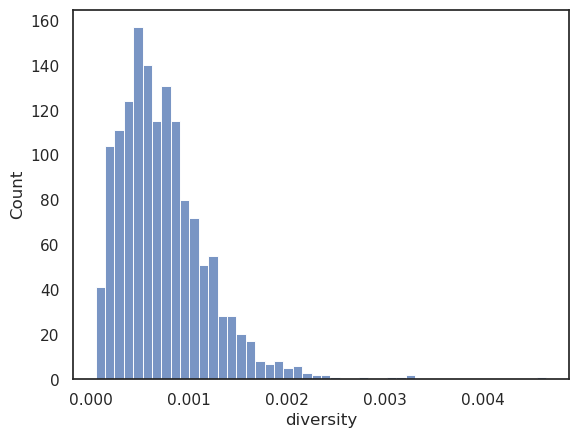

In [12]:
sns.histplot(i_diversity.diversity)

In [13]:
mean_diversity = diversity_df.groupby(["chrom", "start"])[["diversity"]].mean().reset_index()

<Axes: xlabel='diversity', ylabel='Count'>

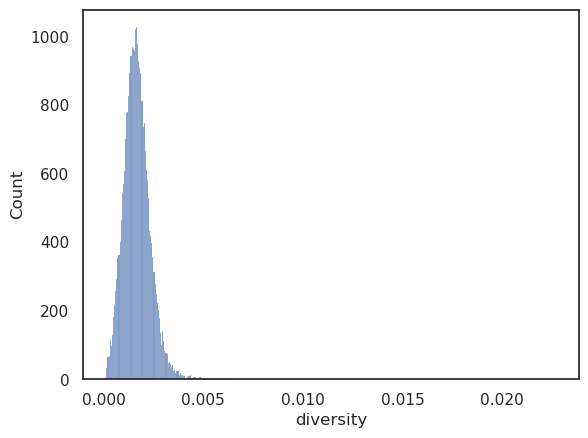

In [14]:
sns.histplot(mean_diversity.diversity)

[Text(0.5, 0, 'Background Diversity')]

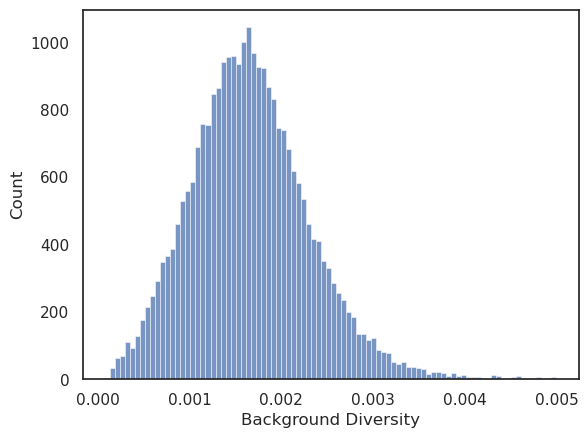

In [15]:
g = sns.histplot(mean_diversity.loc[mean_diversity.diversity <= 0.005].diversity)
g.set(xlabel = "Background Diversity")

In [16]:
metadata.Origin.unique()

array(['Mikumi, Tanzania', 'Chunga, Zambia', 'Awash, Ethiopia',
       'Serengeti, Tanzania', 'Arusha, Tanzania', 'Ngorongoro, Tanzania',
       'Ruaha, Tanzania', 'Gombe, Tanzania', 'Udzungwa, Tanzania',
       'Mahale, Tanzania', 'Selous, Tanzania', 'Lake Manyara, Tanzania',
       'Tarangire, Tanzania', 'Niokolo-Koba, Senegal',
       'Issa Valley, Tanzania', 'Dendro Park, Zambia', 'Filoha, Ethiopia',
       'Gog Woreda, Gambella region, Ethiopia'], dtype=object)

In [17]:
focus_pop_tags = ["Chunga, Zambia", "Dendro Park, Zambia", "Mikumi, Tanzania", "Mahale, Tanzania",
                  "Filoha, Ethiopia", "Serengeti, Tanzania", 'Gog Woreda, Gambella region, Ethiopia', "Niokolo-Koba, Senegal"]
window_size = 100000
all_chroms = ["chr{}".format(x) for x in (range(1, 21))]+["chrX"]

c_df_l = []
for c in all_chroms:
    print(c)
    zarr_dir = "/home/eriks/baboondiversity/data/PG_panu3_zarr_12_03_2021/callset.zarr/" + c
    #Opening the zarr data
    callset = zarr.open_group(zarr_dir, mode="r")
    gt = allel.GenotypeArray(callset["calldata/GT"])
    pos = callset["variants/POS"][:]
    # Loading in the IDs and gt
    df_l = []
    for p in focus_pop_tags:
        if c == "chrX":
            metadata = meta_data_samples_f
            focus_pop_gt = gt.take(metadata.loc[(metadata.Origin == p) &
                                            (metadata.Sex == "F")].callset_index,
                       axis=1)
        else:
            metadata = meta_data_samples
            focus_pop_gt = gt.take(metadata.loc[metadata.Origin == p].callset_index,
                       axis=1)
        pi, windows, n_bases, counts = allel.windowed_diversity(pos, focus_pop_gt.count_alleles(),
                          size=window_size, start=0)
        df_l.append(pd.DataFrame({"chrom": c, "population": p, "start": windows[:,0], "diversity": pi}))
    focus_df = pd.concat(df_l)
    if c == "chrX":
        rf_c = "female_chrX"
    elif c == "dipmale_chrX":
        rf_c = "all_chrX"
    else:
        rf_c = c
    print(c, rf_c)
    c_df_l.append(focus_df)

chr1
chr1 chr1
chr2
chr2 chr2
chr3
chr3 chr3
chr4
chr4 chr4
chr5
chr5 chr5
chr6
chr6 chr6
chr7
chr7 chr7
chr8
chr8 chr8
chr9
chr9 chr9
chr10
chr10 chr10
chr11
chr11 chr11
chr12
chr12 chr12
chr13
chr13 chr13
chr14
chr14 chr14
chr15
chr15 chr15
chr16
chr16 chr16
chr17
chr17 chr17
chr18
chr18 chr18
chr19
chr19 chr19
chr20
chr20 chr20
chrX
chrX female_chrX


In [18]:
diversity_df_large = pd.concat(c_df_l)

In [19]:
div_heatmap = np.array(np.zeros((len(focus_pop_tags), len(focus_pop_tags))))
for i in range(len(focus_pop_tags)):
    i_diversity = diversity_df_large.loc[(diversity_df_large.population == focus_pop_tags[i]) & (diversity_df_large.chrom != "chrX")]
    ix_diversity = diversity_df_large.loc[(diversity_df_large.population == focus_pop_tags[i]) & (diversity_df_large.chrom == "chrX")]
    for j in range(i):
        print(focus_pop_tags[i], focus_pop_tags[j])
        j_diversity = diversity_df_large.loc[(diversity_df_large.population == focus_pop_tags[j]) & (diversity_df_large.chrom != "chrX")]
        res = stats.spearmanr(i_diversity.diversity, j_diversity.diversity)
        div_heatmap[i][j] = res[0]
        print(res[1])
        jx_diversity = diversity_df_large.loc[(diversity_df_large.population == focus_pop_tags[j]) & (diversity_df_large.chrom == "chrX")]
        res = stats.spearmanr(ix_diversity.diversity, jx_diversity.diversity)
        div_heatmap[j][i] = res[0]
        print(res[1])

Dendro Park, Zambia Chunga, Zambia
0.0
1.1143770585473368e-75
Mikumi, Tanzania Chunga, Zambia
0.0
4.257045679768852e-225
Mikumi, Tanzania Dendro Park, Zambia
0.0
8.511345491385742e-69
Mahale, Tanzania Chunga, Zambia
0.0
5.57288235177727e-165
Mahale, Tanzania Dendro Park, Zambia
0.0
1.1302747202073556e-67
Mahale, Tanzania Mikumi, Tanzania
0.0
2.2746245644894826e-180
Filoha, Ethiopia Chunga, Zambia
0.0
2.2347572413170712e-139
Filoha, Ethiopia Dendro Park, Zambia
0.0
4.0976643589472404e-51
Filoha, Ethiopia Mikumi, Tanzania
0.0
2.425337235012867e-149
Filoha, Ethiopia Mahale, Tanzania
0.0
9.20788070379494e-109
Serengeti, Tanzania Chunga, Zambia
0.0
7.713625634611786e-129
Serengeti, Tanzania Dendro Park, Zambia
0.0
1.9767403240906492e-78
Serengeti, Tanzania Mikumi, Tanzania
0.0
3.320574976649038e-130
Serengeti, Tanzania Mahale, Tanzania
0.0
1.5879991069492964e-77
Serengeti, Tanzania Filoha, Ethiopia
0.0
4.671342125619374e-113
Gog Woreda, Gambella region, Ethiopia Chunga, Zambia
0.0
3.2265874

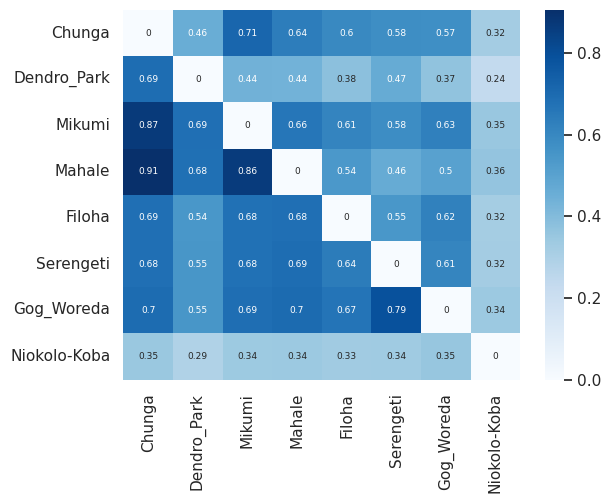

In [20]:
heatmap_df = pd.DataFrame(np.nan_to_num(div_heatmap), index = [x.replace(" ", "_").split(",")[0] for x in focus_pop_tags],
                         columns = [x.replace(" ", "_").split(",")[0] for x in focus_pop_tags])
g = sns.heatmap(heatmap_df, cmap=sns.color_palette("Blues", as_cmap=True), annot=True, annot_kws={"fontsize":6.5})


Second version, wherein I split based on origin.

In [21]:
window_df_tanz["Origin"] = window_df_tanz.individual.map(dict(zip(meta_data_samples_sci.PGDP_ID, meta_data_samples_sci.Origin)))

In [22]:
window_df_eth["Origin"] = window_df_eth.individual.map(dict(zip(meta_data_samples_sci.PGDP_ID, meta_data_samples_sci.Origin+"_eth_case")))

In [23]:
window_df_tanz_eth = pd.concat([window_df_tanz, window_df_eth])

In [24]:
mean_window_df_tanz_eth = window_df_tanz_eth.groupby(["chrom", "Origin", "start", "end"])[["north_sum"]].mean().reset_index()
mean_window_df_tanz = window_df_tanz.groupby(["chrom", "Origin", "start", "end"])[["north_sum"]].mean().reset_index()
admix_div_mean = mean_diversity.merge(mean_window_df_tanz_eth, on=["chrom", "start"])
admix_div_mean["Species"] = admix_div_mean.Origin.map(dict(zip(meta_data_samples_sci.Origin, meta_data_samples_sci.Species)))
admix_div_mean = admix_div_mean.merge(c_r_g_df, on=["chrom", "start"])
admix_div_mean = admix_div_mean.loc[admix_div_mean.chrom != "all_chrX"]
admix_div_mean["North Percentage"] = admix_div_mean.north_sum/100000
admix_div_mean["logdiv"] = np.log10(admix_div_mean.diversity)
admix_div_mean["logrecomb"] = np.log10(admix_div_mean.average_cM_window)
admix_div_mean["norm_diversity"] = (admix_div_mean.diversity-admix_div_mean.diversity.mean())/admix_div_mean.diversity.std()
admix_div_mean["norm_recomb"] = (admix_div_mean.average_cM_window-admix_div_mean.average_cM_window.mean())/admix_div_mean.average_cM_window.std()

In [25]:
#Selecting the cases of interest and setting Minor Parent Ancestry
origins_interest = ['Arusha, Tanzania',
       'Gog Woreda, Gambella region, Ethiopia',
       'Gog Woreda, Gambella region, Ethiopia_eth_case',
       'Gombe, Tanzania', 'Issa Valley, Tanzania',
       'Katavi, Tanzania','Lake Manyara, Tanzania',
       'Mahale, Tanzania',
       'Mikumi, Tanzania', 'Ngorongoro, Tanzania', 'Ruaha, Tanzania',
       'Selous, Tanzania', 'Serengeti, Tanzania', 'Tarangire, Tanzania',
       'Udzungwa, Tanzania']
admix_div_mean = admix_div_mean.loc[admix_div_mean.Origin.isin(origins_interest)]
admix_div_mean["minor_parent_percentage"] = [x if y == ("cynocephalus") or z == "Gog Woreda, Gambella region, Ethiopia_eth_case"
                                             else 1-x for x, y, z in zip(admix_div_mean["North Percentage"],
                                                                         admix_div_mean["Species"],
                                                                        admix_div_mean["Origin"])]
admix_div_mean["local_minor_ancestry"] = [min(x, 1-x) for x in admix_div_mean["North Percentage"]]

In [26]:
#Kasper prep
#kasper_div = window_df_tanz
#kasper_div["Origin"] = window_df_tanz.individual.map(dict(zip(meta_data_samples_sci.PGDP_ID, meta_data_samples_sci.Origin)))
#kasper_div = mean_diversity.merge(kasper_div, on=["chrom", "start"])
#kasper_div.to_csv("../data/autosome_diversity_admixture.txt", index=False)

<Axes: xlabel='diversity', ylabel='minor_parent_percentage'>

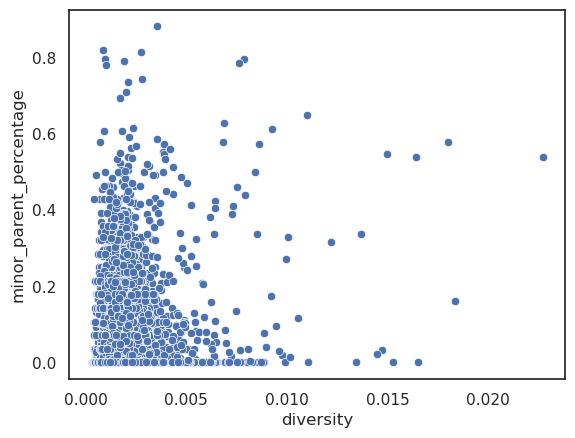

In [27]:
sns.scatterplot(admix_div_mean.loc[admix_div_mean.Origin == "Serengeti, Tanzania"], x="diversity", y="minor_parent_percentage")

<Axes: xlabel='diversity', ylabel='Count'>

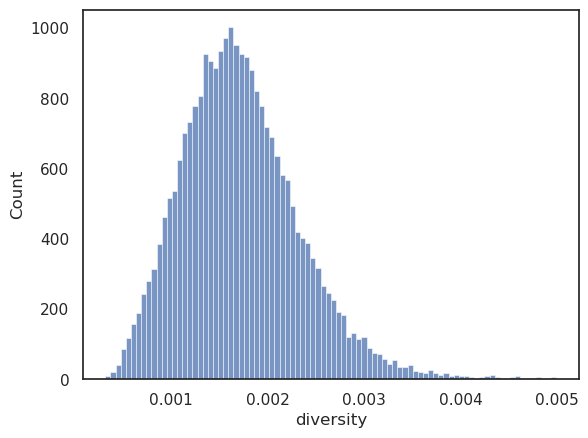

In [28]:
sns.histplot(admix_div_mean.loc[(admix_div_mean.Origin == "Serengeti, Tanzania") &
                               (admix_div_mean.diversity <= 0.005)], x="diversity")

<Axes: xlabel='diversity', ylabel='minor_parent_percentage'>

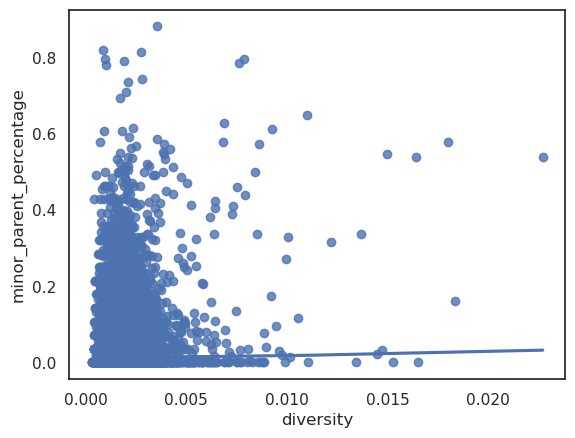

In [29]:
sns.regplot(admix_div_mean.loc[admix_div_mean.Origin == "Serengeti, Tanzania"], x="diversity", y="minor_parent_percentage", lowess=True)

<Axes: xlabel='diversity', ylabel='minor_parent_percentage'>

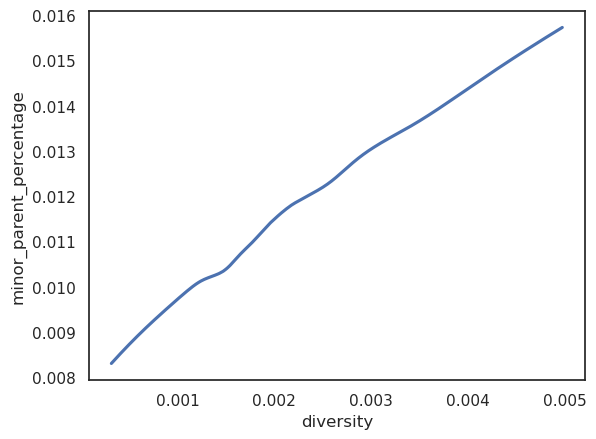

In [30]:
sns.regplot(admix_div_mean.loc[(admix_div_mean.Origin == "Serengeti, Tanzania") &
                              (admix_div_mean["minor_parent_percentage"] < 0.5) &
                               (admix_div_mean["diversity"] < 0.005) & 
                              (admix_div_mean.callable_frac > 0.9)], x="diversity", y="minor_parent_percentage",
                            lowess=True, ci=95, scatter=False)

<Axes: xlabel='average_cM_window', ylabel='diversity'>

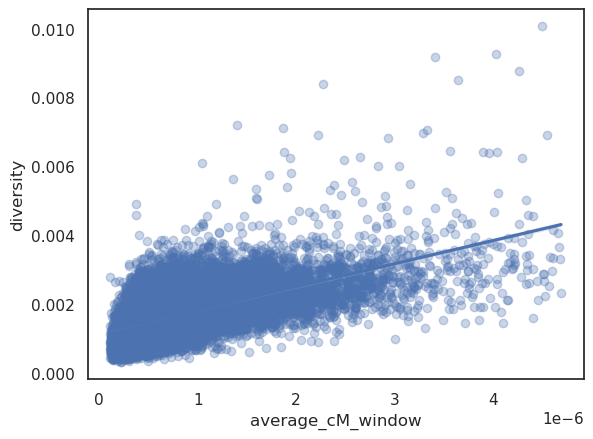

In [31]:
sns.regplot(admix_div_mean.loc[(admix_div_mean.Origin == "Serengeti, Tanzania") &
                              #(admix_div_mean["minor_parent_percentage"] < 0.5) &
                               (admix_div_mean["average_cM_window"] < 4.710987e-06) & 
                               (admix_div_mean["average_cM_window"] > 0.110987e-06) & 
                              (admix_div_mean.callable_frac > 0.75)], x="average_cM_window", y="diversity",
                            ci=95, scatter_kws={'alpha':0.3})

[Text(0, 0.5, 'Background Diversity'),
 Text(0.5, 0, 'Recombination across window (cM)')]

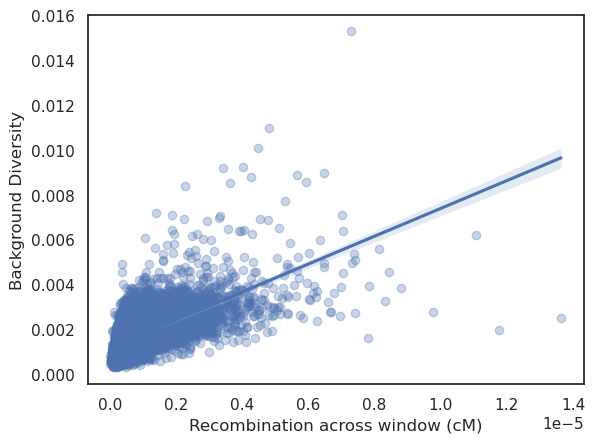

In [32]:
g = sns.regplot(admix_div_mean.loc[(admix_div_mean.Origin == "Serengeti, Tanzania") &
                              (admix_div_mean.callable_frac > 0.75)], x="average_cM_window", y="diversity",
                            ci=95, 
                scatter_kws={'alpha':0.3})
g.set(ylabel = "Background Diversity", xlabel="Recombination across window (cM)")

In [33]:
admix_div_mean.loc[(admix_div_mean.Origin == "Serengeti, Tanzania")]

,chrom,start,diversity,Origin,end_x,north_sum,Species,callable_frac,end_y,cM,...,average_cM_window,genes,genic,North Percentage,logdiv,logrecomb,norm_diversity,norm_recomb,minor_parent_percentage,local_minor_ancestry
19,chr1,0,0.00306,"Serengeti, Tanzania",100000,9.98e+04,anubis,0.795,100000,0,...,3.6e-06,"['RNF223', 'C1H1orf159', 'C1H1orf159', 'C1H1or...",True,0.998,-2.51,-5.44,1.69,2.91,0.0016,0.0016
41,chr1,100000,0.00191,"Serengeti, Tanzania",200000,1e+05,anubis,0.89,200000,0.36,...,1.16e-06,"['TTLL10', 'TTLL10', 'TTLL10', 'TTLL10', 'TTLL...",True,1,-2.72,-5.93,0.205,0.298,0,0
63,chr1,200000,0.00115,"Serengeti, Tanzania",300000,1e+05,anubis,0.919,300000,0.477,...,7.05e-07,"['B3GALT6', 'C1QTNF12', 'UBE2J2', 'UBE2J2', 'U...",True,1,-2.94,-6.15,-0.768,-0.19,0,0
85,chr1,300000,0.000888,"Serengeti, Tanzania",400000,1e+05,anubis,0.878,400000,0.547,...,7.94e-07,"['DVL1', 'DVL1', 'DVL1', 'MXRA8', 'MXRA8', 'MX...",True,1,-3.05,-6.1,-1.11,-0.0952,0,0
107,chr1,400000,0.00453,"Serengeti, Tanzania",500000,1e+05,anubis,0.485,500000,0.626,...,7.4e-06,"['VWA1', 'TMEM240', 'SSU72']",True,1,-2.34,-5.13,3.58,6.97,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
532553,chr9,125300000,0.00246,"Serengeti, Tanzania",125400000,1e+05,anubis,0.878,125400000,114,...,1.51e-06,"['UTF1', 'VENTX', 'ADAM8', 'ADAM8', 'ADAM8', '...",True,1,-2.61,-5.82,0.919,0.667,0,0
532575,chr9,125400000,0.00204,"Serengeti, Tanzania",125500000,1e+05,anubis,0.87,125500000,115,...,1.8e-06,"['CALY', 'CALY', 'CALY', 'PRAP1', 'PRAP1', 'FU...",True,1,-2.69,-5.74,0.376,0.982,7.14e-07,7.14e-07
532597,chr9,125500000,0.00197,"Serengeti, Tanzania",125600000,1e+05,anubis,0.864,125600000,115,...,2.12e-06,[],False,1,-2.71,-5.67,0.287,1.32,0,0
532619,chr9,125600000,0.0023,"Serengeti, Tanzania",125700000,1e+05,anubis,0.869,125700000,115,...,2.63e-06,"['SYCE1', 'SYCE1']",True,1,-2.64,-5.58,0.708,1.87,0,0


In [34]:
stats.pearsonr(admix_div_mean.loc[(admix_div_mean.callable_frac > 0.75)].average_cM_window,
               admix_div_mean.loc[(admix_div_mean.callable_frac > 0.75)].diversity)

PearsonRResult(statistic=0.6013617907835609, pvalue=0.0)

In [35]:
stats.spearmanr(admix_div_mean.loc[(admix_div_mean.callable_frac > 0.75)].average_cM_window,
                admix_div_mean.loc[(admix_div_mean.callable_frac > 0.75)].diversity)

SignificanceResult(statistic=0.6160928806937094, pvalue=0.0)

In [36]:
admix_div_mean.loc[(admix_div_mean.callable_frac > 0.75)
                   & (admix_div_mean.Origin == "Serengeti, Tanzania")].diversity.mean(), admix_div_mean.loc[(admix_div_mean.callable_frac > 0.75)
                   & (admix_div_mean.Origin == "Serengeti, Tanzania")].diversity.median()

(0.0017245076605363653, 0.001658228842197082)

<Axes: xlabel='average_cM_window', ylabel='Count'>

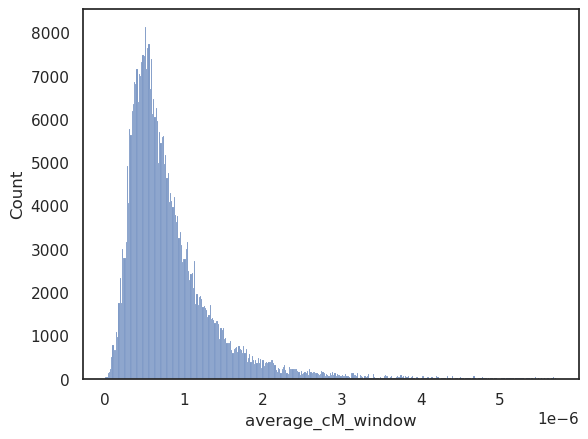

In [37]:
sns.histplot(admix_div_mean.loc[(admix_div_mean["average_cM_window"] < 5.710987e-06)], x="average_cM_window")

<Axes: xlabel='diversity', ylabel='minor_parent_percentage'>

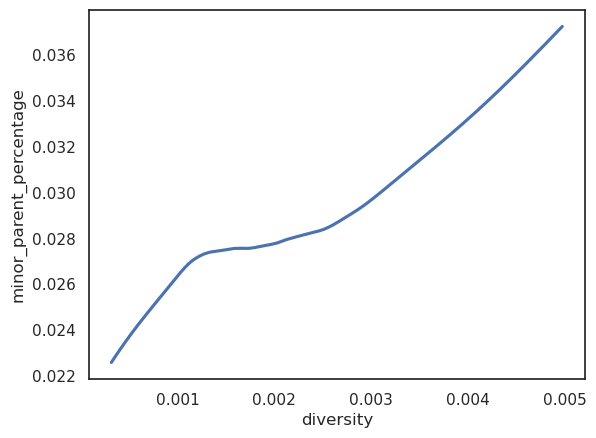

In [38]:
sns.regplot(admix_div_mean.loc[(admix_div_mean.Origin == "Lake Manyara, Tanzania") &
                              (admix_div_mean["minor_parent_percentage"] < 0.5) &
                               (admix_div_mean["diversity"] < 0.005) & 
                              (admix_div_mean.callable_frac > 0.9)], x="diversity", y="minor_parent_percentage",
                            lowess=True, ci=95, scatter=False)

In [39]:
yellows = ['Mikumi, Tanzania', 'Ruaha, Tanzania', 'Selous, Tanzania', 'Udzungwa, Tanzania']
olives = ['Serengeti, Tanzania', 'Ngorongoro, Tanzania', 'Gombe, Tanzania',
          'Lake Manyara, Tanzania','Arusha, Tanzania']
olives_with_tarangire = ['Serengeti, Tanzania', 'Tarangire, Tanzania', 'Ngorongoro, Tanzania', 'Gombe, Tanzania',
          'Lake Manyara, Tanzania','Arusha, Tanzania']
gog = ['Gog Woreda, Ethiopia']
result_order = ['Selous, Tanzania', 'Mikumi, Tanzania', 'Udzungwa, Tanzania', 'Ruaha, Tanzania',
       'Tarangire, Tanzania', 'Arusha, Tanzania', 'Ngorongoro, Tanzania', 'Gombe, Tanzania', 
             'Lake Manyara, Tanzania', 'Serengeti, Tanzania', 'Gog Woreda, Ethiopia']
result_order_no_gog = ['Selous, Tanzania', 'Mikumi, Tanzania', 'Udzungwa, Tanzania', 'Ruaha, Tanzania',
       'Arusha, Tanzania', 'Ngorongoro, Tanzania', 'Gombe, Tanzania', 
             'Lake Manyara, Tanzania', 'Serengeti, Tanzania']

In [40]:
import copy
from textwrap import dedent
import warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

try:
    import statsmodels
    assert statsmodels
    _has_statsmodels = True
except ImportError:
    _has_statsmodels = False

from seaborn import utils
from seaborn import algorithms as algo
from seaborn.axisgrid import FacetGrid, _facet_docs


__all__ = ["lmplot", "regplot", "residplot"]


class _LinearPlotter:
    """Base class for plotting relational data in tidy format.

    To get anything useful done you'll have to inherit from this, but setup
    code that can be abstracted out should be put here.

    """
    def establish_variables(self, data, **kws):
        """Extract variables from data or use directly."""
        self.data = data

        # Validate the inputs
        any_strings = any([isinstance(v, str) for v in kws.values()])
        if any_strings and data is None:
            raise ValueError("Must pass `data` if using named variables.")

        # Set the variables
        for var, val in kws.items():
            if isinstance(val, str):
                vector = data[val]
            elif isinstance(val, list):
                vector = np.asarray(val)
            else:
                vector = val
            if vector is not None and vector.shape != (1,):
                vector = np.squeeze(vector)
            if np.ndim(vector) > 1:
                err = "regplot inputs must be 1d"
                raise ValueError(err)
            setattr(self, var, vector)

    def dropna(self, *vars):
        """Remove observations with missing data."""
        vals = [getattr(self, var) for var in vars]
        vals = [v for v in vals if v is not None]
        not_na = np.all(np.column_stack([pd.notnull(v) for v in vals]), axis=1)
        for var in vars:
            val = getattr(self, var)
            if val is not None:
                setattr(self, var, val[not_na])

    def plot(self, ax):
        raise NotImplementedError


class _RegressionPlotter(_LinearPlotter):
    """Plotter for numeric independent variables with regression model.

    This does the computations and drawing for the `regplot` function, and
    is thus also used indirectly by `lmplot`.
    """
    def __init__(self, x, y, data=None, x_estimator=None, x_bins=None,
                 x_ci="ci", scatter=True, fit_reg=True, ci=95, n_boot=1000,
                 units=None, seed=None, order=1, logistic=False, lowess=False,
                 robust=False, weighted=False, logx=False, x_partial=None, y_partial=None,
                 truncate=False, dropna=True, x_jitter=None, y_jitter=None,
                 color=None, label=None):

        # Set member attributes
        self.x_estimator = x_estimator
        self.ci = ci
        self.x_ci = ci if x_ci == "ci" else x_ci
        self.n_boot = n_boot
        self.seed = seed
        self.scatter = scatter
        self.fit_reg = fit_reg
        self.order = order
        self.logistic = logistic
        self.weighted = weighted
        self.lowess = lowess
        self.robust = robust
        self.logx = logx
        self.truncate = truncate
        self.x_jitter = x_jitter
        self.y_jitter = y_jitter
        self.color = color
        self.label = label

        # Validate the regression options:
        #if sum((order > 1, logistic, robust, weighted, lowess, logx)) > 1:
        #    raise ValueError("Mutually exclusive regression options.")

        # Extract the data vals from the arguments or passed dataframe
        self.establish_variables(data, x=x, y=y, units=units,
                                 x_partial=x_partial, y_partial=y_partial)

        # Drop null observations
        if dropna:
            self.dropna("x", "y", "units", "x_partial", "y_partial")

        # Regress nuisance variables out of the data
        if self.x_partial is not None:
            self.x = self.regress_out(self.x, self.x_partial)
        if self.y_partial is not None:
            self.y = self.regress_out(self.y, self.y_partial)

        # Possibly bin the predictor variable, which implies a point estimate
        if x_bins is not None:
            self.x_estimator = np.mean if x_estimator is None else x_estimator
            x_discrete, x_bins = self.bin_predictor(x_bins)
            self.x_discrete = x_discrete
        else:
            self.x_discrete = self.x

        # Disable regression in case of singleton inputs
        if len(self.x) <= 1:
            self.fit_reg = False

        # Save the range of the x variable for the grid later
        if self.fit_reg:
            self.x_range = self.x.min(), self.x.max()

    @property
    def scatter_data(self):
        """Data where each observation is a point."""
        x_j = self.x_jitter
        if x_j is None:
            x = self.x
        else:
            x = self.x + np.random.uniform(-x_j, x_j, len(self.x))

        y_j = self.y_jitter
        if y_j is None:
            y = self.y
        else:
            y = self.y + np.random.uniform(-y_j, y_j, len(self.y))

        return x, y

    @property
    def estimate_data(self):
        """Data with a point estimate and CI for each discrete x value."""
        x, y = self.x_discrete, self.y
        vals = sorted(np.unique(x))
        points, cis = [], []

        for val in vals:

            # Get the point estimate of the y variable
            _y = y[x == val]
            est = self.x_estimator(_y)
            points.append(est)

            # Compute the confidence interval for this estimate
            if self.x_ci is None:
                cis.append(None)
            else:
                units = None
                if self.x_ci == "sd":
                    sd = np.std(_y)
                    _ci = est - sd, est + sd
                else:
                    if self.units is not None:
                        units = self.units[x == val]
                    boots = algo.bootstrap(_y,
                                           func=self.x_estimator,
                                           n_boot=self.n_boot,
                                           units=units,
                                           seed=self.seed)
                    _ci = utils.ci(boots, self.x_ci)
                cis.append(_ci)

        return vals, points, cis

    def _check_statsmodels(self):
        """Check whether statsmodels is installed if any boolean options require it."""
        options = "logistic", "robust", "lowess"
        err = "`{}=True` requires statsmodels, an optional dependency, to be installed."
        for option in options:
            if getattr(self, option) and not _has_statsmodels:
                raise RuntimeError(err.format(option))

    def fit_regression(self, ax=None, x_range=None, grid=None):
        """Fit the regression model."""
        self._check_statsmodels()

        # Create the grid for the regression
        if grid is None:
            if self.truncate:
                x_min, x_max = self.x_range
            else:
                if ax is None:
                    x_min, x_max = x_range
                else:
                    x_min, x_max = ax.get_xlim()
            grid = np.linspace(x_min, x_max, 100)
        ci = self.ci

        # Fit the regression
        if self.order > 1:
            yhat, yhat_boots = self.fit_poly(grid, self.order)
        elif self.logistic: 
            from statsmodels.genmod.generalized_linear_model import GLM
            from statsmodels.genmod.families import Binomial
            yhat, yhat_boots = self.fit_statsmodels(grid, GLM,
                                                    family=Binomial())
        elif self.weighted: 
            from statsmodels.genmod.generalized_linear_model import GLM
            from statsmodels.genmod.families import Binomial
            yhat, yhat_boots = self.fit_statsmodels(grid, GLM,
                                                   var_weights=np.asarray(self.x))
        elif self.lowess:
            ci = None
            grid, yhat = self.fit_lowess()
        elif self.robust:
            from statsmodels.robust.robust_linear_model import RLM
            yhat, yhat_boots = self.fit_statsmodels(grid, RLM)
        elif self.logx:
            yhat, yhat_boots = self.fit_logx(grid)
        else:
            yhat, yhat_boots = self.fit_fast(grid)

        # Compute the confidence interval at each grid point
        if ci is None:
            err_bands = None
        else:
            err_bands = utils.ci(yhat_boots, ci, axis=0)

        return grid, yhat, err_bands

    def fit_fast(self, grid):
        """Low-level regression and prediction using linear algebra."""
        def reg_func(_x, _y):
            return np.linalg.pinv(_x).dot(_y)

        X, y = np.c_[np.ones(len(self.x)), self.x], self.y
        grid = np.c_[np.ones(len(grid)), grid]
        yhat = grid.dot(reg_func(X, y))
        if self.ci is None:
            return yhat, None

        beta_boots = algo.bootstrap(X, y,
                                    func=reg_func,
                                    n_boot=self.n_boot,
                                    units=self.units,
                                    seed=self.seed).T
        yhat_boots = grid.dot(beta_boots).T
        return yhat, yhat_boots

    def fit_poly(self, grid, order):
        """Regression using numpy polyfit for higher-order trends."""
        def reg_func(_x, _y):
            return np.polyval(np.polyfit(_x, _y, order), grid)

        x, y = self.x, self.y
        yhat = reg_func(x, y)
        if self.ci is None:
            return yhat, None

        yhat_boots = algo.bootstrap(x, y,
                                    func=reg_func,
                                    n_boot=self.n_boot,
                                    units=self.units,
                                    seed=self.seed)
        return yhat, yhat_boots

    def fit_statsmodels(self, grid, model, **kwargs):
        """More general regression function using statsmodels objects."""
        import statsmodels.tools.sm_exceptions as sme
        X, y = np.c_[np.ones(len(self.x)), self.x], self.y
        grid = np.c_[np.ones(len(grid)), grid]
        def reg_func(_x, _y, **kwargs):
            err_classes = (sme.PerfectSeparationError,)
            try:
                with warnings.catch_warnings():
                    if hasattr(sme, "PerfectSeparationWarning"):
                        # statsmodels>=0.14.0
                        warnings.simplefilter("error", sme.PerfectSeparationWarning)
                        err_classes = (*err_classes, sme.PerfectSeparationWarning)
                    m = model(_y, _x, var_weights=np.asarray(_x[:, 1])).fit()
                    yhat = m.predict(grid)
                    #print(m.summary(), self.x, len(_x), _x[:, 1])
            except err_classes:
                yhat = np.empty(len(grid))
                yhat.fill(np.nan)
            return yhat

        yhat = reg_func(X, y, **kwargs)
        if self.ci is None:
            return yhat, None

        yhat_boots = bootstrap(X, y,
                                    func=reg_func,
                                    n_boot=self.n_boot,
                                    units=self.units,
                                    seed=self.seed,
                                   var_weights=np.asarray(self.x))
        return yhat, yhat_boots

    def fit_lowess(self):
        """Fit a locally-weighted regression, which returns its own grid."""
        from statsmodels.nonparametric.smoothers_lowess import lowess
        grid, yhat = lowess(self.y, self.x).T
        return grid, yhat

    def fit_logx(self, grid):
        """Fit the model in log-space."""
        X, y = np.c_[np.ones(len(self.x)), self.x], self.y
        grid = np.c_[np.ones(len(grid)), np.log(grid)]

        def reg_func(_x, _y):
            _x = np.c_[_x[:, 0], np.log(_x[:, 1])]
            return np.linalg.pinv(_x).dot(_y)

        yhat = grid.dot(reg_func(X, y))
        if self.ci is None:
            return yhat, None

        beta_boots = algo.bootstrap(X, y,
                                    func=reg_func,
                                    n_boot=self.n_boot,
                                    units=self.units,
                                    seed=self.seed).T
        yhat_boots = grid.dot(beta_boots).T
        return yhat, yhat_boots

    def bin_predictor(self, bins):
        """Discretize a predictor by assigning value to closest bin."""
        x = np.asarray(self.x)
        if np.isscalar(bins):
            percentiles = np.linspace(0, 100, bins + 2)[1:-1]
            bins = np.percentile(x, percentiles)
        else:
            bins = np.ravel(bins)

        dist = np.abs(np.subtract.outer(x, bins))
        x_binned = bins[np.argmin(dist, axis=1)].ravel()

        return x_binned, bins

    def regress_out(self, a, b):
        """Regress b from a keeping a's original mean."""
        a_mean = a.mean()
        a = a - a_mean
        b = b - b.mean()
        b = np.c_[b]
        a_prime = a - b.dot(np.linalg.pinv(b).dot(a))
        return np.asarray(a_prime + a_mean).reshape(a.shape)

    def plot(self, ax, scatter_kws, line_kws):
        """Draw the full plot."""
        # Insert the plot label into the correct set of keyword arguments
        if self.scatter:
            scatter_kws["label"] = self.label
        else:
            line_kws["label"] = self.label

        # Use the current color cycle state as a default
        if self.color is None:
            lines, = ax.plot([], [])
            color = lines.get_color()
            lines.remove()
        else:
            color = self.color

        # Ensure that color is hex to avoid matplotlib weirdness
        color = mpl.colors.rgb2hex(mpl.colors.colorConverter.to_rgb(color))

        # Let color in keyword arguments override overall plot color
        scatter_kws.setdefault("color", color)
        line_kws.setdefault("color", color)

        # Draw the constituent plots
        if self.scatter:
            self.scatterplot(ax, scatter_kws)

        if self.fit_reg:
            self.lineplot(ax, line_kws)

        # Label the axes
        if hasattr(self.x, "name"):
            ax.set_xlabel(self.x.name)
        if hasattr(self.y, "name"):
            ax.set_ylabel(self.y.name)

    def scatterplot(self, ax, kws):
        """Draw the data."""
        # Treat the line-based markers specially, explicitly setting larger
        # linewidth than is provided by the seaborn style defaults.
        # This would ideally be handled better in matplotlib (i.e., distinguish
        # between edgewidth for solid glyphs and linewidth for line glyphs
        # but this should do for now.
        line_markers = ["1", "2", "3", "4", "+", "x", "|", "_"]
        if self.x_estimator is None:
            if "marker" in kws and kws["marker"] in line_markers:
                lw = mpl.rcParams["lines.linewidth"]
            else:
                lw = mpl.rcParams["lines.markeredgewidth"]
            kws.setdefault("linewidths", lw)

            if not hasattr(kws['color'], 'shape') or kws['color'].shape[1] < 4:
                kws.setdefault("alpha", .8)

            x, y = self.scatter_data
            ax.scatter(x, y, **kws)
        else:
            # TODO abstraction
            ci_kws = {"color": kws["color"]}
            if "alpha" in kws:
                ci_kws["alpha"] = kws["alpha"]
            ci_kws["linewidth"] = mpl.rcParams["lines.linewidth"] * 1.75
            kws.setdefault("s", 50)

            xs, ys, cis = self.estimate_data
            if [ci for ci in cis if ci is not None]:
                for x, ci in zip(xs, cis):
                    ax.plot([x, x], ci, **ci_kws)
            ax.scatter(xs, ys, **kws)

    def lineplot(self, ax, kws):
        """Draw the model."""
        # Fit the regression model
        grid, yhat, err_bands = self.fit_regression(ax)
        edges = grid[0], grid[-1]

        # Get set default aesthetics
        fill_color = kws["color"]
        lw = kws.pop("lw", mpl.rcParams["lines.linewidth"] * 1.5)
        kws.setdefault("linewidth", lw)

        # Draw the regression line and confidence interval
        line, = ax.plot(grid, yhat, **kws)
        if not self.truncate:
            line.sticky_edges.x[:] = edges  # Prevent mpl from adding margin
        if err_bands is not None:
            ax.fill_between(grid, *err_bands, facecolor=fill_color, alpha=.15)


_regression_docs = dict(

    model_api=dedent("""\
    There are a number of mutually exclusive options for estimating the
    regression model. See the :ref:`tutorial <regression_tutorial>` for more
    information.\
    """),
    regplot_vs_lmplot=dedent("""\
    The :func:`regplot` and :func:`lmplot` functions are closely related, but
    the former is an axes-level function while the latter is a figure-level
    function that combines :func:`regplot` and :class:`FacetGrid`.\
    """),
    x_estimator=dedent("""\
    x_estimator : callable that maps vector -> scalar, optional
        Apply this function to each unique value of ``x`` and plot the
        resulting estimate. This is useful when ``x`` is a discrete variable.
        If ``x_ci`` is given, this estimate will be bootstrapped and a
        confidence interval will be drawn.\
    """),
    x_bins=dedent("""\
    x_bins : int or vector, optional
        Bin the ``x`` variable into discrete bins and then estimate the central
        tendency and a confidence interval. This binning only influences how
        the scatterplot is drawn; the regression is still fit to the original
        data.  This parameter is interpreted either as the number of
        evenly-sized (not necessary spaced) bins or the positions of the bin
        centers. When this parameter is used, it implies that the default of
        ``x_estimator`` is ``numpy.mean``.\
    """),
    x_ci=dedent("""\
    x_ci : "ci", "sd", int in [0, 100] or None, optional
        Size of the confidence interval used when plotting a central tendency
        for discrete values of ``x``. If ``"ci"``, defer to the value of the
        ``ci`` parameter. If ``"sd"``, skip bootstrapping and show the
        standard deviation of the observations in each bin.\
    """),
    scatter=dedent("""\
    scatter : bool, optional
        If ``True``, draw a scatterplot with the underlying observations (or
        the ``x_estimator`` values).\
    """),
    fit_reg=dedent("""\
    fit_reg : bool, optional
        If ``True``, estimate and plot a regression model relating the ``x``
        and ``y`` variables.\
    """),
    ci=dedent("""\
    ci : int in [0, 100] or None, optional
        Size of the confidence interval for the regression estimate. This will
        be drawn using translucent bands around the regression line. The
        confidence interval is estimated using a bootstrap; for large
        datasets, it may be advisable to avoid that computation by setting
        this parameter to None.\
    """),
    n_boot=dedent("""\
    n_boot : int, optional
        Number of bootstrap resamples used to estimate the ``ci``. The default
        value attempts to balance time and stability; you may want to increase
        this value for "final" versions of plots.\
    """),
    units=dedent("""\
    units : variable name in ``data``, optional
        If the ``x`` and ``y`` observations are nested within sampling units,
        those can be specified here. This will be taken into account when
        computing the confidence intervals by performing a multilevel bootstrap
        that resamples both units and observations (within unit). This does not
        otherwise influence how the regression is estimated or drawn.\
    """),
    seed=dedent("""\
    seed : int, numpy.random.Generator, or numpy.random.RandomState, optional
        Seed or random number generator for reproducible bootstrapping.\
    """),
    order=dedent("""\
    order : int, optional
        If ``order`` is greater than 1, use ``numpy.polyfit`` to estimate a
        polynomial regression.\
    """),
    logistic=dedent("""\
    logistic : bool, optional
        If ``True``, assume that ``y`` is a binary variable and use
        ``statsmodels`` to estimate a logistic regression model. Note that this
        is substantially more computationally intensive than linear regression,
        so you may wish to decrease the number of bootstrap resamples
        (``n_boot``) or set ``ci`` to None.\
    """),
    lowess=dedent("""\
    lowess : bool, optional
        If ``True``, use ``statsmodels`` to estimate a nonparametric lowess
        model (locally weighted linear regression). Note that confidence
        intervals cannot currently be drawn for this kind of model.\
    """),
    robust=dedent("""\
    robust : bool, optional
        If ``True``, use ``statsmodels`` to estimate a robust regression. This
        will de-weight outliers. Note that this is substantially more
        computationally intensive than standard linear regression, so you may
        wish to decrease the number of bootstrap resamples (``n_boot``) or set
        ``ci`` to None.\
    """),
    logx=dedent("""\
    logx : bool, optional
        If ``True``, estimate a linear regression of the form y ~ log(x), but
        plot the scatterplot and regression model in the input space. Note that
        ``x`` must be positive for this to work.\
    """),
    xy_partial=dedent("""\
    {x,y}_partial : strings in ``data`` or matrices
        Confounding variables to regress out of the ``x`` or ``y`` variables
        before plotting.\
    """),
    truncate=dedent("""\
    truncate : bool, optional
        If ``True``, the regression line is bounded by the data limits. If
        ``False``, it extends to the ``x`` axis limits.
    """),
    dropna=dedent("""\
    dropna : bool, optional
        If ``True``, remove observations with missing data from the plot.
    """),
    xy_jitter=dedent("""\
    {x,y}_jitter : floats, optional
        Add uniform random noise of this size to either the ``x`` or ``y``
        variables. The noise is added to a copy of the data after fitting the
        regression, and only influences the look of the scatterplot. This can
        be helpful when plotting variables that take discrete values.\
    """),
    scatter_line_kws=dedent("""\
    {scatter,line}_kws : dictionaries
        Additional keyword arguments to pass to ``plt.scatter`` and
        ``plt.plot``.\
    """),
)
_regression_docs.update(_facet_docs)


def lmplot(
    data, *,
    x=None, y=None, hue=None, col=None, row=None,
    palette=None, col_wrap=None, height=5, aspect=1, markers="o",
    sharex=None, sharey=None, hue_order=None, col_order=None, row_order=None,
    legend=True, legend_out=None, x_estimator=None, x_bins=None,
    x_ci="ci", scatter=True, fit_reg=True, ci=95, n_boot=1000,
    units=None, seed=None, order=1, logistic=False, lowess=False,
    robust=False, weighted=False, logx=False, x_partial=None, y_partial=None,
    truncate=True, x_jitter=None, y_jitter=None, scatter_kws=None,
    line_kws=None, facet_kws=None,
):

    if facet_kws is None:
        facet_kws = {}

    def facet_kw_deprecation(key, val):
        msg = (
            f"{key} is deprecated from the `lmplot` function signature. "
            "Please update your code to pass it using `facet_kws`."
        )
        if val is not None:
            warnings.warn(msg, UserWarning)
            facet_kws[key] = val

    facet_kw_deprecation("sharex", sharex)
    facet_kw_deprecation("sharey", sharey)
    facet_kw_deprecation("legend_out", legend_out)

    if data is None:
        raise TypeError("Missing required keyword argument `data`.")

    # Reduce the dataframe to only needed columns
    need_cols = [x, y, hue, col, row, units, x_partial, y_partial]
    cols = np.unique([a for a in need_cols if a is not None]).tolist()
    data = data[cols]

    # Initialize the grid
    facets = FacetGrid(
        data, row=row, col=col, hue=hue,
        palette=palette,
        row_order=row_order, col_order=col_order, hue_order=hue_order,
        height=height, aspect=aspect, col_wrap=col_wrap,
        **facet_kws,
    )

    # Add the markers here as FacetGrid has figured out how many levels of the
    # hue variable are needed and we don't want to duplicate that process
    if facets.hue_names is None:
        n_markers = 1
    else:
        n_markers = len(facets.hue_names)
    if not isinstance(markers, list):
        markers = [markers] * n_markers
    if len(markers) != n_markers:
        raise ValueError("markers must be a singleton or a list of markers "
                         "for each level of the hue variable")
    facets.hue_kws = {"marker": markers}

    #def update_datalim(data, x, y, ax, **kws):
    #    xys = data[[x, y]].to_numpy().astype(float)
    #    ax.update_datalim(xys, updatey=False)
    #    ax.autoscale_view(scaley=False)

    #facets.map_dataframe(update_datalim, x=x, y=y)

    # Draw the regression plot on each facet
    regplot_kws = dict(
        x_estimator=x_estimator, x_bins=x_bins, x_ci=x_ci,
        scatter=scatter, fit_reg=fit_reg, ci=ci, n_boot=n_boot, units=units,
        seed=seed, order=order, logistic=logistic, lowess=lowess,
        robust=robust, weighted=weighted, logx=logx, x_partial=x_partial, y_partial=y_partial,
        truncate=truncate, x_jitter=x_jitter, y_jitter=y_jitter,
        scatter_kws=scatter_kws, line_kws=line_kws,
    )
    facets.map_dataframe(regplot, x=x, y=y, **regplot_kws)
    facets.set_axis_labels(x, y)

    # Add a legend
    if legend and (hue is not None) and (hue not in [col, row]):
        facets.add_legend()
    return facets


lmplot.__doc__ = dedent("""\
    Plot data and regression model fits across a FacetGrid.

    This function combines :func:`regplot` and :class:`FacetGrid`. It is
    intended as a convenient interface to fit regression models across
    conditional subsets of a dataset.

    When thinking about how to assign variables to different facets, a general
    rule is that it makes sense to use ``hue`` for the most important
    comparison, followed by ``col`` and ``row``. However, always think about
    your particular dataset and the goals of the visualization you are
    creating.

    {model_api}

    The parameters to this function span most of the options in
    :class:`FacetGrid`, although there may be occasional cases where you will
    want to use that class and :func:`regplot` directly.

    Parameters
    ----------
    {data}
    x, y : strings, optional
        Input variables; these should be column names in ``data``.
    hue, col, row : strings
        Variables that define subsets of the data, which will be drawn on
        separate facets in the grid. See the ``*_order`` parameters to control
        the order of levels of this variable.
    {palette}
    {col_wrap}
    {height}
    {aspect}
    markers : matplotlib marker code or list of marker codes, optional
        Markers for the scatterplot. If a list, each marker in the list will be
        used for each level of the ``hue`` variable.
    {share_xy}

        .. deprecated:: 0.12.0
            Pass using the `facet_kws` dictionary.

    {{hue,col,row}}_order : lists, optional
        Order for the levels of the faceting variables. By default, this will
        be the order that the levels appear in ``data`` or, if the variables
        are pandas categoricals, the category order.
    legend : bool, optional
        If ``True`` and there is a ``hue`` variable, add a legend.
    {legend_out}

        .. deprecated:: 0.12.0
            Pass using the `facet_kws` dictionary.

    {x_estimator}
    {x_bins}
    {x_ci}
    {scatter}
    {fit_reg}
    {ci}
    {n_boot}
    {units}
    {seed}
    {order}
    {logistic}
    {lowess}
    {robust}
    {logx}
    {xy_partial}
    {truncate}
    {xy_jitter}
    {scatter_line_kws}
    facet_kws : dict
        Dictionary of keyword arguments for :class:`FacetGrid`.

    Returns
    -------
    :class:`FacetGrid`
        The :class:`FacetGrid` object with the plot on it for further tweaking.

    See Also
    --------
    regplot : Plot data and a conditional model fit.
    FacetGrid : Subplot grid for plotting conditional relationships.
    pairplot : Combine :func:`regplot` and :class:`PairGrid` (when used with
               ``kind="reg"``).

    Notes
    -----

    {regplot_vs_lmplot}

    Examples
    --------

    .. include:: ../docstrings/lmplot.rst

    """).format(**_regression_docs)


def regplot(
    data=None, *, x=None, y=None,
    x_estimator=None, x_bins=None, x_ci="ci",
    scatter=True, fit_reg=True, ci=95, n_boot=1000, units=None,
    seed=None, order=1, logistic=False, lowess=False, robust=False, weighted=False,
    logx=False, x_partial=None, y_partial=None,
    truncate=True, dropna=True, x_jitter=None, y_jitter=None,
    label=None, color=None, marker="o",
    scatter_kws=None, line_kws=None, ax=None
):

    plotter = _RegressionPlotter(x, y, data, x_estimator, x_bins, x_ci,
                                 scatter, fit_reg, ci, n_boot, units, seed,
                                 order, logistic, lowess, robust, weighted, logx,
                                 x_partial, y_partial, truncate, dropna,
                                 x_jitter, y_jitter, color, label)

    if ax is None:
        ax = plt.gca()

    scatter_kws = {} if scatter_kws is None else copy.copy(scatter_kws)
    scatter_kws["marker"] = marker
    line_kws = {} if line_kws is None else copy.copy(line_kws)
    plotter.plot(ax, scatter_kws, line_kws)
    return ax


regplot.__doc__ = dedent("""\
    Plot data and a linear regression model fit.

    {model_api}

    Parameters
    ----------
    x, y : string, series, or vector array
        Input variables. If strings, these should correspond with column names
        in ``data``. When pandas objects are used, axes will be labeled with
        the series name.
    {data}
    {x_estimator}
    {x_bins}
    {x_ci}
    {scatter}
    {fit_reg}
    {ci}
    {n_boot}
    {units}
    {seed}
    {order}
    {logistic}
    {lowess}
    {robust}
    {logx}
    {xy_partial}
    {truncate}
    {dropna}
    {xy_jitter}
    label : string
        Label to apply to either the scatterplot or regression line (if
        ``scatter`` is ``False``) for use in a legend.
    color : matplotlib color
        Color to apply to all plot elements; will be superseded by colors
        passed in ``scatter_kws`` or ``line_kws``.
    marker : matplotlib marker code
        Marker to use for the scatterplot glyphs.
    {scatter_line_kws}
    ax : matplotlib Axes, optional
        Axes object to draw the plot onto, otherwise uses the current Axes.

    Returns
    -------
    ax : matplotlib Axes
        The Axes object containing the plot.

    See Also
    --------
    lmplot : Combine :func:`regplot` and :class:`FacetGrid` to plot multiple
             linear relationships in a dataset.
    jointplot : Combine :func:`regplot` and :class:`JointGrid` (when used with
                ``kind="reg"``).
    pairplot : Combine :func:`regplot` and :class:`PairGrid` (when used with
               ``kind="reg"``).
    residplot : Plot the residuals of a linear regression model.

    Notes
    -----

    {regplot_vs_lmplot}


    It's also easy to combine :func:`regplot` and :class:`JointGrid` or
    :class:`PairGrid` through the :func:`jointplot` and :func:`pairplot`
    functions, although these do not directly accept all of :func:`regplot`'s
    parameters.

    Examples
    --------

    .. include:: ../docstrings/regplot.rst

    """).format(**_regression_docs)


def bootstrap(*args, **kwargs):
    """Resample one or more arrays with replacement and store aggregate values.

    Positional arguments are a sequence of arrays to bootstrap along the first
    axis and pass to a summary function.

    Keyword arguments:
        n_boot : int, default=10000
            Number of iterations
        axis : int, default=None
            Will pass axis to ``func`` as a keyword argument.
        units : array, default=None
            Array of sampling unit IDs. When used the bootstrap resamples units
            and then observations within units instead of individual
            datapoints.
        func : string or callable, default="mean"
            Function to call on the args that are passed in. If string, uses as
            name of function in the numpy namespace. If nans are present in the
            data, will try to use nan-aware version of named function.
        seed : Generator | SeedSequence | RandomState | int | None
            Seed for the random number generator; useful if you want
            reproducible resamples.

    Returns
    -------
    boot_dist: array
        array of bootstrapped statistic values

    """
    # Ensure list of arrays are same length
    if len(np.unique(list(map(len, args)))) > 1:
        raise ValueError("All input arrays must have the same length")
    n = len(args[0])

    # Default keyword arguments
    n_boot = kwargs.get("n_boot", 10000)
    func = kwargs.get("func", "mean")
    axis = kwargs.get("axis", None)
    units = kwargs.get("units", None)
    var_weights = kwargs.get("var_weights", None)
    random_seed = kwargs.get("random_seed", None)
    if random_seed is not None:
        msg = "`random_seed` has been renamed to `seed` and will be removed"
        warnings.warn(msg)
    seed = kwargs.get("seed", random_seed)
    if axis is None:
        func_kwargs = dict()
    else:
        func_kwargs = dict(axis=axis)

    # Initialize the resampler
    if isinstance(seed, np.random.RandomState):
        rng = seed
    else:
        rng = np.random.default_rng(seed)

    # Coerce to arrays
    args = list(map(np.asarray, args))
    if units is not None:
        units = np.asarray(units)

    if isinstance(func, str):

        # Allow named numpy functions
        f = getattr(np, func)

        # Try to use nan-aware version of function if necessary
        missing_data = np.isnan(np.sum(np.column_stack(args)))

        if missing_data and not func.startswith("nan"):
            nanf = getattr(np, f"nan{func}", None)
            if nanf is None:
                msg = f"Data contain nans but no nan-aware version of `{func}` found"
                warnings.warn(msg, UserWarning)
            else:
                f = nanf

    else:
        f = func

    # Handle numpy changes
    try:
        integers = rng.integers
    except AttributeError:
        integers = rng.randint


    boot_dist = []
    for i in range(int(n_boot)):
        resampler = integers(0, n, n, dtype=np.intp)  # intp is indexing dtype
        sample = [a.take(resampler, axis=0) for a in args]
        boot_dist.append(f(*sample, **func_kwargs))
    return np.array(boot_dist)

In [41]:
filter_callable = admix_div_mean.loc[admix_div_mean.callable_frac > 0.75]
filter_callable.loc[filter_callable['Origin'] == 'Gog Woreda, Gambella region, Ethiopia_eth_case', ['Origin']] = 'Gog Woreda, Ethiopia'
filter_callable["diversity"].quantile([0.005, 0.995])

0.005     0.000513
0.995      0.00408
Name: diversity, dtype: float64

In [42]:
len(filter_callable)/len(admix_div_mean)

0.9890200532423349

In [43]:
filter_callable = admix_div_mean.loc[admix_div_mean.callable_frac > 0.75]
filter_callable.loc[filter_callable['Origin'] == 'Gog Woreda, Gambella region, Ethiopia_eth_case', ['Origin']] = 'Gog Woreda, Ethiopia'
filter_qcut = filter_callable.loc[(filter_callable.diversity >= 0.000513) &
                                 (filter_callable.diversity <= 0.00408)]

In [44]:
o_l, stat_l, pval_l = [], [], []
for o in result_order:
    o_div = filter_callable.loc[filter_callable.Origin == o]
    o_div = o_div.loc[(o_div.minor_parent_percentage < 0.5)]
    st, pval = stats.spearmanr(o_div.diversity, o_div["minor_parent_percentage"])
    print(o, stats.spearmanr(o_div.diversity, o_div["minor_parent_percentage"]))
    o_l.append(o), stat_l.append(st), pval_l.append(pval)

Selous, Tanzania SignificanceResult(statistic=0.015669524523837942, pvalue=0.012083352915922439)
Mikumi, Tanzania SignificanceResult(statistic=0.09761461176066726, pvalue=2.3815231472953866e-55)
Udzungwa, Tanzania SignificanceResult(statistic=0.07935178723082814, pvalue=4.15219734464263e-37)
Ruaha, Tanzania SignificanceResult(statistic=0.04385143851417264, pvalue=2.326521964083193e-12)
Tarangire, Tanzania SignificanceResult(statistic=-0.024696672545808537, pvalue=0.00014192463800160237)
Arusha, Tanzania SignificanceResult(statistic=0.03892341199918029, pvalue=5.988244157537462e-10)
Ngorongoro, Tanzania SignificanceResult(statistic=0.06471093280185902, pvalue=4.816237169274313e-25)
Gombe, Tanzania SignificanceResult(statistic=0.09667080962514844, pvalue=4.119175525324401e-54)
Lake Manyara, Tanzania SignificanceResult(statistic=0.04688199241663408, pvalue=6.093739820630206e-14)
Serengeti, Tanzania SignificanceResult(statistic=0.07394319067506035, pvalue=2.0927590024895073e-32)
Gog Woreda

In [45]:
pd.DataFrame({"Origin": o_l, "Statistic": stat_l, "P-Value": pval_l})

,Origin,Statistic,P-Value
0,"Selous, Tanzania",0.0157,0.0121
1,"Mikumi, Tanzania",0.0976,2.38e-55
2,"Udzungwa, Tanzania",0.0794,4.15e-37
3,"Ruaha, Tanzania",0.0439,2.33e-12
4,"Tarangire, Tanzania",-0.0247,0.000142
5,"Arusha, Tanzania",0.0389,5.99e-10
6,"Ngorongoro, Tanzania",0.0647,4.82e-25
7,"Gombe, Tanzania",0.0967,4.12e-54
8,"Lake Manyara, Tanzania",0.0469,6.09e-14
9,"Serengeti, Tanzania",0.0739,2.09e-32


In [46]:
import statsmodels.formula.api as smf

o_l, slope_l, intercept_l, rval_l, pval_l, stderr_l = [], [], [], [], [], []
for o in result_order:
    o_div = filter_qcut.loc[filter_qcut.Origin == o]
    glm_results = smf.glm(formula = "minor_parent_percentage ~ diversity", data=o_div).fit()
    print(o, glm_results.summary())

Selous, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25406
Model:                                 GLM   Df Residuals:                    25404
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      0.00066907
Method:                               IRLS   Log-Likelihood:                 56806.
Date:                     Wed, 08 Jul 2026   Deviance:                       16.997
Time:                             11:48:20   Pearson chi2:                     17.0
No. Iterations:                          3   Pseudo R-squ. (CS):          0.0001371
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------

Ngorongoro, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25406
Model:                                 GLM   Df Residuals:                    25404
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                       0.0094722
Method:                               IRLS   Log-Likelihood:                 23140.
Date:                     Wed, 08 Jul 2026   Deviance:                       240.63
Time:                             11:48:20   Pearson chi2:                     241.
No. Iterations:                          3   Pseudo R-squ. (CS):          0.0009268
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------

In [47]:
import statsmodels.api as sm
import numpy as np

df_l = []
for o in result_order:
    o_div = filter_qcut.loc[filter_qcut.Origin == o]
    o_div = o_div.loc[(o_div.callable_frac > 0.75)]
    Y = o_div["minor_parent_percentage"]
    X = o_div.diversity
    X = sm.add_constant(X)
    model = sm.OLS(Y,X)
    results = model.fit()
    print(o)
    #print(results.t_test([1, 0]))
    het_test = sm.stats.het_breuschpagan(resid=results.resid, exog_het=X)
    print(het_test)
    #print(sm.stats.diagnostic.linear_harvey_collier(results))
    df_l.append(list(het_test))
bp_df = pd.DataFrame(df_l, columns=["Lagrange Multiplier", "Lagrange Multiplier P-value", "F-statistic", "F-statistic P-value"])
bp_df["Origin"] = result_order
bp_df

Selous, Tanzania
(13.25808213019171, 0.0002714071785584451, 13.263960210548614, 0.00027109526625600786)
Mikumi, Tanzania
(5.535163771953336, 0.01863802096495447, 5.53593414015577, 0.018637399701386285)
Udzungwa, Tanzania
(0.009405805218545726, 0.9227394734210999, 0.009405068260549971, 0.9227432557701514)
Ruaha, Tanzania
(12.250904072699056, 0.0004650327935701251, 12.255849496156904, 0.0004645971499759492)
Tarangire, Tanzania
(4.4053174474538315, 0.03582705616017642, 4.405734593977571, 0.03582813896146008)
Arusha, Tanzania
(0.0011002663320163197, 0.973538811941967, 0.0011001797656629898, 0.9735401131240724)
Ngorongoro, Tanzania
(1.5516879472362055, 0.21288642706303015, 1.5516605646138226, 0.21290195221771493)
Gombe, Tanzania
(21.645785006685003, 3.2792982221036148e-06, 21.662537390256766, 3.267190179894275e-06)
Lake Manyara, Tanzania
(4.000940012023092, 0.04547489527027012, 4.001255169934752, 0.045477017598047134)
Serengeti, Tanzania
(9.754349506523829, 0.00178898934089037, 9.7573278457

,Lagrange Multiplier,Lagrange Multiplier P-value,F-statistic,F-statistic P-value,Origin
0,13.3,0.000271,13.3,0.000271,"Selous, Tanzania"
1,5.54,0.0186,5.54,0.0186,"Mikumi, Tanzania"
2,0.00941,0.923,0.00941,0.923,"Udzungwa, Tanzania"
3,12.3,0.000465,12.3,0.000465,"Ruaha, Tanzania"
4,4.41,0.0358,4.41,0.0358,"Tarangire, Tanzania"
5,0.0011,0.974,0.0011,0.974,"Arusha, Tanzania"
6,1.55,0.213,1.55,0.213,"Ngorongoro, Tanzania"
7,21.6,3.28e-06,21.7,3.27e-06,"Gombe, Tanzania"
8,4,0.0455,4,0.0455,"Lake Manyara, Tanzania"
9,9.75,0.00179,9.76,0.00179,"Serengeti, Tanzania"


/tmp/47761274/ipykernel_4122384/2401538422.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter_qcut["Diversity Quantile"] = pd.qcut(filter_qcut.diversity, 5,


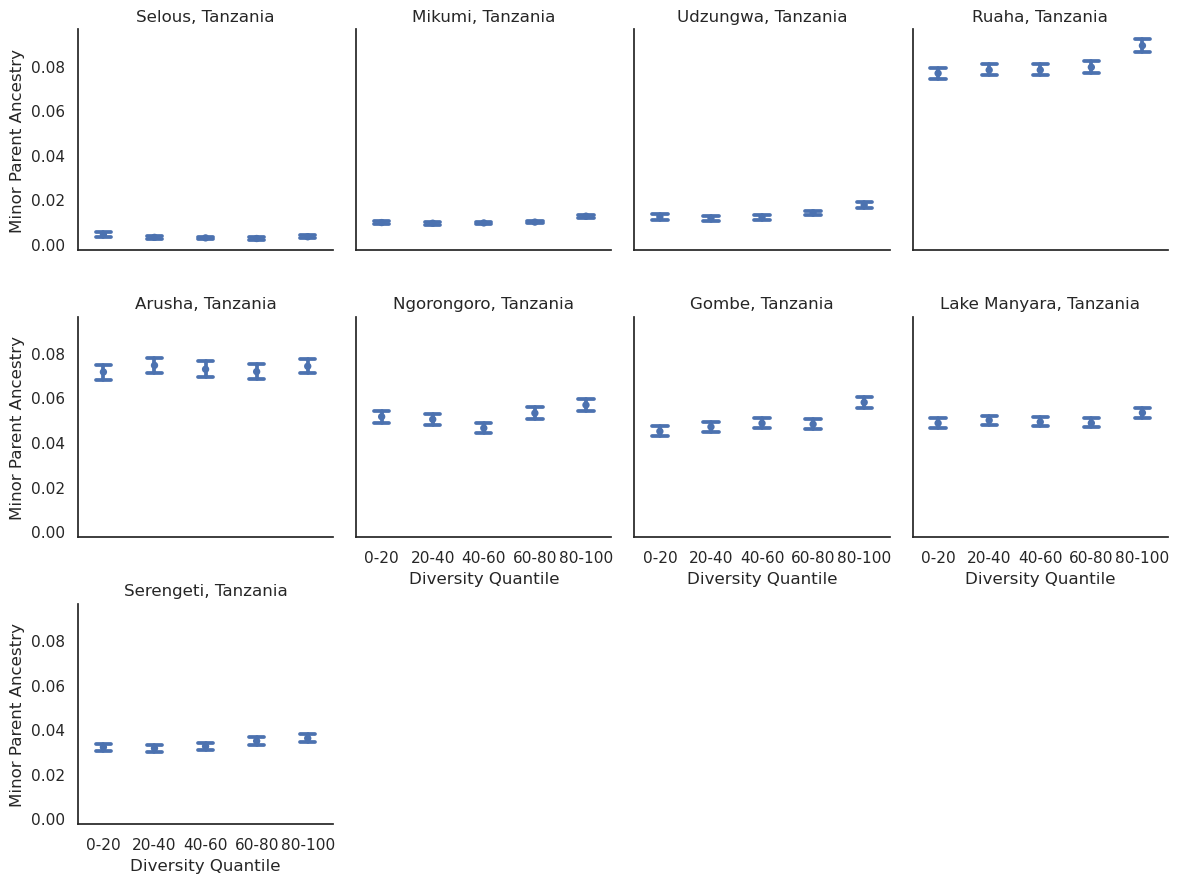

In [48]:
filter_qcut["Diversity Quantile"] = pd.qcut(filter_qcut.diversity, 5,
                                                       labels=["0-20","20-40",
                                                              "40-60","60-80",
                                                              "80-100"])
g = sns.FacetGrid(filter_qcut.loc[filter_qcut.Origin.isin(result_order_no_gog)], col="Origin",
                  col_wrap = 4, col_order=result_order_no_gog)
g.map_dataframe(sns.pointplot, y="minor_parent_percentage", x="Diversity Quantile", 
                linestyles="none", capsize=.3, errorbar=("ci", 95), scale = 0.6)
#g.map_dataframe(sns.stripplot, x="minor_parent_percentage", y="Diversity Quantile", alpha=0.05)
#g.set(xlim=(0, 0.25))
g.set_titles(col_template="{col_name}")
g.set(xlabel="Diversity Quantile", ylabel="Minor Parent Ancestry")

In [49]:
o_l, low_l, high_l, effect_l, effect_hl_l = [], [], [], [], []
filter_qcut["Diversity Quantile"] = pd.qcut(filter_qcut.diversity, 5,
                                                       labels=["0-20","20-40",
                                                              "40-60","60-80",
                                                              "80-100"])
for o in result_order:
    s_df = filter_qcut.loc[filter_qcut.Origin == o]
    #print(o, s_df.groupby(["Diversity Quantile"])[["minor_parent_percentage"]].mean())
    low_mean = s_df.loc[s_df["Diversity Quantile"] == "0-20"][["minor_parent_percentage"]].mean()[0]*100
    high_mean = s_df.loc[s_df["Diversity Quantile"] == "80-100"][["minor_parent_percentage"]].mean()[0]*100
    o_l.append(o)
    low_l.append(low_mean)
    high_l.append(high_mean)
    effect_l.append(high_mean/low_mean-1)

/tmp/47761274/ipykernel_4122384/4242712310.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter_qcut["Diversity Quantile"] = pd.qcut(filter_qcut.diversity, 5,


In [50]:
mean_quantile_df = pd.DataFrame({"Origin": o_l, "0-20 Minor Parent Percentage": low_l, 
                        "80-100 Minor Parent Percentage": high_l, "Relative Increase": effect_l})
mean_quantile_df["Absolute Increase"] = mean_quantile_df["80-100 Minor Parent Percentage"]-mean_quantile_df["0-20 Minor Parent Percentage"]
mean_quantile_df

,Origin,0-20 Minor Parent Percentage,80-100 Minor Parent Percentage,Relative Increase,Absolute Increase
0,"Selous, Tanzania",0.424,0.32,-0.244,-0.103
1,"Mikumi, Tanzania",0.959,1.25,0.299,0.287
2,"Udzungwa, Tanzania",1.22,1.75,0.438,0.532
3,"Ruaha, Tanzania",7.65,8.89,0.162,1.24
4,"Tarangire, Tanzania",22.1,21,-0.0496,-1.09
5,"Arusha, Tanzania",7.14,7.39,0.0361,0.257
6,"Ngorongoro, Tanzania",5.13,5.66,0.102,0.523
7,"Gombe, Tanzania",4.48,5.78,0.29,1.3
8,"Lake Manyara, Tanzania",4.84,5.31,0.0961,0.466
9,"Serengeti, Tanzania",3.19,3.59,0.125,0.399


In [51]:
o_l, low_l, high_l, effect_l, effect_hl_l = [], [], [], [], []
filter_qcut["Diversity Quantile"] = pd.qcut(filter_qcut.diversity, 5,
                                                       labels=["0-20","20-40",
                                                              "40-60","60-80",
                                                              "80-100"])
for o in result_order:
    s_df = filter_qcut.loc[filter_qcut.Origin == o]
    #print(o, s_df.groupby(["Diversity Quantile"])[["minor_parent_percentage"]].mean())
    low_mean = s_df.loc[s_df["Diversity Quantile"] == "0-20"][["minor_parent_percentage"]].mean()[0]*100
    high_mean = s_df.loc[s_df["Diversity Quantile"] == "80-100"][["minor_parent_percentage"]].mean()[0]*100
    o_l.append(o)
    low_l.append(low_mean)
    high_l.append(high_mean)
    effect_l.append(high_mean/low_mean-1)

/tmp/47761274/ipykernel_4122384/4242712310.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter_qcut["Diversity Quantile"] = pd.qcut(filter_qcut.diversity, 5,


In [52]:
filter_qcut

,chrom,start,diversity,Origin,end_x,north_sum,Species,callable_frac,end_y,cM,...,genes,genic,North Percentage,logdiv,logrecomb,norm_diversity,norm_recomb,minor_parent_percentage,local_minor_ancestry,Diversity Quantile
2,chr1,0,0.00306,"Arusha, Tanzania",100000,9.98e+04,anubis,0.795,100000,0,...,"['RNF223', 'C1H1orf159', 'C1H1orf159', 'C1H1or...",True,0.998,-2.51,-5.44,1.69,2.91,0.0016,0.0016,80-100
5,chr1,0,0.00306,"Gog Woreda, Gambella region, Ethiopia",100000,9.98e+04,anubis,0.795,100000,0,...,"['RNF223', 'C1H1orf159', 'C1H1orf159', 'C1H1or...",True,0.998,-2.51,-5.44,1.69,2.91,0.0016,0.0016,80-100
6,chr1,0,0.00306,"Gog Woreda, Ethiopia",100000,9.86e+04,NaN,0.795,100000,0,...,"['RNF223', 'C1H1orf159', 'C1H1orf159', 'C1H1or...",True,0.986,-2.51,-5.44,1.69,2.91,0.986,0.0143,80-100
7,chr1,0,0.00306,"Gombe, Tanzania",100000,9.98e+04,anubis,0.795,100000,0,...,"['RNF223', 'C1H1orf159', 'C1H1orf159', 'C1H1or...",True,0.998,-2.51,-5.44,1.69,2.91,0.0016,0.0016,80-100
8,chr1,0,0.00306,"Issa Valley, Tanzania",100000,9.98e+04,cynocephalus,0.795,100000,0,...,"['RNF223', 'C1H1orf159', 'C1H1orf159', 'C1H1or...",True,0.998,-2.51,-5.44,1.69,2.91,0.998,0.0016,80-100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
532617,chr9,125600000,0.0023,"Ruaha, Tanzania",125700000,2.19e+04,cynocephalus,0.869,125700000,115,...,"['SYCE1', 'SYCE1']",True,0.219,-2.64,-5.58,0.708,1.87,0.219,0.219,80-100
532618,chr9,125600000,0.0023,"Selous, Tanzania",125700000,0,cynocephalus,0.869,125700000,115,...,"['SYCE1', 'SYCE1']",True,0,-2.64,-5.58,0.708,1.87,0,0,80-100
532619,chr9,125600000,0.0023,"Serengeti, Tanzania",125700000,1e+05,anubis,0.869,125700000,115,...,"['SYCE1', 'SYCE1']",True,1,-2.64,-5.58,0.708,1.87,0,0,80-100
532620,chr9,125600000,0.0023,"Tarangire, Tanzania",125700000,6.61e+04,anubis,0.869,125700000,115,...,"['SYCE1', 'SYCE1']",True,0.661,-2.64,-5.58,0.708,1.87,0.339,0.339,80-100


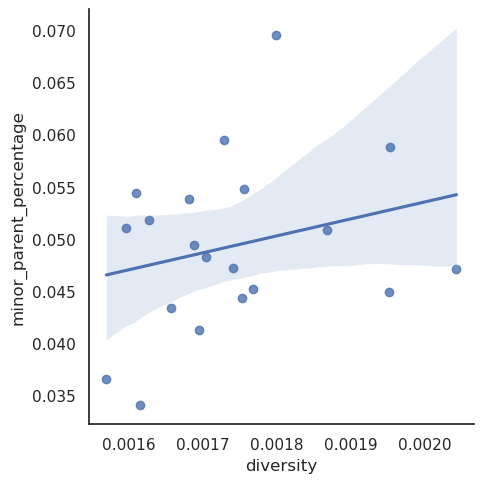

In [53]:
sns.lmplot(filter_qcut.loc[filter_qcut.Origin == "Gombe, Tanzania"].groupby(["chrom"])[["diversity", "minor_parent_percentage"]].mean(),
               x="diversity", y="minor_parent_percentage")

In [54]:
o_l, slope_l, intercept_l, pval_slope_l, pval_intercept_l, stderr_slope_l, stderr_intercept_l = [], [], [], [], [], [], []
for o in result_order:
    o_div = filter_callable.loc[filter_callable.Origin == o]
    glm_results = smf.glm(formula = "minor_parent_percentage ~ diversity", data=o_div).fit()
    print(o, glm_results.summary())
    o_l.append(o), slope_l.append(glm_results.params[1]), intercept_l.append(glm_results.params[0])
    pval_slope_l.append(glm_results.pvalues[1]), pval_intercept_l.append(glm_results.pvalues[0])
    stderr_slope_l.append(glm_results.bse[1]), stderr_intercept_l.append(glm_results.bse[0])

Selous, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25660
Model:                                 GLM   Df Residuals:                    25658
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      0.00068299
Method:                               IRLS   Log-Likelihood:                 57109.
Date:                     Wed, 08 Jul 2026   Deviance:                       17.524
Time:                             11:48:26   Pearson chi2:                     17.5
No. Iterations:                          3   Pseudo R-squ. (CS):          0.0002046
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------

Ngorongoro, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25660
Model:                                 GLM   Df Residuals:                    25658
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                       0.0095201
Method:                               IRLS   Log-Likelihood:                 23306.
Date:                     Wed, 08 Jul 2026   Deviance:                       244.27
Time:                             11:48:27   Pearson chi2:                     244.
No. Iterations:                          3   Pseudo R-squ. (CS):           0.001831
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------

In [55]:
filter_callable.Origin.unique()

array(['Arusha, Tanzania', 'Gog Woreda, Gambella region, Ethiopia',
       'Gog Woreda, Ethiopia', 'Gombe, Tanzania', 'Issa Valley, Tanzania',
       'Katavi, Tanzania', 'Lake Manyara, Tanzania', 'Mahale, Tanzania',
       'Mikumi, Tanzania', 'Ngorongoro, Tanzania', 'Ruaha, Tanzania',
       'Selous, Tanzania', 'Serengeti, Tanzania', 'Tarangire, Tanzania',
       'Udzungwa, Tanzania'], dtype=object)

In [56]:
glm_diversity_df = pd.DataFrame({"Origin": o_l, "Intercept": intercept_l, "Slope": slope_l, 
                                 "Intercept P-value": pval_intercept_l, "Slope P-value": pval_slope_l,
                                "Intercept stderr": stderr_intercept_l, "Slope stderr": stderr_slope_l})
glm_diversity_df

,Origin,Intercept,Slope,Intercept P-value,Slope P-value,Intercept stderr,Slope stderr
0,"Selous, Tanzania",0.00218,0.567,1.86e-06,0.0219,0.000457,0.248
1,"Mikumi, Tanzania",0.00568,2.6,3.61e-35,1.11e-25,0.000459,0.248
2,"Udzungwa, Tanzania",0.0078,3.24,1.19e-25,9.8e-16,0.000745,0.404
3,"Ruaha, Tanzania",0.068,7.09,0,3.07e-14,0.00172,0.934
4,"Tarangire, Tanzania",0.215,-2.98,0,0.0569,0.00289,1.57
5,"Arusha, Tanzania",0.0657,4.31,1.22e-211,0.000169,0.00212,1.15
6,"Ngorongoro, Tanzania",0.0407,6.34,9.18e-126,7.01e-12,0.00171,0.925
7,"Gombe, Tanzania",0.0299,11.4,3.99e-95,6.21e-48,0.00144,0.782
8,"Lake Manyara, Tanzania",0.0411,5.06,2.62e-207,3.13e-12,0.00134,0.725
9,"Serengeti, Tanzania",0.0221,6.64,5.75e-92,1.5e-29,0.00109,0.588


In [57]:
filter_callable["diversity"].quantile([0.05, 0.95])

0.05      0.00082
0.95       0.0028
Name: diversity, dtype: float64

In [58]:
o_l, slope_l, intercept_l, pval_slope_l, pval_intercept_l, stderr_slope_l, stderr_intercept_l = [], [], [], [], [], [], []
for o in result_order:
    o_div = filter_callable.loc[(filter_callable.Origin == o) #& (filter_callable.diversity <= 0.0028)
                               #& (filter_callable.diversity >= 0.000819)
                               ]
    glm_results = smf.glm(formula = "minor_parent_percentage ~ diversity",
                          data=o_div, var_weights=np.asarray(o_div["diversity"])
                         ).fit()
    print(o, glm_results.summary())
    o_l.append(o), slope_l.append(glm_results.params[1]), intercept_l.append(glm_results.params[0])
    pval_slope_l.append(glm_results.pvalues[1]), pval_intercept_l.append(glm_results.pvalues[0])
    stderr_slope_l.append(glm_results.bse[1]), stderr_intercept_l.append(glm_results.bse[0])

Selous, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25660
Model:                                 GLM   Df Residuals:                    25658
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      1.0977e-06
Method:                               IRLS   Log-Likelihood:                 57129.
Date:                     Wed, 08 Jul 2026   Deviance:                     0.028166
Time:                             11:48:27   Pearson chi2:                   0.0282
No. Iterations:                          3   Pseudo R-squ. (CS):           0.009927
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------

Gog Woreda, Ethiopia                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25651
Model:                                 GLM   Df Residuals:                    25649
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      4.1528e-05
Method:                               IRLS   Log-Likelihood:                 10513.
Date:                     Wed, 08 Jul 2026   Deviance:                       1.0652
Time:                             11:48:27   Pearson chi2:                     1.07
No. Iterations:                          3   Pseudo R-squ. (CS):            0.02389
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------

In [59]:
glm_diversity_df = pd.DataFrame({"Origin": o_l, "Intercept": intercept_l, "Slope": slope_l, 
                                 "Intercept P-value": pval_intercept_l, "Slope P-value": pval_slope_l,
                                "Intercept stderr": stderr_intercept_l, "Slope stderr": stderr_slope_l})
glm_diversity_df

,Origin,Intercept,Slope,Intercept P-value,Slope P-value,Intercept stderr,Slope stderr
0,"Selous, Tanzania",-0.00263,3,6.44e-11,1.27e-57,0.000403,0.188
1,"Mikumi, Tanzania",0.00195,4.49,5.55e-06,1.31e-111,0.000429,0.2
2,"Udzungwa, Tanzania",0.0075,3.39,1.29e-27,3.43e-26,0.000688,0.321
3,"Ruaha, Tanzania",0.0656,8.32,0,3.54e-29,0.00159,0.742
4,"Tarangire, Tanzania",0.204,2.47,0,0.0461,0.00266,1.24
5,"Arusha, Tanzania",0.0527,10.9,1.64e-162,3.12e-33,0.00194,0.904
6,"Ngorongoro, Tanzania",0.0339,9.77,6.6e-103,2.12e-40,0.00158,0.734
7,"Gombe, Tanzania",0.0187,17,8.05e-42,1.22e-155,0.00138,0.641
8,"Lake Manyara, Tanzania",0.0343,8.5,1.55e-168,5.72e-49,0.00124,0.578
9,"Serengeti, Tanzania",0.0114,12,1.24e-27,7.43e-135,0.00105,0.487


In [60]:
o_l, slope_l, intercept_l, pval_slope_l, pval_intercept_l, stderr_slope_l, stderr_intercept_l = [], [], [], [], [], [], []
for o in result_order:
    o_div = filter_qcut.loc[filter_qcut.Origin == o]
    glm_results = smf.glm(formula = "minor_parent_percentage ~ diversity", data=o_div,
                         var_weights=np.asarray(o_div["diversity"])).fit()
    print(o, glm_results.summary())
    o_l.append(o), slope_l.append(glm_results.params[1]), intercept_l.append(glm_results.params[0])
    pval_slope_l.append(glm_results.pvalues[1]), pval_intercept_l.append(glm_results.pvalues[0])
    stderr_slope_l.append(glm_results.bse[1]), stderr_intercept_l.append(glm_results.bse[0])

Selous, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25406
Model:                                 GLM   Df Residuals:                    25404
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      9.7936e-07
Method:                               IRLS   Log-Likelihood:                 58017.
Date:                     Wed, 08 Jul 2026   Deviance:                     0.024880
Time:                             11:48:27   Pearson chi2:                   0.0249
No. Iterations:                          3   Pseudo R-squ. (CS):          2.708e-08
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------

Serengeti, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25406
Model:                                 GLM   Df Residuals:                    25404
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      6.5776e-06
Method:                               IRLS   Log-Likelihood:                 33824.
Date:                     Wed, 08 Jul 2026   Deviance:                      0.16710
Time:                             11:48:28   Pearson chi2:                    0.167
No. Iterations:                          3   Pseudo R-squ. (CS):           0.002074
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------

In [61]:
glm_diversity_df = pd.DataFrame({"Origin": o_l, "Intercept": intercept_l, "Slope": slope_l, 
                                 "Intercept P-value": pval_intercept_l, "Slope P-value": pval_slope_l,
                                "Intercept stderr": stderr_intercept_l, "Slope stderr": stderr_slope_l})
glm_diversity_df

,Origin,Intercept,Slope,Intercept P-value,Slope P-value,Intercept stderr,Slope stderr
0,"Selous, Tanzania",0.003,0.00608,1.38e-09,0.98,0.000495,0.246
1,"Mikumi, Tanzania",0.00608,2.29,5.07e-33,1.62e-19,0.000508,0.253
2,"Udzungwa, Tanzania",0.0069,3.76,4.59e-15,1.06e-17,0.00088,0.439
3,"Ruaha, Tanzania",0.0642,9.14,3.98e-214,4.18e-19,0.00205,1.02
4,"Tarangire, Tanzania",0.208,0.366,0,0.83,0.00343,1.71
5,"Arusha, Tanzania",0.0685,2.34,1.54e-166,0.0591,0.00249,1.24
6,"Ngorongoro, Tanzania",0.0384,7.33,1.37e-80,3.28e-13,0.00202,1.01
7,"Gombe, Tanzania",0.0306,10.6,8.05e-71,7.43e-35,0.00172,0.857
8,"Lake Manyara, Tanzania",0.0409,4.95,1.67e-146,3.79e-10,0.00159,0.791
9,"Serengeti, Tanzania",0.0251,4.64,2.67e-85,3.78e-13,0.00128,0.638


In [62]:
groups = filter_qcut.groupby("chrom")
aut_mean, chrom_mean = groups["diversity"].transform("mean"), filter_qcut["diversity"].mean()
filter_qcut["aut_norm_div"] = filter_qcut.diversity*chrom_mean/aut_mean

/tmp/47761274/ipykernel_4122384/3362829037.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter_qcut["aut_norm_div"] = filter_qcut.diversity*chrom_mean/aut_mean


In [63]:
for o in ["Katavi, Tanzania", "Mahale, Tanzania"]:
    o_div = filter_callable.loc[(filter_callable.Origin == o) #& (filter_callable.diversity <= 0.0028)
                               #& (filter_callable.diversity >= 0.000819)
                               ]
    glm_results = smf.glm(formula = "minor_parent_percentage ~ diversity",
                          data=o_div, var_weights=np.asarray(o_div["diversity"])
                         ).fit()
    print(o, glm_results.summary())

Katavi, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25660
Model:                                 GLM   Df Residuals:                    25658
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      3.1221e-05
Method:                               IRLS   Log-Likelihood:                 14177.
Date:                     Wed, 08 Jul 2026   Deviance:                      0.80107
Time:                             11:48:28   Pearson chi2:                    0.801
No. Iterations:                          3   Pseudo R-squ. (CS):          0.0003544
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------

In [64]:
o_l, slope_l, intercept_l, pval_slope_l, pval_intercept_l, stderr_slope_l, stderr_intercept_l = [], [], [], [], [], [], []
for o in result_order:
    o_div = filter_qcut.loc[filter_qcut.Origin == o]
    glm_results = smf.glm(formula = "minor_parent_percentage ~ aut_norm_div", data=o_div,
                         var_weights=np.asarray(o_div["aut_norm_div"])).fit()
    print(o, glm_results.summary())
    o_l.append(o), slope_l.append(glm_results.params[1]), intercept_l.append(glm_results.params[0])
    pval_slope_l.append(glm_results.pvalues[1]), pval_intercept_l.append(glm_results.pvalues[0])
    stderr_slope_l.append(glm_results.bse[1]), stderr_intercept_l.append(glm_results.bse[0])

Selous, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25406
Model:                                 GLM   Df Residuals:                    25404
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      9.5917e-07
Method:                               IRLS   Log-Likelihood:                 58305.
Date:                     Wed, 08 Jul 2026   Deviance:                     0.024367
Time:                             11:48:28   Pearson chi2:                   0.0244
No. Iterations:                          3   Pseudo R-squ. (CS):          5.668e-05
Covariance Type:                 nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------

Gombe, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25406
Model:                                 GLM   Df Residuals:                    25404
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      1.1851e-05
Method:                               IRLS   Log-Likelihood:                 26368.
Date:                     Wed, 08 Jul 2026   Deviance:                      0.30106
Time:                             11:48:28   Pearson chi2:                    0.301
No. Iterations:                          3   Pseudo R-squ. (CS):           0.005383
Covariance Type:                 nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------

In [65]:
glm_diversity_df = pd.DataFrame({"Origin": o_l, "Intercept": intercept_l, "Slope": slope_l, 
                                 "Intercept P-value": pval_intercept_l, "Slope P-value": pval_slope_l,
                                "Intercept stderr": stderr_intercept_l, "Slope stderr": stderr_slope_l})
glm_diversity_df

,Origin,Intercept,Slope,Intercept P-value,Slope P-value,Intercept stderr,Slope stderr
0,"Selous, Tanzania",0.00353,-0.295,7.35e-13,0.23,0.000492,0.246
1,"Mikumi, Tanzania",0.00671,1.93,5.71e-40,2.46e-14,0.000507,0.253
2,"Udzungwa, Tanzania",0.00723,3.57,2.57e-16,5.37e-16,0.000882,0.441
3,"Ruaha, Tanzania",0.065,8.68,4.91e-218,3.72e-17,0.00206,1.03
4,"Tarangire, Tanzania",0.209,-0.641,0,0.709,0.00344,1.72
5,"Arusha, Tanzania",0.0668,3.43,1.35e-156,0.00614,0.00251,1.25
6,"Ngorongoro, Tanzania",0.04,6.47,2.45e-86,1.86e-10,0.00203,1.01
7,"Gombe, Tanzania",0.0314,10.1,1.23e-73,1.13e-31,0.00173,0.864
8,"Lake Manyara, Tanzania",0.0408,5.03,2.51e-144,2.69e-10,0.00159,0.797
9,"Serengeti, Tanzania",0.0242,5.15,1.27e-78,1.34e-15,0.00129,0.645


In [66]:
o_div = filter_qcut.loc[filter_qcut.Origin.isin(["Mikumi, Tanzania", "Ruaha, Tanzania"])]
glm_results = smf.glm(formula = "minor_parent_percentage ~ diversity*Origin", data=o_div,
                         var_weights=np.asarray(o_div["diversity"])).fit()
print(glm_results.summary(), glm_results.pvalues)

                    Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                50812
Model:                                 GLM   Df Residuals:                    50808
Model Family:                     Gaussian   Df Model:                            3
Link Function:                    Identity   Scale:                      8.9649e-06
Method:                               IRLS   Log-Likelihood:                 59782.
Date:                     Wed, 08 Jul 2026   Deviance:                      0.45549
Time:                             11:48:29   Pearson chi2:                    0.455
No. Iterations:                          3   Pseudo R-squ. (CS):             0.2173
Covariance Type:                 nonrobust                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------

In [67]:
o_div = filter_qcut.loc[filter_qcut.Origin.isin(["Ngorongoro, Tanzania", "Tarangire, Tanzania"])]
glm_results = smf.glm(formula = "minor_parent_percentage ~ diversity*Origin", data=o_div,
                         var_weights=np.asarray(o_div["diversity"])).fit()
print(glm_results.summary(), glm_results.pvalues)

                    Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                50812
Model:                                 GLM   Df Residuals:                    50808
Model Family:                     Gaussian   Df Model:                            3
Link Function:                    Identity   Scale:                      3.1685e-05
Method:                               IRLS   Log-Likelihood:                 27706.
Date:                     Wed, 08 Jul 2026   Deviance:                       1.6098
Time:                             11:48:29   Pearson chi2:                     1.61
No. Iterations:                          3   Pseudo R-squ. (CS):             0.2800
Covariance Type:                 nonrobust                                         
                                              coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------

In [68]:
from scipy.stats import norm

predictions = glm_results.get_prediction()
df_predictions = predictions.summary_frame()
df_predictions["diversity"] = o_div["diversity"]

[[<matplotlib.axis.XTick at 0x152b9e00fb80>,

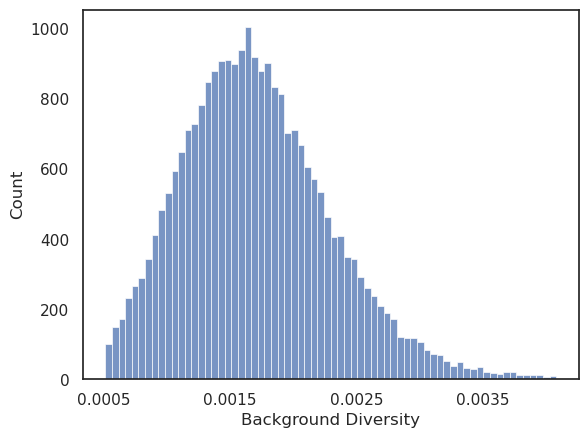

In [69]:
g = sns.histplot(filter_qcut.loc[filter_qcut.Origin.isin(gog)], x="diversity")
g.set(xlabel = "Background Diversity")
g.set(xticks=np.arange(0.0005, 0.004, 0.001))

[Text(0.5, 0, 'Background Diversity')]

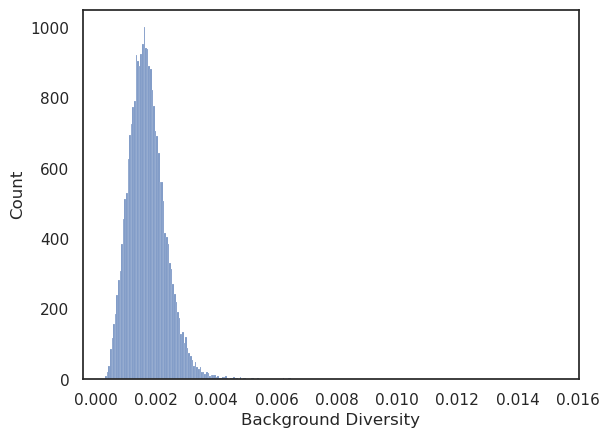

In [70]:
g = sns.histplot(filter_callable.loc[filter_callable.Origin.isin(gog)], x="diversity")
g.set(xlabel = "Background Diversity")
#g.set(xticks=np.arange(0.0005, 0.014, 0.001))

In [71]:
filter_qcut.loc[filter_qcut.Origin.isin(gog)]["diversity"].mean(), filter_qcut.loc[filter_qcut.Origin.isin(gog)]["diversity"].median()

(0.0017118524695634901, 0.0016583672626279916)

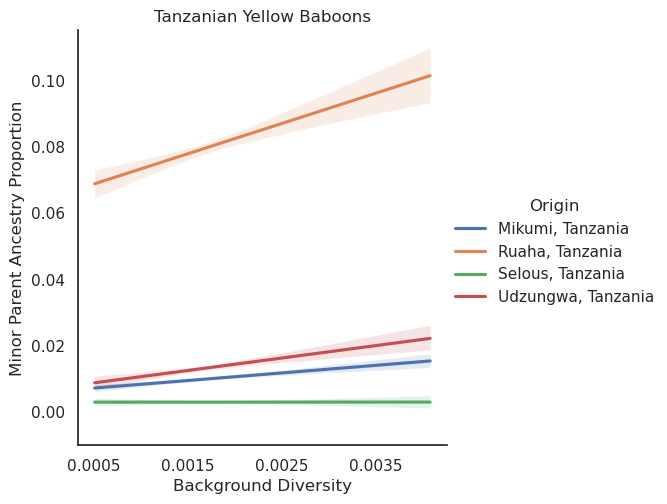

In [72]:
g = lmplot(filter_qcut.loc[filter_qcut.Origin.isin(yellows)], x="diversity", y="minor_parent_percentage",
                            scatter=False, hue="Origin", weighted=True, n_boot=1000, ci=99.5) #Additional bootstraps makes it take long
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Background Diversity", title="Tanzanian Yellow Baboons")
g.set(ylim=(-0.01, None))
g.set(xticks=np.arange(0.0005, 0.004, 0.001))

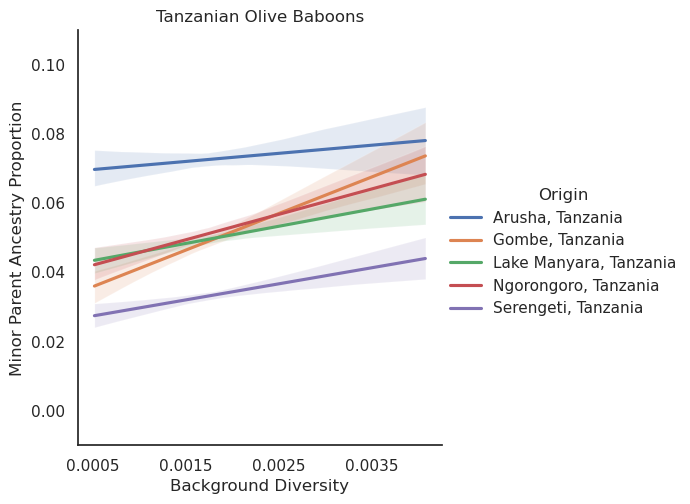

In [73]:
g = lmplot(filter_qcut.loc[filter_qcut.Origin.isin(olives)], x="diversity", y="minor_parent_percentage",
                            scatter=False, hue="Origin", weighted=True, n_boot=1000, ci=99.5) #Additional bootstraps makes it take long
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Background Diversity", title="Tanzanian Olive Baboons")
g.set(ylim=(-0.01, 0.11))
g.set(xticks=np.arange(0.0005, 0.004, 0.001))

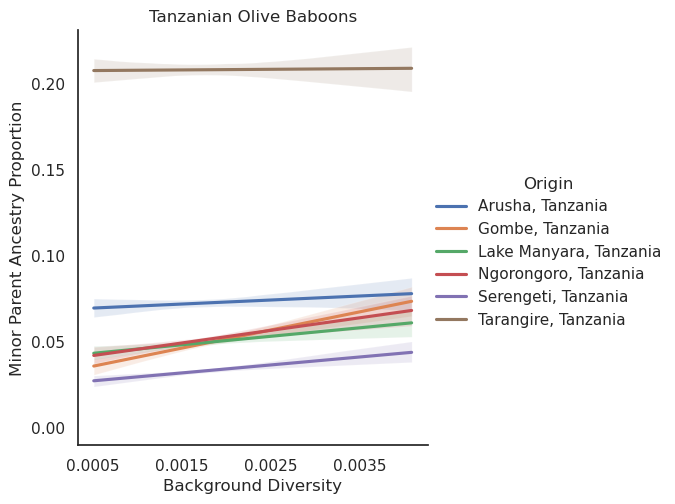

In [74]:
g = lmplot(filter_qcut.loc[filter_qcut.Origin.isin(olives_with_tarangire)], x="diversity", y="minor_parent_percentage",
                            scatter=False, hue="Origin", weighted=True, n_boot=1000, ci=99.5) #Additional bootstraps makes it take long
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Background Diversity", title="Tanzanian Olive Baboons")
g.set(ylim=(-0.01, None))
g.set(xticks=np.arange(0.0005, 0.004, 0.001))

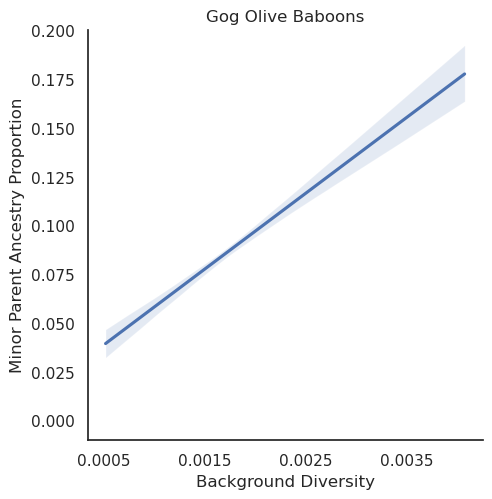

In [75]:
g = lmplot(filter_qcut.loc[filter_qcut.Origin.isin(gog)], x="diversity", y="minor_parent_percentage",
                            scatter=False, weighted=True, n_boot=1000, ci=99.5) #Additional bootstraps makes it take long
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Background Diversity", title="Gog Olive Baboons")
g.set(ylim=(-0.01, None))
g.set(xticks=np.arange(0.0005, 0.004, 0.001))

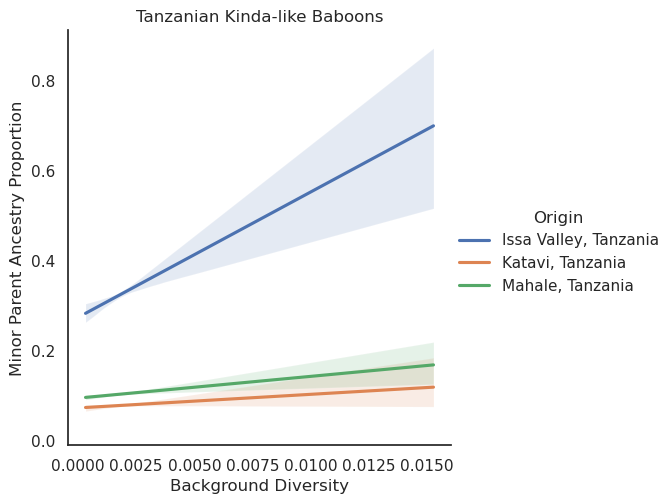

In [76]:
g = lmplot(filter_callable.loc[filter_callable.Origin.isin(["Mahale, Tanzania",
                                                           "Katavi, Tanzania",
                                                           "Issa Valley, Tanzania"])], x="diversity", y="minor_parent_percentage",
                            scatter=False, hue="Origin", weighted=True, n_boot=1000, ci=99.5) #Additional bootstraps makes it take long
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Background Diversity", title="Tanzanian Kinda-like Baboons")
g.set(ylim=(-0.01, None))

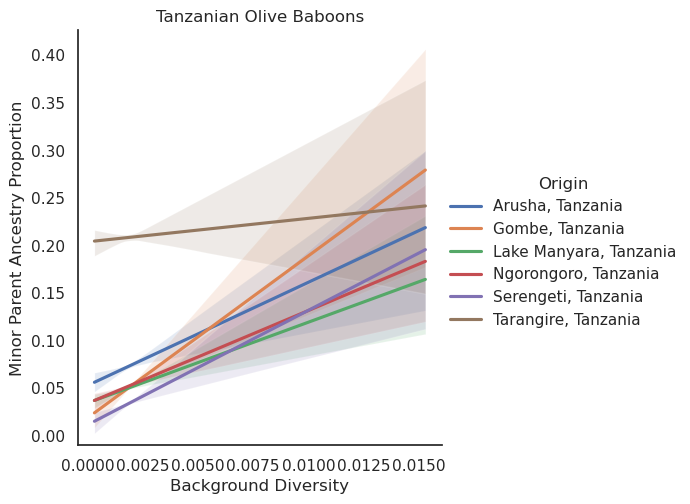

In [77]:
g = lmplot(filter_callable.loc[filter_callable.Origin.isin(olives_with_tarangire)], x="diversity", y="minor_parent_percentage",
                            scatter=False, hue="Origin", weighted=True, n_boot=1000, ci=99.5) #Additional bootstraps makes it take long
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Background Diversity", title="Tanzanian Olive Baboons")
g.set(ylim=(-0.01, None))

In [78]:
o_l, stat_l, pval_l = [], [], []
for o in result_order:
    o_div = filter_qcut.loc[filter_qcut.Origin == o]
    #o_div = o_div.loc[(o_div.minor_parent_percentage < 0.5)]
    st, pval = stats.pearsonr(o_div.diversity, o_div["minor_parent_percentage"])
    print(o, stats.pearsonr(o_div.diversity, o_div["minor_parent_percentage"]))
    o_l.append(o), stat_l.append(st), pval_l.append(pval)
pd.DataFrame({"Origin": o_l, "Statistic": stat_l, "P-Value": pval_l})

Selous, Tanzania PearsonRResult(statistic=-0.011709679155817899, pvalue=0.06198425989190739)
Mikumi, Tanzania PearsonRResult(statistic=0.039294770781291365, pvalue=3.7185271659649535e-10)
Udzungwa, Tanzania PearsonRResult(statistic=0.045394116274944885, pvalue=4.524668356808528e-13)
Ruaha, Tanzania PearsonRResult(statistic=0.0443278962732689, pvalue=1.5643094852908059e-12)
Tarangire, Tanzania PearsonRResult(statistic=-0.016782880932105546, pvalue=0.007470167106701525)
Arusha, Tanzania PearsonRResult(statistic=0.006436641035198389, pvalue=0.3049325575490865)
Ngorongoro, Tanzania PearsonRResult(statistic=0.030437810520310908, pvalue=1.2194727599377624e-06)
Gombe, Tanzania PearsonRResult(statistic=0.05976721840658379, pvalue=1.5059946942521803e-21)
Lake Manyara, Tanzania PearsonRResult(statistic=0.025966907617133047, pvalue=3.481741829412257e-05)
Serengeti, Tanzania PearsonRResult(statistic=0.03378353263820874, pvalue=7.199594344705411e-08)
Gog Woreda, Ethiopia PearsonRResult(statistic=0.

,Origin,Statistic,P-Value
0,"Selous, Tanzania",-0.0117,0.062
1,"Mikumi, Tanzania",0.0393,3.72e-10
2,"Udzungwa, Tanzania",0.0454,4.52e-13
3,"Ruaha, Tanzania",0.0443,1.56e-12
4,"Tarangire, Tanzania",-0.0168,0.00747
5,"Arusha, Tanzania",0.00644,0.305
6,"Ngorongoro, Tanzania",0.0304,1.22e-06
7,"Gombe, Tanzania",0.0598,1.51e-21
8,"Lake Manyara, Tanzania",0.026,3.48e-05
9,"Serengeti, Tanzania",0.0338,7.2e-08


Recomb investigation for autosomes

In [79]:
filter_callable = admix_div_mean.loc[admix_div_mean.callable_frac > 0.75]
filter_callable.loc[filter_callable['Origin'] == 'Gog Woreda, Gambella region, Ethiopia_eth_case', ['Origin']] = 'Gog Woreda, Ethiopia'
filter_callable["average_cM_window"].quantile([0.005, 0.995])

0.005     1.13e-07
0.995     4.08e-06
Name: average_cM_window, dtype: float64

In [80]:
len(filter_callable)

384891

In [81]:
len(filter_callable)/len(admix_div_mean)

0.9890200532423349

In [82]:
filter_qcut_recomb = filter_callable.loc[(filter_callable.average_cM_window >= 1.13e-07) &
                                 (filter_callable.average_cM_window <=  4.08e-06)]
filter_callable["window_cM"] = filter_callable["average_cM_window"]*100000
filter_qcut_recomb["window_cM"] = filter_qcut_recomb["average_cM_window"]*100000

/tmp/47761274/ipykernel_4122384/436718125.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter_callable["window_cM"] = filter_callable["average_cM_window"]*100000
/tmp/47761274/ipykernel_4122384/436718125.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter_qcut_recomb["window_cM"] = filter_qcut_recomb["average_cM_window"]*100000


In [83]:
import statsmodels.api as sm
import numpy as np

df_l = []
for o in result_order:
    o_div = filter_qcut_recomb.loc[filter_qcut_recomb.Origin == o]
    Y = o_div["minor_parent_percentage"]
    X = o_div.window_cM
    X = sm.add_constant(X)
    model = sm.OLS(Y,X)
    results = model.fit()
    print(o)
    #print(results.t_test([1, 0]))
    het_test = sm.stats.het_breuschpagan(resid=results.resid, exog_het=X)
    print(het_test)
    #print(sm.stats.diagnostic.linear_harvey_collier(results))
    df_l.append(list(het_test))
bp_df = pd.DataFrame(df_l, columns=["Lagrange Multiplier", "Lagrange Multiplier P-value", "F-statistic", "F-statistic P-value"])
bp_df["Origin"] = result_order
bp_df

Selous, Tanzania
(0.15380807159510435, 0.6949224708630534, 0.1537968924701614, 0.6949362916518678)
Mikumi, Tanzania
(7.0481459593234765, 0.007934733877732985, 7.0495470830920866, 0.00793347482678423)
Udzungwa, Tanzania
(0.5371906577655055, 0.46359934659329194, 0.5371597210262596, 0.46361898337806806)
Ruaha, Tanzania
(0.017569348365514825, 0.894549737441553, 0.017567977157584357, 0.8945548784002404)
Tarangire, Tanzania
(0.13766752664518833, 0.7106109056863044, 0.13765743318192245, 0.7106241310517876)
Arusha, Tanzania
(5.599233430563359, 0.017968337861858745, 5.600026997410978, 0.017967660157166887)
Ngorongoro, Tanzania
(0.30373458611828685, 0.5815505878847408, 0.3037143026404462, 0.5815680496679418)
Gombe, Tanzania
(2.6222439134884477, 0.10537533201748682, 2.6223081567783546, 0.10538348186032466)
Lake Manyara, Tanzania
(1.062650141018155, 0.3026115266151326, 1.0626109253717038, 0.3026302636544758)
Serengeti, Tanzania
(15.354572249356895, 8.910503071365744e-05, 15.362649796371349, 8.8957

,Lagrange Multiplier,Lagrange Multiplier P-value,F-statistic,F-statistic P-value,Origin
0,0.154,0.695,0.154,0.695,"Selous, Tanzania"
1,7.05,0.00793,7.05,0.00793,"Mikumi, Tanzania"
2,0.537,0.464,0.537,0.464,"Udzungwa, Tanzania"
3,0.0176,0.895,0.0176,0.895,"Ruaha, Tanzania"
4,0.138,0.711,0.138,0.711,"Tarangire, Tanzania"
5,5.6,0.018,5.6,0.018,"Arusha, Tanzania"
6,0.304,0.582,0.304,0.582,"Ngorongoro, Tanzania"
7,2.62,0.105,2.62,0.105,"Gombe, Tanzania"
8,1.06,0.303,1.06,0.303,"Lake Manyara, Tanzania"
9,15.4,8.91e-05,15.4,8.9e-05,"Serengeti, Tanzania"


/tmp/47761274/ipykernel_4122384/3329632309.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter_qcut_recomb["Recombination Quantile"] = pd.qcut(filter_qcut_recomb.window_cM, 5,


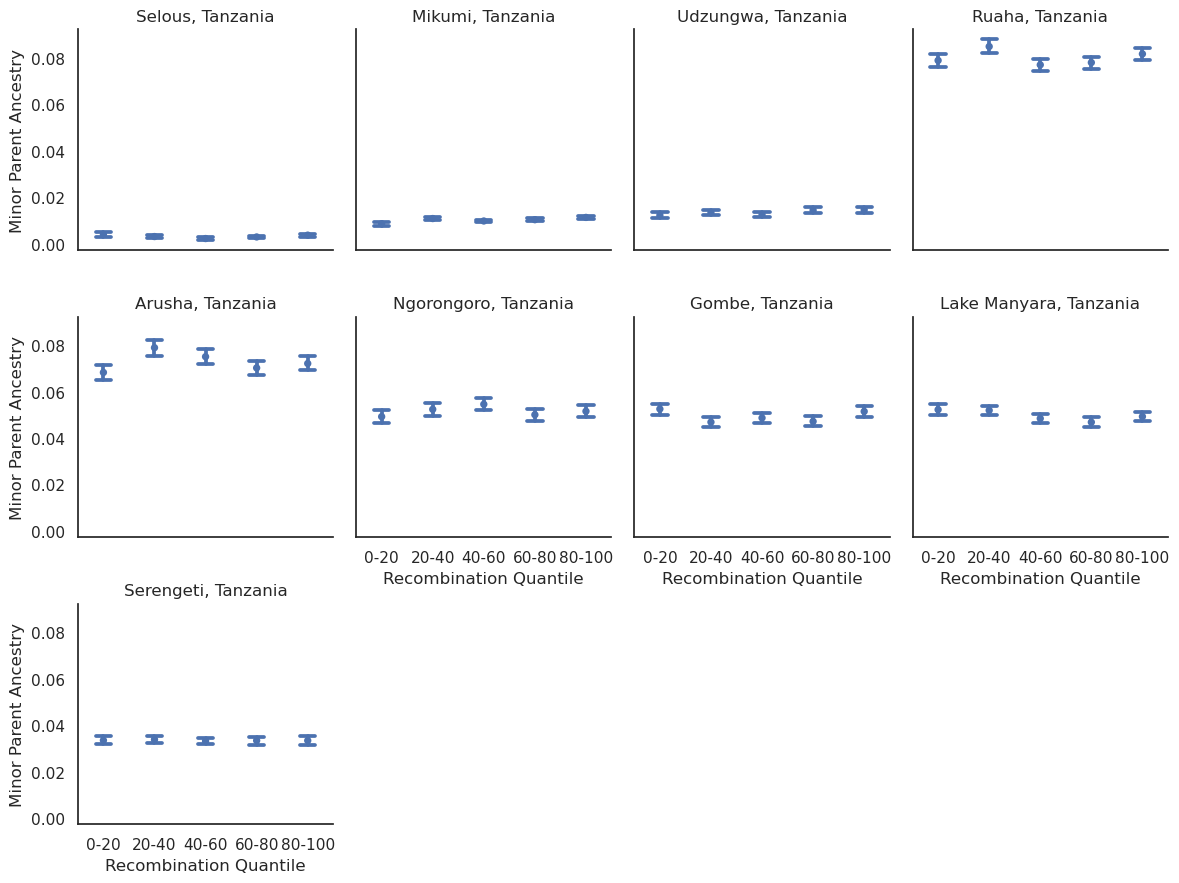

In [84]:
filter_qcut_recomb["Recombination Quantile"] = pd.qcut(filter_qcut_recomb.window_cM, 5,
                                                       labels=["0-20","20-40",
                                                              "40-60","60-80",
                                                              "80-100"])
g = sns.FacetGrid(filter_qcut_recomb.loc[filter_qcut_recomb.Origin.isin(result_order_no_gog)], col="Origin",
                  col_wrap = 4, col_order=result_order_no_gog)
g.map_dataframe(sns.pointplot, y="minor_parent_percentage", x="Recombination Quantile", 
                linestyles="none", capsize=.3, errorbar=("ci", 95), scale = 0.6)
#g.map_dataframe(sns.stripplot, x="minor_parent_percentage", y="Diversity Quantile", alpha=0.05)
#g.set(xlim=(0, 0.25))
g.set_titles(col_template="{col_name}")
g.set(xlabel="Recombination Quantile", ylabel="Minor Parent Ancestry")

In [85]:
o_l, low_l, high_l, effect_l, effect_hl_l = [], [], [], [], []
filter_qcut_recomb["Recombination Quantile"] = pd.qcut(filter_qcut_recomb.window_cM, 5,
                                                       labels=["0-20","20-40",
                                                              "40-60","60-80",
                                                              "80-100"])
for o in result_order:
    s_df = filter_qcut_recomb.loc[filter_qcut_recomb.Origin == o]
    #print(o, s_df.groupby(["Recombination Quantile"])[["minor_parent_percentage"]].mean())
    low_mean = s_df.loc[s_df["Recombination Quantile"] == "0-20"][["minor_parent_percentage"]].mean()[0]*100
    high_mean = s_df.loc[s_df["Recombination Quantile"] == "80-100"][["minor_parent_percentage"]].mean()[0]*100
    o_l.append(o)
    low_l.append(low_mean)
    high_l.append(high_mean)
    effect_l.append(high_mean/low_mean-1)

/tmp/47761274/ipykernel_4122384/3586050451.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter_qcut_recomb["Recombination Quantile"] = pd.qcut(filter_qcut_recomb.window_cM, 5,


In [86]:
mean_quantile_df = pd.DataFrame({"Origin": o_l, "0-20 Minor Parent Percentage": low_l, 
                        "80-100 Minor Parent Percentage": high_l, "Relative Increase": effect_l})
mean_quantile_df["Absolute Increase"] = mean_quantile_df["80-100 Minor Parent Percentage"]-mean_quantile_df["0-20 Minor Parent Percentage"]
mean_quantile_df

,Origin,0-20 Minor Parent Percentage,80-100 Minor Parent Percentage,Relative Increase,Absolute Increase
0,"Selous, Tanzania",0.396,0.367,-0.0733,-0.0291
1,"Mikumi, Tanzania",0.856,1.13,0.32,0.274
2,"Udzungwa, Tanzania",1.22,1.46,0.194,0.237
3,"Ruaha, Tanzania",7.89,8.17,0.0356,0.281
4,"Tarangire, Tanzania",21.5,19.9,-0.0747,-1.61
5,"Arusha, Tanzania",6.82,7.21,0.0565,0.385
6,"Ngorongoro, Tanzania",4.92,5.15,0.0473,0.232
7,"Gombe, Tanzania",5.25,5.14,-0.02,-0.105
8,"Lake Manyara, Tanzania",5.22,4.92,-0.0568,-0.297
9,"Serengeti, Tanzania",3.35,3.34,-0.00278,-0.00931


In [87]:
o_l, slope_l, intercept_l, pval_slope_l, pval_intercept_l, stderr_slope_l, stderr_intercept_l = [], [], [], [], [], [], []
for o in result_order:
    o_div = filter_callable.loc[filter_callable.Origin == o]
    glm_results = smf.glm(formula = "minor_parent_percentage ~ window_cM", data=o_div,
                         var_weights=np.asarray(o_div["window_cM"])).fit()
    print(o, glm_results.summary())
    o_l.append(o), slope_l.append(glm_results.params[1]), intercept_l.append(glm_results.params[0])
    pval_slope_l.append(glm_results.pvalues[1]), pval_intercept_l.append(glm_results.pvalues[0])
    stderr_slope_l.append(glm_results.bse[1]), stderr_intercept_l.append(glm_results.bse[0])

Selous, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25660
Model:                                 GLM   Df Residuals:                    25658
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      5.8992e-05
Method:                               IRLS   Log-Likelihood:                 54115.
Date:                     Wed, 08 Jul 2026   Deviance:                       1.5136
Time:                             11:54:47   Pearson chi2:                     1.51
No. Iterations:                          3   Pseudo R-squ. (CS):           0.001724
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------

Gog Woreda, Ethiopia                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25651
Model:                                 GLM   Df Residuals:                    25649
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                       0.0021873
Method:                               IRLS   Log-Likelihood:                 7754.0
Date:                     Wed, 08 Jul 2026   Deviance:                       56.102
Time:                             11:54:47   Pearson chi2:                     56.1
No. Iterations:                          3   Pseudo R-squ. (CS):            0.01622
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------

In [88]:
glm_recomb_df = pd.DataFrame({"Origin": o_l, "Intercept": intercept_l, "Slope": slope_l, 
                                 "Intercept P-value": pval_intercept_l, "Slope P-value": pval_slope_l,
                                "Intercept stderr": stderr_intercept_l, "Slope stderr": stderr_slope_l})
glm_recomb_df

,Origin,Intercept,Slope,Intercept P-value,Slope P-value,Intercept stderr,Slope stderr
0,"Selous, Tanzania",0.00223,0.00936,4.39e-19,2.84e-11,0.00025,0.00141
1,"Mikumi, Tanzania",0.00882,0.0172,6.92e-236,5.9e-30,0.000269,0.00152
2,"Udzungwa, Tanzania",0.0131,0.00805,5.85e-230,0.000417,0.000405,0.00228
3,"Ruaha, Tanzania",0.0737,0.058,0,1.63e-28,0.000929,0.00524
4,"Tarangire, Tanzania",0.205,0.0179,0,0.0407,0.00155,0.00877
5,"Arusha, Tanzania",0.0694,0.0323,0,3.51e-07,0.00113,0.00634
6,"Ngorongoro, Tanzania",0.0439,0.0721,0,6.24e-43,0.000931,0.00525
7,"Gombe, Tanzania",0.0419,0.073,0,1.04e-57,0.000809,0.00456
8,"Lake Manyara, Tanzania",0.0454,0.0369,0,1.21e-19,0.000721,0.00407
9,"Serengeti, Tanzania",0.0312,0.0227,0,5.67e-11,0.000614,0.00346


In [89]:
o_l, slope_l, intercept_l, pval_slope_l, pval_intercept_l, stderr_slope_l, stderr_intercept_l = [], [], [], [], [], [], []
for o in result_order:
    o_div = filter_qcut_recomb.loc[filter_qcut_recomb.Origin == o]
    glm_results = smf.glm(formula = "minor_parent_percentage ~ window_cM", data=o_div,
                         var_weights=np.asarray(o_div["window_cM"])
                         ).fit()
    print(o, glm_results.summary())
    o_l.append(o), slope_l.append(glm_results.params[1]), intercept_l.append(glm_results.params[0])
    pval_slope_l.append(glm_results.pvalues[1]), pval_intercept_l.append(glm_results.pvalues[0])
    stderr_slope_l.append(glm_results.bse[1]), stderr_intercept_l.append(glm_results.bse[0])

Selous, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25401
Model:                                 GLM   Df Residuals:                    25399
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      5.7502e-05
Method:                               IRLS   Log-Likelihood:                 53898.
Date:                     Wed, 08 Jul 2026   Deviance:                       1.4605
Time:                             11:54:47   Pearson chi2:                     1.46
No. Iterations:                          3   Pseudo R-squ. (CS):           0.002775
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------

Serengeti, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25401
Model:                                 GLM   Df Residuals:                    25399
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      0.00033472
Method:                               IRLS   Log-Likelihood:                 31526.
Date:                     Wed, 08 Jul 2026   Deviance:                       8.5016
Time:                             11:54:48   Pearson chi2:                     8.50
No. Iterations:                          3   Pseudo R-squ. (CS):           0.001191
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------

In [90]:
glm_recomb_df = pd.DataFrame({"Origin": o_l, "Intercept": intercept_l, "Slope": slope_l, 
                                 "Intercept P-value": pval_intercept_l, "Slope P-value": pval_slope_l,
                                "Intercept stderr": stderr_intercept_l, "Slope stderr": stderr_slope_l})
glm_recomb_df

,Origin,Intercept,Slope,Intercept P-value,Slope P-value,Intercept stderr,Slope stderr
0,"Selous, Tanzania",0.00117,0.019,0.000181,4.42e-17,0.000312,0.00226
1,"Mikumi, Tanzania",0.00724,0.0315,8.09e-104,2.14e-38,0.000335,0.00243
2,"Udzungwa, Tanzania",0.0106,0.031,6.49e-97,3.18e-17,0.000507,0.00368
3,"Ruaha, Tanzania",0.0757,0.0429,0,3.08e-07,0.00116,0.00839
4,"Tarangire, Tanzania",0.211,-0.0415,0,0.0032,0.00194,0.0141
5,"Arusha, Tanzania",0.0717,0.00994,0,0.327,0.0014,0.0102
6,"Ngorongoro, Tanzania",0.0491,0.0256,0,0.00215,0.00115,0.00834
7,"Gombe, Tanzania",0.043,0.0624,0,1.66e-18,0.00098,0.0071
8,"Lake Manyara, Tanzania",0.0477,0.015,0,0.0199,0.00089,0.00645
9,"Serengeti, Tanzania",0.0303,0.03,0,3.77e-08,0.000753,0.00546


In [91]:
filter_callable.loc[filter_callable['Origin'] == 'Gog Woreda, Gambella region, Ethiopia_eth_case', ['Origin']] = 'Gog Woreda, Ethiopia'
filter_callable["average_cM_window"].quantile([0.000, 0.99])

   0     7.12e-09
0.99     3.25e-06
Name: average_cM_window, dtype: float64

[Text(0.5, 0, 'Recombination across window (cM)')]

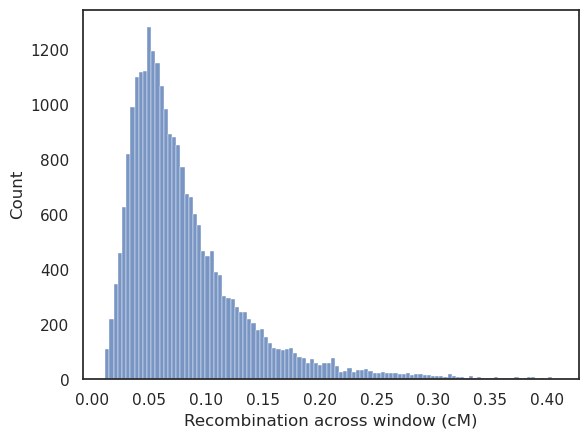

In [92]:
g = sns.histplot(filter_qcut_recomb.loc[filter_qcut_recomb.Origin.isin(gog)], x="window_cM")
g.set(xlabel="Recombination across window (cM)")

In [93]:
filter_qcut_recomb.loc[filter_qcut_recomb.Origin.isin(gog)]["window_cM"].mean(), filter_qcut_recomb.loc[filter_qcut_recomb.Origin.isin(gog)]["window_cM"].median()

(0.08147665195026459, 0.06682527339771838)

[Text(0.5, 0, 'Recombination across window (cM)')]

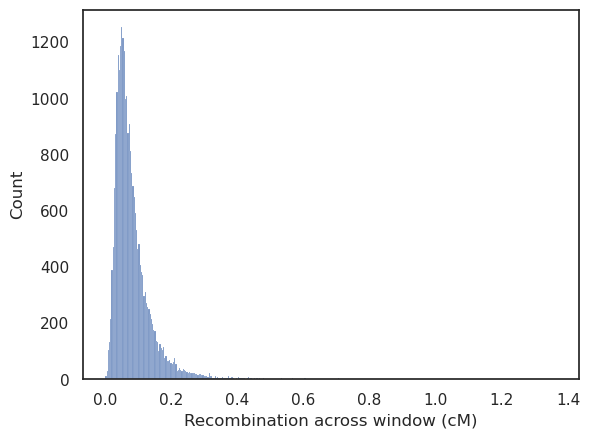

In [94]:
g = sns.histplot(filter_callable.loc[filter_callable.Origin.isin(gog)], x="window_cM")
g.set(xlabel="Recombination across window (cM)")

In [95]:
filter_callable.loc[filter_callable.Origin.isin(gog)]["window_cM"].mean(), filter_callable.loc[filter_callable.Origin.isin(gog)]["window_cM"].median()

(0.08348644026964483, 0.06682536781364945)

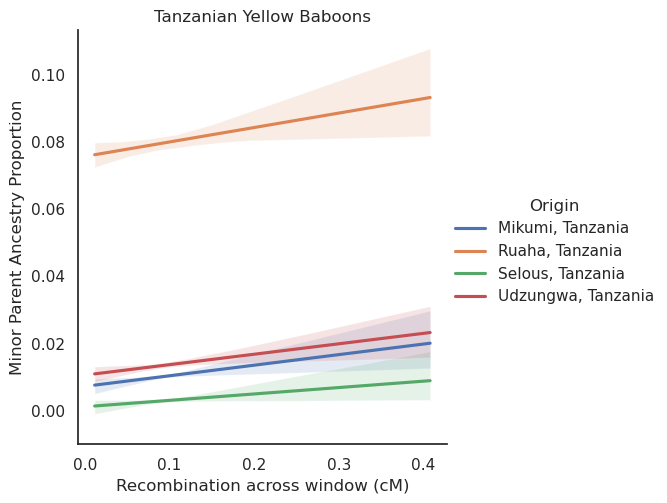

In [96]:
g = lmplot(filter_qcut_recomb.loc[filter_qcut_recomb.Origin.isin(yellows)], x="window_cM", y="minor_parent_percentage",
                            scatter=False, hue="Origin", weighted=True, n_boot=1000, ci=99.5)
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Recombination across window (cM)", title="Tanzanian Yellow Baboons")
g.set(ylim=(-0.01, None))

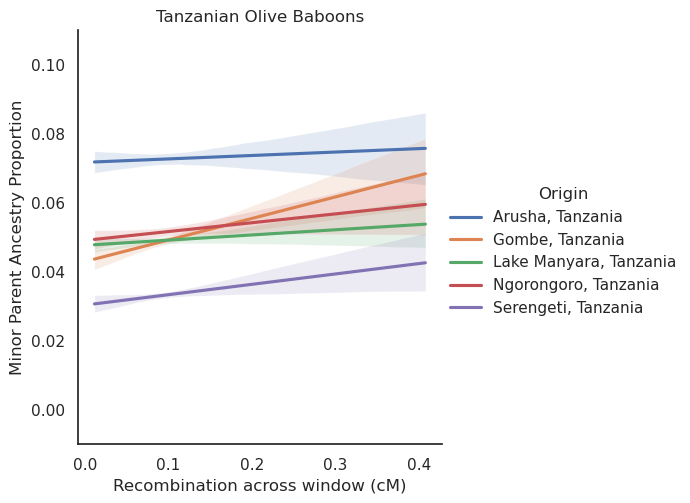

In [97]:
g = lmplot(filter_qcut_recomb.loc[filter_qcut_recomb.Origin.isin(olives)], x="window_cM", y="minor_parent_percentage",
                            scatter=False, hue="Origin", weighted=True, n_boot=1000, ci=95)
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Recombination across window (cM)", title="Tanzanian Olive Baboons")
g.set(ylim=(-0.01, 0.11))

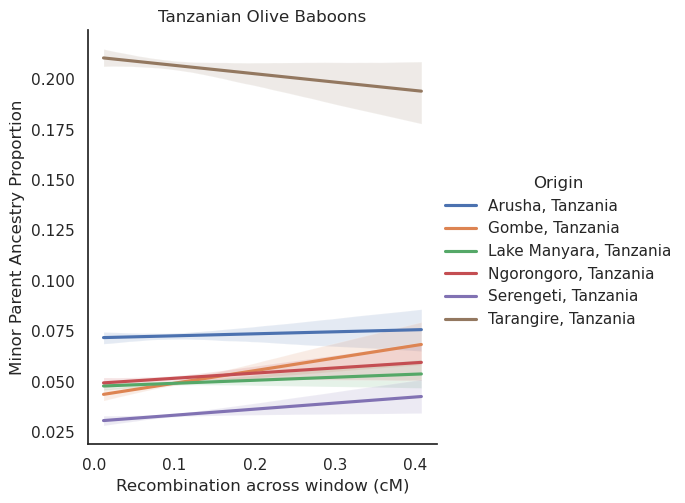

In [98]:
g = lmplot(filter_qcut_recomb.loc[filter_qcut_recomb.Origin.isin(olives_with_tarangire)], x="window_cM", y="minor_parent_percentage",
                            scatter=False, hue="Origin", weighted=True, n_boot=1000, ci=95)
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Recombination across window (cM)", title="Tanzanian Olive Baboons")
#g.set(ylim=(-0.01, 0.11))

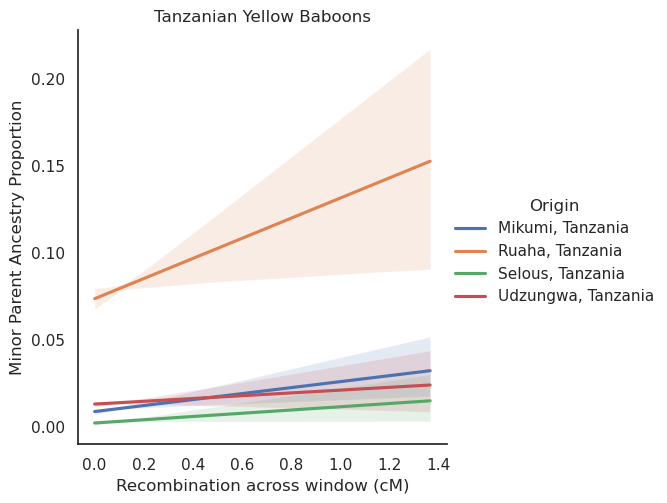

In [99]:
g = lmplot(filter_callable.loc[filter_callable.Origin.isin(yellows)], x="window_cM", y="minor_parent_percentage",
                            scatter=False, hue="Origin", weighted=True, n_boot=1000, ci=99.5)
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Recombination across window (cM)", title="Tanzanian Yellow Baboons")
g.set(ylim=(-0.01, None))

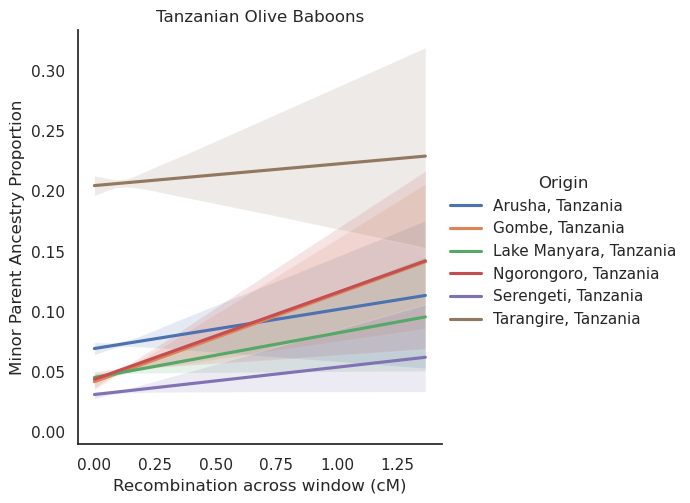

In [100]:
g = lmplot(filter_callable.loc[filter_callable.Origin.isin(olives_with_tarangire)], x="window_cM", y="minor_parent_percentage",
                            scatter=False, hue="Origin", weighted=True, n_boot=1000, ci=99.5)
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Recombination across window (cM)", title="Tanzanian Olive Baboons")
g.set(ylim=(-0.01, None))

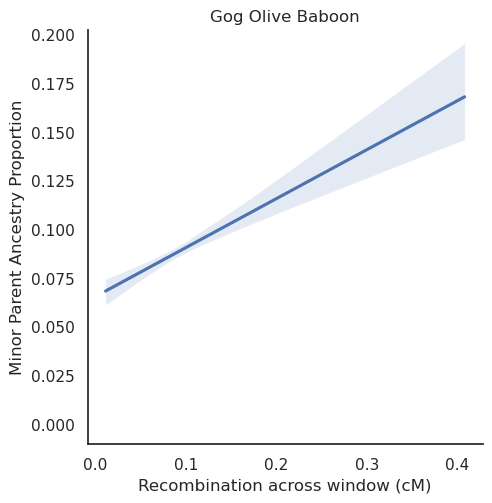

In [101]:
g = lmplot(filter_qcut_recomb.loc[filter_qcut_recomb.Origin.isin(gog)], x="window_cM", y="minor_parent_percentage",
                            scatter=False, weighted=True, n_boot=1000, ci=99.5)
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Recombination across window (cM)", title="Gog Olive Baboon")
g.set(ylim=(-0.01, None))

[Text(0.5, 0, 'Recombination across window (cM)'),
 Text(0, 0.5, 'Background Diversity')]

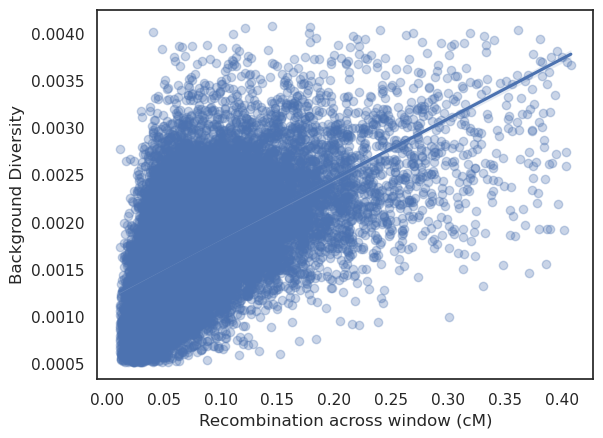

In [102]:
norm_filter = filter_qcut_recomb.loc[(filter_qcut_recomb.diversity >= 0.000513) &
                                 (filter_qcut_recomb.diversity <= 0.00408)]
g = sns.regplot(norm_filter.loc[(norm_filter.Origin == "Serengeti, Tanzania") &
                              #(admix_div_mean["minor_parent_percentage"] < 0.5) &
                              (norm_filter.callable_frac > 0.75)], x="window_cM", y="diversity",
                            ci=95, scatter_kws={'alpha':0.3})
g.set(xlabel="Recombination across window (cM)", ylabel = "Background Diversity")

In [103]:
stats.pearsonr(norm_filter.window_cM, norm_filter.diversity)

PearsonRResult(statistic=0.5731279101957095, pvalue=0.0)

In [104]:
norm_filter["norm_diversity"] = (norm_filter.diversity-norm_filter.diversity.mean())/(norm_filter.diversity.std())
norm_filter["norm_recomb"] = (norm_filter.window_cM-norm_filter.window_cM.mean())/(norm_filter.window_cM.std())

/tmp/47761274/ipykernel_4122384/1414838712.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  norm_filter["norm_diversity"] = (norm_filter.diversity-norm_filter.diversity.mean())/(norm_filter.diversity.std())
/tmp/47761274/ipykernel_4122384/1414838712.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  norm_filter["norm_recomb"] = (norm_filter.window_cM-norm_filter.window_cM.mean())/(norm_filter.window_cM.std())


In [105]:
o_l, cd_l, cr_l, nd_l, rd_l = [], [], [], [], []
for o in result_order:
    o_div = norm_filter.loc[norm_filter.Origin == o]
    glm_results = smf.glm(formula = "minor_parent_percentage ~ norm_diversity", data=o_div
                         ).fit()
    print(o, glm_results.summary2(), glm_results.pvalues, glm_results.f_test(np.identity(len(glm_results.params))[1:,:]))
    #o_l.append(o), cd_l.append(glm_results.params[1]), cr_l.append(glm_results.params[2])
    #nd_l.append(glm_results.pvalues[1]), rd_l.append(glm_results.pvalues[2])

Selous, Tanzania                    Results: Generalized linear model
Model:              GLM                     AIC:            -112542.6929
Link Function:      Identity                BIC:            -255410.3318
Dependent Variable: minor_parent_percentage Log-Likelihood: 56273.      
Date:               2026-07-08 12:01        LL-Null:        56271.      
No. Observations:   25205                   Deviance:       16.974      
Df Model:           1                       Pearson chi2:   17.0        
Df Residuals:       25203                   Scale:          0.00067348  
Method:             IRLS                                                
--------------------------------------------------------------------------
                  Coef.    Std.Err.      z      P>|z|     [0.025    0.975]
--------------------------------------------------------------------------
Intercept         0.0031     0.0002   19.1352   0.0000    0.0028    0.0034
norm_diversity   -0.0003     0.0002   -2.0193 

Gog Woreda, Ethiopia                    Results: Generalized linear model
Model:              GLM                     AIC:            -24849.5424 
Link Function:      Identity                BIC:            -254776.9644
Dependent Variable: minor_parent_percentage Log-Likelihood: 12427.      
Date:               2026-07-08 12:01        LL-Null:        12196.      
No. Observations:   25196                   Deviance:       550.13      
Df Model:           1                       Pearson chi2:   550.        
Df Residuals:       25194                   Scale:          0.021836    
Method:             IRLS                                                
--------------------------------------------------------------------------
                    Coef.    Std.Err.      z      P>|z|    [0.025   0.975]
--------------------------------------------------------------------------
Intercept           0.0866     0.0009   92.9828   0.0000   0.0847   0.0884
norm_diversity      0.0200     0.0009   21

In [106]:
o_l, cd_l, cr_l, nd_l, rd_l = [], [], [], [], []
for o in result_order:
    o_div = norm_filter.loc[norm_filter.Origin == o]
    glm_results = smf.glm(formula = "minor_parent_percentage ~ diversity + window_cM", data=o_div
                         ).fit()
    print(o, glm_results.summary2(), glm_results.pvalues, glm_results.f_test(np.identity(len(glm_results.params))[1:,:]))
    o_l.append(o), cd_l.append(glm_results.params[1]), cr_l.append(glm_results.params[2])
    nd_l.append(glm_results.pvalues[1]), rd_l.append(glm_results.pvalues[2])

Selous, Tanzania                    Results: Generalized linear model
Model:              GLM                     AIC:            -112545.8008
Link Function:      Identity                BIC:            -255400.2005
Dependent Variable: minor_parent_percentage Log-Likelihood: 56276.      
Date:               2026-07-08 12:01        LL-Null:        56271.      
No. Observations:   25205                   Deviance:       16.970      
Df Model:           2                       Pearson chi2:   17.0        
Df Residuals:       25202                   Scale:          0.00067337  
Method:             IRLS                                                
---------------------------------------------------------------------------
              Coef.     Std.Err.       z       P>|z|      [0.025     0.975]
---------------------------------------------------------------------------
Intercept     0.0042      0.0005     8.1646    0.0000     0.0032     0.0052
diversity    -1.0156      0.3443    -2.950

Lake Manyara, Tanzania                    Results: Generalized linear model
Model:              GLM                     AIC:            -58374.5216 
Link Function:      Identity                BIC:            -255271.5956
Dependent Variable: minor_parent_percentage Log-Likelihood: 29190.      
Date:               2026-07-08 12:01        LL-Null:        29169.      
No. Observations:   25205                   Deviance:       145.58      
Df Model:           2                       Pearson chi2:   146.        
Df Residuals:       25202                   Scale:          0.0057763   
Method:             IRLS                                                
---------------------------------------------------------------------------
              Coef.     Std.Err.       z       P>|z|      [0.025     0.975]
---------------------------------------------------------------------------
Intercept     0.0435      0.0015    29.1325    0.0000     0.0406     0.0465
diversity     6.2204      1.0083    

In [108]:
o_l, cd_l, cr_l, nd_l, rd_l, i_l, id_l = [], [], [], [], [], [], []
for o in result_order:
    o_div = norm_filter.loc[norm_filter.Origin == o]
    glm_results = smf.glm(formula = "minor_parent_percentage ~ norm_diversity * norm_recomb", data=o_div
                         ).fit()
    print(o, glm_results.summary2(), glm_results.pvalues, glm_results.f_test(np.identity(len(glm_results.params))[1:,:]))
    o_l.append(o), cd_l.append(glm_results.params[1]), cr_l.append(glm_results.params[2])
    nd_l.append(glm_results.pvalues[1]), rd_l.append(glm_results.pvalues[2])
    i_l.append(glm_results.params[3]), id_l.append(glm_results.pvalues[3])

Selous, Tanzania                     Results: Generalized linear model
Model:                GLM                     AIC:            -112551.2121
Link Function:        Identity                BIC:            -255390.0707
Dependent Variable:   minor_parent_percentage Log-Likelihood: 56280.      
Date:                 2026-07-08 12:01        LL-Null:        56271.      
No. Observations:     25205                   Deviance:       16.965      
Df Model:             3                       Pearson chi2:   17.0        
Df Residuals:         25201                   Scale:          0.00067320  
Method:               IRLS                                                
--------------------------------------------------------------------------
                            Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
--------------------------------------------------------------------------
Intercept                   0.0029   0.0002 16.1378 0.0000  0.0026  0.0033
norm_diversity             -0

Gombe, Tanzania                     Results: Generalized linear model
Model:                GLM                     AIC:            -54924.6661 
Link Function:        Identity                BIC:            -255240.1209
Dependent Variable:   minor_parent_percentage Log-Likelihood: 27466.      
Date:                 2026-07-08 12:01        LL-Null:        27400.      
No. Observations:     25205                   Deviance:       166.92      
Df Model:             3                       Pearson chi2:   167.        
Df Residuals:         25201                   Scale:          0.0066234   
Method:               IRLS                                                
--------------------------------------------------------------------------
                            Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
--------------------------------------------------------------------------
Intercept                   0.0481   0.0006 84.7666 0.0000  0.0470  0.0492
norm_diversity              0.

In [109]:
pd.DataFrame({"Origin": o_l, "Recombination Slope": cr_l, "Diversity Slope": cd_l, "Interaction Slope": i_l,
              "Recombination p-val": rd_l, "Diversity p-val": nd_l, "Interaction p-val": id_l})

,Origin,Recombination Slope,Diversity Slope,Interaction Slope,Recombination p-val,Diversity p-val,Interaction p-val
0,"Selous, Tanzania",0.000136,-0.000554,0.000367,0.557,0.00556,0.00648
1,"Mikumi, Tanzania",0.000195,0.000755,0.000214,0.392,0.000133,0.108
2,"Udzungwa, Tanzania",-0.000528,0.00207,0.000448,0.162,2.65e-10,0.0427
3,"Ruaha, Tanzania",-0.00443,0.00616,0.00196,4e-07,4.26e-16,0.00013
4,"Tarangire, Tanzania",-0.00764,7.1e-05,0.0037,1.9e-07,0.955,1.58e-05
5,"Arusha, Tanzania",-0.00152,0.00153,0.000459,0.156,0.101,0.464
6,"Ngorongoro, Tanzania",-0.00245,0.00368,0.00108,0.00454,9.03e-07,0.0326
7,"Gombe, Tanzania",-0.00492,0.0069,0.00174,9.82e-12,3.75e-28,3.72e-05
8,"Lake Manyara, Tanzania",-0.00425,0.00374,0.0015,2.98e-10,1.56e-10,0.00014
9,"Serengeti, Tanzania",-0.00293,0.00351,0.00072,6.36e-08,7.17e-14,0.023


In [110]:
o_l, slope_l, intercept_l, pval_slope_l, pval_intercept_l, stderr_slope_l, stderr_intercept_l = [], [], [], [], [], [], []
for o in result_order:
    o_div = norm_filter.loc[norm_filter.Origin == o]
    glm_results = smf.ols(formula = "minor_parent_percentage ~ norm_diversity", data=o_div
                         ).fit()
    print(o, glm_results.summary2())

Selous, Tanzania                       Results: Ordinary least squares
Model:              OLS                     Adj. R-squared:     0.000       
Dependent Variable: minor_parent_percentage AIC:                -112542.6929
Date:               2026-07-08 12:01        BIC:                -112526.4233
No. Observations:   25205                   Log-Likelihood:     56273.      
Df Model:           1                       F-statistic:        4.078       
Df Residuals:       25203                   Prob (F-statistic): 0.0435      
R-squared:          0.000                   Scale:              0.00067348  
------------------------------------------------------------------------------
                      Coef.    Std.Err.      t      P>|t|     [0.025    0.975]
------------------------------------------------------------------------------
Intercept             0.0031     0.0002   19.1352   0.0000    0.0028    0.0034
norm_diversity       -0.0003     0.0002   -2.0193   0.0435   -0.0007   -0.

Ngorongoro, Tanzania                       Results: Ordinary least squares
Model:              OLS                     Adj. R-squared:     0.001      
Dependent Variable: minor_parent_percentage AIC:                -45938.9536
Date:               2026-07-08 12:01        BIC:                -45922.6841
No. Observations:   25205                   Log-Likelihood:     22971.     
Df Model:           1                       F-statistic:        19.47      
Df Residuals:       25203                   Prob (F-statistic): 1.03e-05   
R-squared:          0.001                   Scale:              0.0094611  
------------------------------------------------------------------------------
                   Coef.     Std.Err.       t       P>|t|     [0.025    0.975]
------------------------------------------------------------------------------
Intercept          0.0514      0.0006    83.8555    0.0000    0.0502    0.0526
norm_diversity     0.0027      0.0006     4.4125    0.0000    0.0015    0.003

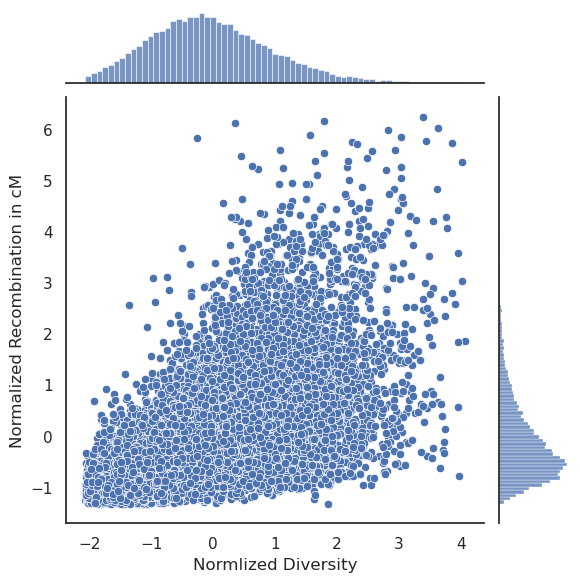

In [111]:
g = sns.jointplot(norm_filter.loc[(norm_filter.Origin == "Serengeti, Tanzania") &
                              #(admix_div_mean["minor_parent_percentage"] < 0.5) &
                              (norm_filter.callable_frac > 0.9)], x="norm_diversity", y="norm_recomb")
g.set_axis_labels(xlabel="Normlized Diversity", ylabel="Normalized Recombination in cM")

In [112]:
ser_div = admix_div_mean.loc[admix_div_mean.Origin == "Serengeti, Tanzania"].reset_index()
ser_div["tarangire_diff"] = (admix_div_mean.loc[admix_div_mean.Origin == "Serengeti, Tanzania"].minor_parent_percentage.reset_index()-admix_div_mean.loc[admix_div_mean.Origin == "Tarangire, Tanzania"].minor_parent_percentage.reset_index()).minor_parent_percentage
ser_div = ser_div.loc[(ser_div.callable_frac > 0.9)]
glm_results = smf.glm(formula = "tarangire_diff ~ diversity", data=ser_div,
                         var_weights=np.asarray(ser_div.diversity)
                         ).fit()
print(glm_results.summary(), glm_results.pvalues[1])

                 Generalized Linear Model Regression Results                  
Dep. Variable:         tarangire_diff   No. Observations:                22963
Model:                            GLM   Df Residuals:                    22961
Model Family:                Gaussian   Df Model:                            1
Link Function:               Identity   Scale:                      4.8209e-05
Method:                          IRLS   Log-Likelihood:                 7501.7
Date:                Wed, 08 Jul 2026   Deviance:                       1.1069
Time:                        12:01:25   Pearson chi2:                     1.11
No. Iterations:                     3   Pseudo R-squ. (CS):          0.0009410
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1895      0.003    -58.824      0.0

In [113]:
yellow_pops = filter_qcut_recomb.loc[filter_qcut_recomb.Origin.isin(["Mikumi, Tanzania", "Ruaha, Tanzania"])]
glm_results = smf.glm(formula = "minor_parent_percentage ~ diversity*Origin", data=yellow_pops,
                         var_weights=np.asarray(yellow_pops.diversity)
                         ).fit()
print(glm_results.summary(), glm_results.pvalues[0], glm_results.pvalues[3])

                    Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                50802
Model:                                 GLM   Df Residuals:                    50798
Model Family:                     Gaussian   Df Model:                            3
Link Function:                    Identity   Scale:                      9.1288e-06
Method:                               IRLS   Log-Likelihood:                 59291.
Date:                     Wed, 08 Jul 2026   Deviance:                      0.46373
Time:                             12:01:25   Pearson chi2:                    0.464
No. Iterations:                          3   Pseudo R-squ. (CS):             0.2146
Covariance Type:                 nonrobust                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------

ChrX case

In [114]:
chrX_mean = mean_window_df_tanz_eth.loc[mean_window_df_tanz_eth.chrom == "all_chrX"]
chrX_mean["chrom"] = "chrX"
admix_div_chrX_all = mean_diversity.merge(chrX_mean, on=["chrom", "start"])
admix_div_chrX_all["North Percentage"] = admix_div_chrX_all.north_sum/100000
admix_div_chrX_all = admix_div_chrX_all.merge(c_r_g_df, on=["chrom", "start"])
admix_div_chrX_all["Species"] = admix_div_chrX_all.Origin.map(dict(zip(meta_data_samples_sci.Origin, meta_data_samples_sci.Species)))


/tmp/47761274/ipykernel_4122384/4154381476.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chrX_mean["chrom"] = "chrX"


In [115]:
#Selecting the cases of interest and setting Minor Parent Ancestry
origins_interest = ['Arusha, Tanzania',
       'Gog Woreda, Gambella region, Ethiopia',
       'Gog Woreda, Gambella region, Ethiopia_eth_case',
       'Gombe, Tanzania', 'Issa Valley, Tanzania',
       'Katavi, Tanzania','Lake Manyara, Tanzania',
       'Mahale, Tanzania',
       'Mikumi, Tanzania', 'Ngorongoro, Tanzania', 'Ruaha, Tanzania',
       'Selous, Tanzania', 'Serengeti, Tanzania', 'Tarangire, Tanzania',
       'Udzungwa, Tanzania']
admix_div_chrX_all = admix_div_chrX_all.loc[admix_div_chrX_all.Origin.isin(origins_interest)]
admix_div_chrX_all["minor_parent_percentage"] = [x if y == ("cynocephalus") or z == "Gog Woreda, Gambella region, Ethiopia_eth_case"
                                             else 1-x for x, y, z in zip(admix_div_chrX_all["North Percentage"],
                                                                         admix_div_chrX_all["Species"],
                                                                        admix_div_chrX_all["Origin"])]
admix_div_chrX_all["local_minor_ancestry"] = [min(x, 1-x) for x in admix_div_chrX_all["North Percentage"]]
filter_callable_chrX = admix_div_chrX_all.loc[admix_div_chrX_all.callable_frac > 0.9]
filter_callable_chrX.loc[filter_callable_chrX['Origin'] == 'Gog Woreda, Gambella region, Ethiopia_eth_case', ['Origin']] = 'Gog Woreda, Ethiopia'
filter_callable_chrX["diversity"].quantile([0.005, 0.995])

0.005     0.000147
0.995      0.00156
Name: diversity, dtype: float64

Plot of difference in frequencies across the autosome and ChrX.

In [116]:
filter_callable_all = pd.concat([filter_callable_chrX, filter_callable])
filter_callable_all["chrom_type"] = ["autosome" if x != "chrX" else "chrX" for x in filter_callable_all.chrom]

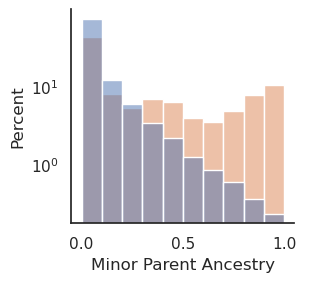

In [117]:
g = sns.FacetGrid(filter_callable_all.loc[filter_callable_all.Origin.isin(["Gog Woreda, Ethiopia"])])
g.map_dataframe(sns.histplot, x="minor_parent_percentage", hue="chrom_type", hue_order=["autosome", "chrX"],
                 common_norm = False, bins=10, stat="percent") 
g.add_legend()
g.set(yscale="log")
#g.set_titles(col_template="{col_name}")
g.set(xlabel="Minor Parent Ancestry")

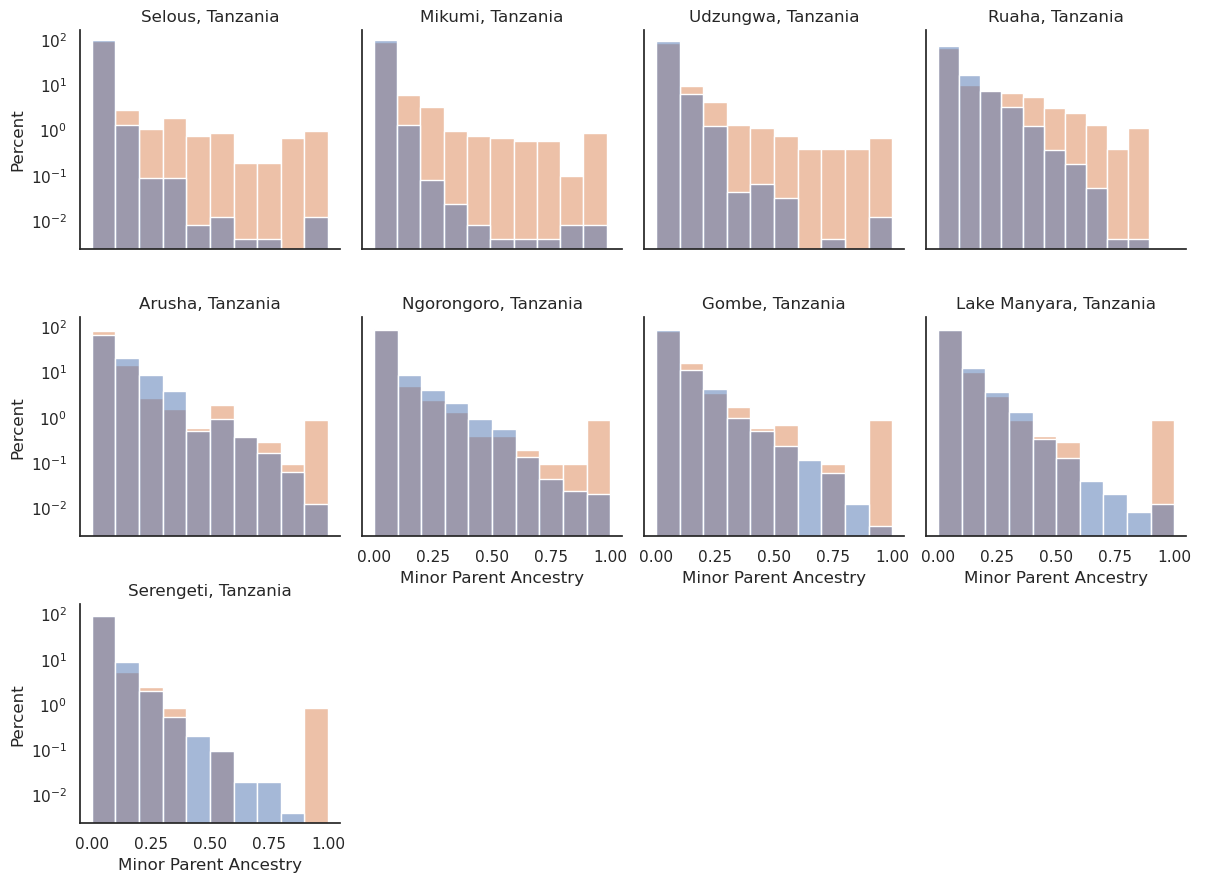

In [118]:
g = sns.FacetGrid(filter_callable_all.loc[filter_callable_all.Origin.isin(result_order_no_gog)], col="Origin",
                  col_wrap = 4, col_order=result_order_no_gog,legend_out=True)
g.map_dataframe(sns.histplot, x="minor_parent_percentage", hue="chrom_type", hue_order=["autosome", "chrX"],
                 common_norm = False, bins=10, stat="percent") 
g.add_legend()
g.set(yscale="log")
g.set_titles(col_template="{col_name}")
g.set(xlabel="Minor Parent Ancestry")


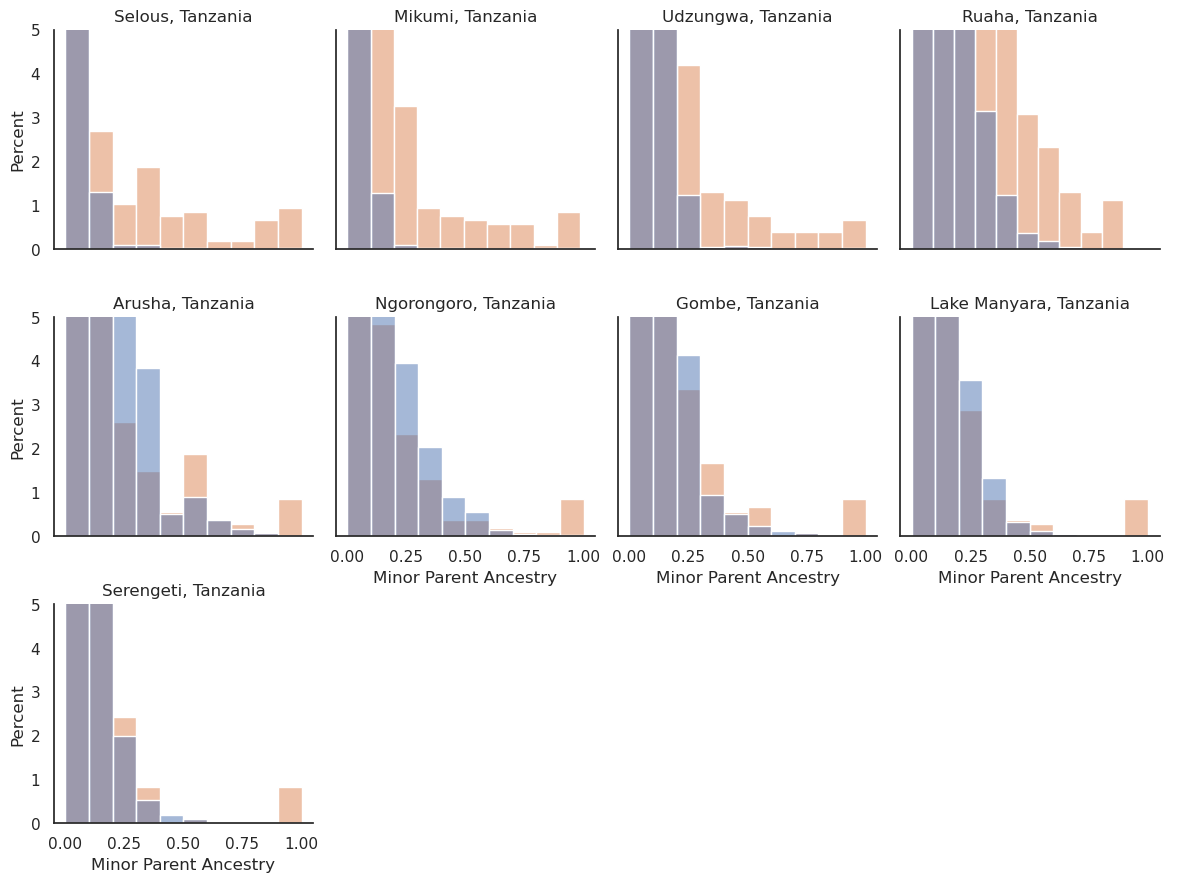

In [119]:
g = sns.FacetGrid(filter_callable_all.loc[filter_callable_all.Origin.isin(result_order_no_gog)], col="Origin",
                  col_wrap = 4, col_order=result_order_no_gog,legend_out=True)
g.map_dataframe(sns.histplot, x="minor_parent_percentage", hue="chrom_type", hue_order=["autosome", "chrX"],
                 common_norm = False, bins=10, stat="percent") 
g.add_legend()
g.set(ylim=(0, 5))
g.set_titles(col_template="{col_name}")
g.set(xlabel="Minor Parent Ancestry")

In [120]:
result_order_no_gog_tarangire = ['Selous, Tanzania',
 'Mikumi, Tanzania',
 'Udzungwa, Tanzania',
 'Ruaha, Tanzania',
"Tarangire, Tanzania",
 'Arusha, Tanzania',
 'Ngorongoro, Tanzania',
 'Gombe, Tanzania',
 'Lake Manyara, Tanzania',
 'Serengeti, Tanzania']

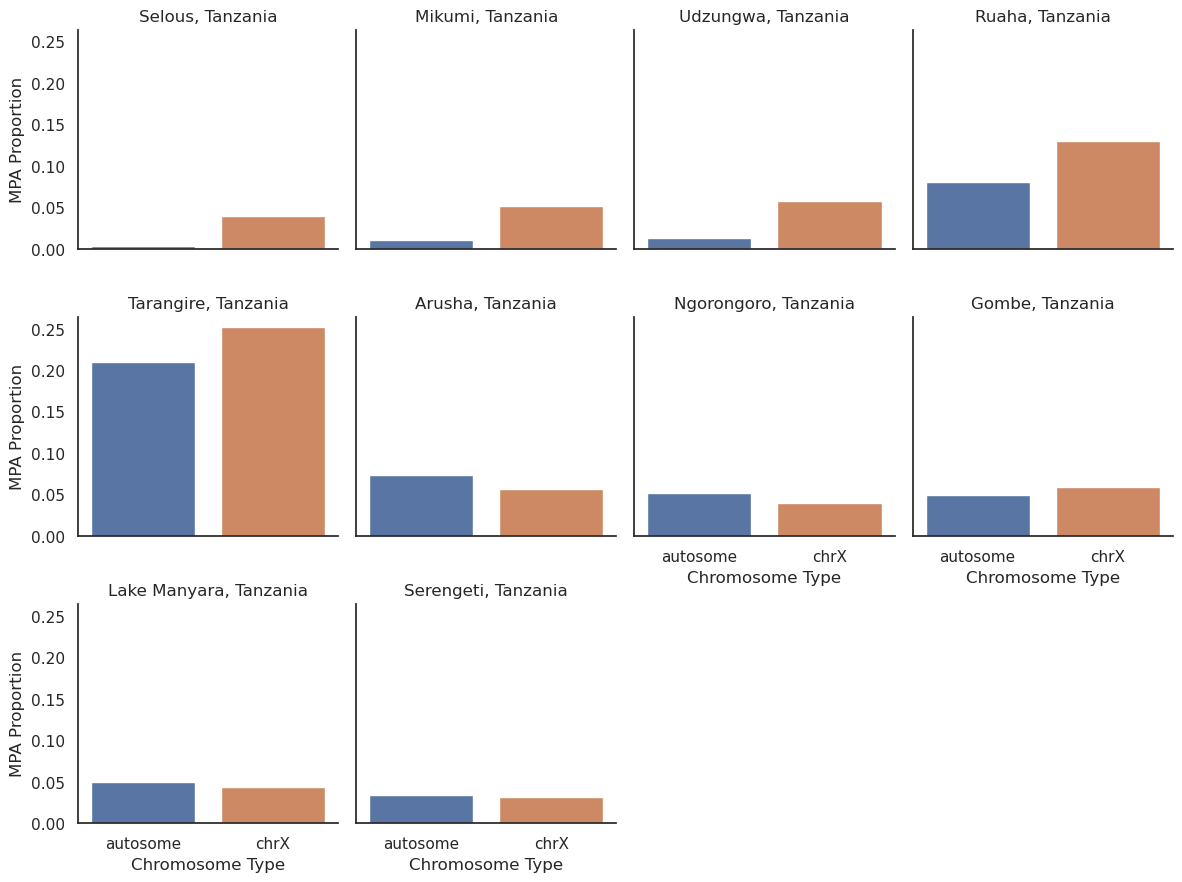

In [121]:
g = sns.FacetGrid(filter_callable_all.loc[filter_callable_all.Origin.isin(result_order_no_gog_tarangire)].sort_values(by=["chrom"]), col="Origin",
                  col_wrap = 4, col_order=result_order_no_gog_tarangire)
g.map_dataframe(sns.barplot, y="minor_parent_percentage", x="chrom_type", palette=sns.color_palette(), errorbar=None) 
g.set_titles(col_template="{col_name}")
g.set(xlabel="Chromosome Type", ylabel="MPA Proportion")

In [122]:
filter_callable_all.loc[filter_callable_all.Origin.isin(gog)].chrom.unique()

array(['chrX', 'chr1', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14',
       'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr2', 'chr20',
       'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9'],
      dtype=object)

In [123]:
filter_qcut_chrX = filter_callable_chrX.loc[(filter_callable_chrX.diversity >= 0.000147) & 
                                           (filter_callable_chrX.diversity <= 0.00156)]

In [124]:
filter_qcut.loc[filter_qcut.Origin.isin(gog)].diversity.mean(), filter_qcut_chrX.loc[filter_qcut_chrX.Origin.isin(gog)].diversity.mean()

(0.0017118524695634901, 0.0006392304305855299)

In [125]:
filter_qcut_chrX.loc[filter_qcut_chrX.Origin.isin(gog)].diversity.mean()/filter_qcut.loc[filter_qcut.Origin.isin(gog)].diversity.mean()

0.3734144395915899

In [126]:
from scipy.stats import mannwhitneyu
res = mannwhitneyu(filter_qcut.loc[filter_qcut.Origin.isin(gog)].diversity*0.75,
                   filter_qcut_chrX.loc[filter_qcut_chrX.Origin.isin(gog)].diversity, alternative="greater")
print(res)

MannwhitneyuResult(statistic=24084280.0, pvalue=0.0)


In [127]:
import statsmodels.api as sm
df_l = []
for o in result_order:
    o_div = filter_qcut_chrX.loc[filter_qcut_chrX.Origin == o]
    Y = o_div["minor_parent_percentage"]
    X = o_div.diversity
    X = sm.add_constant(X)
    model = sm.OLS(Y,X)
    results = model.fit()
    print(o)
    #print(results.t_test([1, 0]))
    het_test = sm.stats.het_breuschpagan(resid=results.resid, exog_het=X)
    print(het_test)
    #print(sm.stats.diagnostic.linear_harvey_collier(results))
    df_l.append(list(het_test))
bp_df = pd.DataFrame(df_l, columns=["Lagrange Multiplier", "Lagrange Multiplier P-value", "F-statistic", "F-statistic P-value"])
bp_df["Origin"] = result_order
bp_df

Selous, Tanzania
(8.53660644255287, 0.0034807398432332706, 8.589524767656314, 0.0034534871951767228)
Mikumi, Tanzania
(7.2021339210137825, 0.0072816944956485595, 7.237620320804808, 0.007251264067962557)
Udzungwa, Tanzania
(6.816892720289332, 0.009029954694005844, 6.847982254569008, 0.009000320514934499)
Ruaha, Tanzania
(4.049160296961743, 0.044193322274407365, 4.056995767887763, 0.04424069346176127)
Tarangire, Tanzania
(1.762133275036943, 0.18435865236398413, 1.7617383090408738, 0.18469337463397167)
Arusha, Tanzania
(12.052930497583995, 0.0005171102365125881, 12.168223908737176, 0.0005060383519356125)
Ngorongoro, Tanzania
(17.76878021954807, 2.49442945241183e-05, 18.036847212524403, 2.3567221832440888e-05)
Gombe, Tanzania
(10.261710290251562, 0.0013581970865273484, 10.342242439912383, 0.001339477679058115)
Lake Manyara, Tanzania
(10.497393338518277, 0.0011954306936788539, 10.582144178717579, 0.0011778546813388244)
Serengeti, Tanzania
(9.538638825880605, 0.002011908950542084, 9.60689795

,Lagrange Multiplier,Lagrange Multiplier P-value,F-statistic,F-statistic P-value,Origin
0,8.54,0.00348,8.59,0.00345,"Selous, Tanzania"
1,7.2,0.00728,7.24,0.00725,"Mikumi, Tanzania"
2,6.82,0.00903,6.85,0.009,"Udzungwa, Tanzania"
3,4.05,0.0442,4.06,0.0442,"Ruaha, Tanzania"
4,1.76,0.184,1.76,0.185,"Tarangire, Tanzania"
5,12.1,0.000517,12.2,0.000506,"Arusha, Tanzania"
6,17.8,2.49e-05,18,2.36e-05,"Ngorongoro, Tanzania"
7,10.3,0.00136,10.3,0.00134,"Gombe, Tanzania"
8,10.5,0.0012,10.6,0.00118,"Lake Manyara, Tanzania"
9,9.54,0.00201,9.61,0.00199,"Serengeti, Tanzania"


/tmp/47761274/ipykernel_4122384/515002999.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter_qcut_chrX["Diversity Quantile"] = pd.qcut(filter_qcut_chrX.diversity, 5,


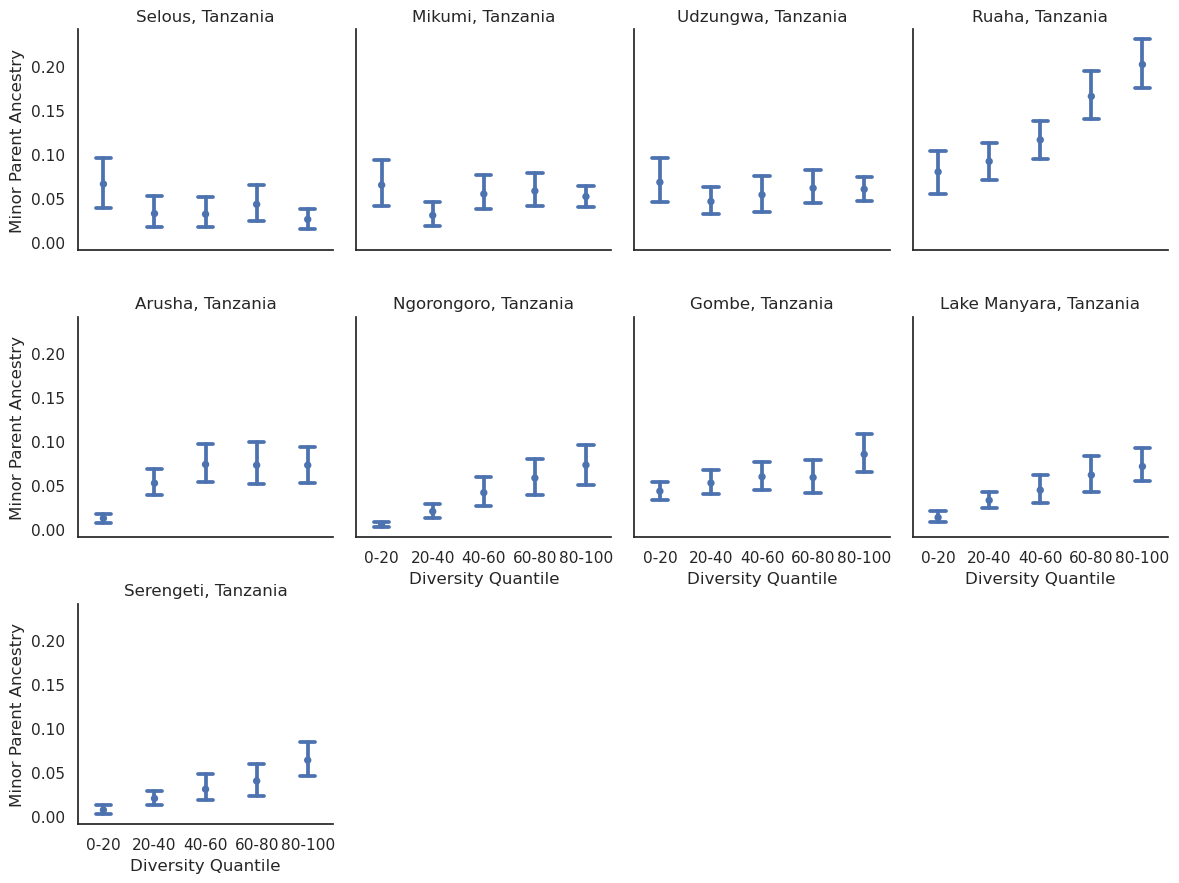

In [128]:
filter_qcut_chrX["Diversity Quantile"] = pd.qcut(filter_qcut_chrX.diversity, 5,
                                                       labels=["0-20","20-40",
                                                              "40-60","60-80",
                                                              "80-100"])
g = sns.FacetGrid(filter_qcut_chrX.loc[filter_qcut_chrX.Origin.isin(result_order_no_gog)], col="Origin",
                  col_wrap = 4, col_order=result_order_no_gog)
g.map_dataframe(sns.pointplot, y="minor_parent_percentage", x="Diversity Quantile", 
                linestyles="none", capsize=.3, errorbar=("ci", 95), scale = 0.6)
#g.map_dataframe(sns.stripplot, x="minor_parent_percentage", y="Diversity Quantile", alpha=0.05)
#g.set(xlim=(0, 0.25))
g.set_titles(col_template="{col_name}")
g.set(xlabel="Diversity Quantile", ylabel="Minor Parent Ancestry")

/tmp/47761274/ipykernel_4122384/3625251695.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter_qcut_chrX["Diversity Quantile"] = pd.qcut(filter_qcut_chrX.diversity, 5,
/tmp/47761274/ipykernel_4122384/3625251695.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter_qcut_chrX["chrom_type"] = "chrX"


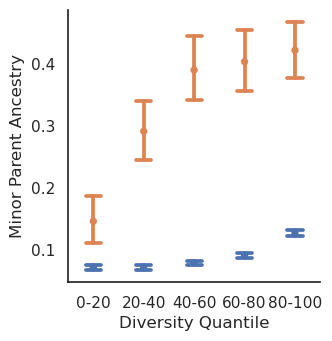

In [129]:
filter_qcut["Diversity Quantile"] = pd.qcut(filter_qcut.diversity, 5,
                                                       labels=["0-20","20-40",
                                                              "40-60","60-80",
                                                              "80-100"])
filter_qcut["chrom_type"] = "autosome"

filter_qcut_chrX["Diversity Quantile"] = pd.qcut(filter_qcut_chrX.diversity, 5,
                                                       labels=["0-20","20-40",
                                                              "40-60","60-80",
                                                              "80-100"])
filter_qcut_chrX["chrom_type"] = "chrX"
concat_df = pd.concat([filter_qcut, filter_qcut_chrX])

g = sns.FacetGrid(concat_df.loc[concat_df.Origin.isin(["Gog Woreda, Ethiopia"])], hue="chrom_type")
g.map_dataframe(sns.pointplot, y="minor_parent_percentage", x="Diversity Quantile", 
                linestyles="none", capsize=.3, errorbar=("ci", 95), scale = 0.6)
#g.map_dataframe(sns.stripplot, x="minor_parent_percentage", y="Diversity Quantile", alpha=0.05)
#g.set(xlim=(0, 0.25))
g.set_titles(col_template="{col_name}")
g.set(xlabel="Diversity Quantile", ylabel="Minor Parent Ancestry")
g.fig.set_figwidth(3.8)
g.fig.set_figheight(3.8)

In [130]:
o_l, low_l, high_l, effect_l, effect_hl_l = [], [], [], [], []
filter_qcut_chrX["Recombination Quantile"] = pd.qcut(filter_qcut_chrX.diversity, 5,
                                                       labels=["0-20","20-40",
                                                              "40-60","60-80",
                                                              "80-100"])
for o in result_order:
    s_df = filter_qcut_chrX.loc[filter_qcut_chrX.Origin == o]
    #print(o, s_df.groupby(["Recombination Quantile"])[["minor_parent_percentage"]].mean())
    low_mean = s_df.loc[s_df["Recombination Quantile"] == "0-20"][["minor_parent_percentage"]].mean()[0]*100
    high_mean = s_df.loc[s_df["Recombination Quantile"] == "80-100"][["minor_parent_percentage"]].mean()[0]*100
    o_l.append(o)
    low_l.append(low_mean)
    high_l.append(high_mean)
    effect_l.append(high_mean/low_mean-1)

mean_quantile_df = pd.DataFrame({"Origin": o_l, "0-20 Minor Parent Percentage": low_l, 
                        "80-100 Minor Parent Percentage": high_l, "Relative Increase": effect_l})
mean_quantile_df["Absolute Increase"] = mean_quantile_df["80-100 Minor Parent Percentage"]-mean_quantile_df["0-20 Minor Parent Percentage"]
mean_quantile_df

/tmp/47761274/ipykernel_4122384/3187102455.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter_qcut_chrX["Recombination Quantile"] = pd.qcut(filter_qcut_chrX.diversity, 5,


,Origin,0-20 Minor Parent Percentage,80-100 Minor Parent Percentage,Relative Increase,Absolute Increase
0,"Selous, Tanzania",6.56,2.54,-0.613,-4.02
1,"Mikumi, Tanzania",6.45,5.14,-0.203,-1.31
2,"Udzungwa, Tanzania",6.76,5.97,-0.118,-0.797
3,"Ruaha, Tanzania",7.94,20.1,1.54,12.2
4,"Tarangire, Tanzania",25.7,23.6,-0.0806,-2.07
5,"Arusha, Tanzania",1.21,7.25,4.98,6.04
6,"Ngorongoro, Tanzania",0.471,7.27,14.4,6.8
7,"Gombe, Tanzania",4.3,8.49,0.975,4.19
8,"Lake Manyara, Tanzania",1.31,7.1,4.44,5.8
9,"Serengeti, Tanzania",0.704,6.37,8.04,5.66


In [131]:
o_l, low_l, high_l, effect_l, effect_hl_l = [], [], [], [], []
filter_qcut_chrX["Diversity Quantile"] = pd.qcut(filter_qcut_chrX.diversity, 5,
                                                       labels=["0-20","20-40",
                                                              "40-60","60-80",
                                                              "80-100"])
for o in result_order:
    s_df = filter_qcut_chrX.loc[filter_qcut_chrX.Origin == o]
    #print(o, s_df.groupby(["Diversity Quantile"])[["minor_parent_percentage"]].mean())
    low_mean = s_df.loc[s_df["Diversity Quantile"] == "0-20"][["minor_parent_percentage"]].mean()[0]*100
    high_mean = s_df.loc[s_df["Diversity Quantile"] == "80-100"][["minor_parent_percentage"]].mean()[0]*100
    o_l.append(o)
    low_l.append(low_mean)
    high_l.append(high_mean)
    effect_l.append(high_mean/low_mean)

/tmp/47761274/ipykernel_4122384/2844885158.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter_qcut_chrX["Diversity Quantile"] = pd.qcut(filter_qcut_chrX.diversity, 5,


In [132]:
import statsmodels.formula.api as smf
import numpy as np
import pandas as pd

In [133]:
o_l, slope_l, intercept_l, pval_slope_l, pval_intercept_l, stderr_slope_l, stderr_intercept_l = [], [], [], [], [], [], []
for o in result_order:
    o_div = filter_qcut_chrX.loc[filter_qcut_chrX.Origin == o]
    glm_results = smf.glm(formula = "minor_parent_percentage ~ diversity", data=o_div,
                         var_weights=np.asarray(o_div["diversity"])).fit()
    print(o, glm_results.summary())
    o_l.append(o), slope_l.append(glm_results.params[1]), intercept_l.append(glm_results.params[0])
    pval_slope_l.append(glm_results.pvalues[1]), pval_intercept_l.append(glm_results.pvalues[0])
    stderr_slope_l.append(glm_results.bse[1]), stderr_intercept_l.append(glm_results.bse[0])

Selous, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                 1063
Model:                                 GLM   Df Residuals:                     1061
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      1.0851e-05
Method:                               IRLS   Log-Likelihood:                 596.21
Date:                     Wed, 08 Jul 2026   Deviance:                     0.011513
Time:                             12:01:35   Pearson chi2:                   0.0115
No. Iterations:                          3   Pseudo R-squ. (CS):           0.006131
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------

In [134]:
o_l, slope_l, intercept_l, pval_slope_l, pval_intercept_l, stderr_slope_l, stderr_intercept_l = [], [], [], [], [], [], []
for o in result_order:
    o_div = filter_qcut_chrX.loc[filter_qcut_chrX.Origin == o]
    glm_results = smf.glm(formula = "minor_parent_percentage ~ diversity", data=o_div,
                         var_weights=np.asarray(o_div["diversity"])).fit()
    print(o, glm_results.summary())
    o_l.append(o), slope_l.append(glm_results.params[1]), intercept_l.append(glm_results.params[0])
    pval_slope_l.append(glm_results.pvalues[1]), pval_intercept_l.append(glm_results.pvalues[0])
    stderr_slope_l.append(glm_results.bse[1]), stderr_intercept_l.append(glm_results.bse[0])

Selous, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                 1063
Model:                                 GLM   Df Residuals:                     1061
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      1.0851e-05
Method:                               IRLS   Log-Likelihood:                 596.21
Date:                     Wed, 08 Jul 2026   Deviance:                     0.011513
Time:                             12:01:35   Pearson chi2:                   0.0115
No. Iterations:                          3   Pseudo R-squ. (CS):           0.006131
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------

In [135]:
glm_diversity_df = pd.DataFrame({"Origin": o_l, "Intercept": intercept_l, "Slope": slope_l, 
                                 "Intercept P-value": pval_intercept_l, "Slope P-value": pval_slope_l,
                                "Intercept stderr": stderr_intercept_l, "Slope stderr": stderr_slope_l})
glm_diversity_df

,Origin,Intercept,Slope,Intercept P-value,Slope P-value,Intercept stderr,Slope stderr
0,"Selous, Tanzania",0.0605,-33.1,2.57e-08,0.0106,0.0109,13
1,"Mikumi, Tanzania",0.0505,1.64,1.14e-06,0.895,0.0104,12.4
2,"Udzungwa, Tanzania",0.0489,11.9,8.84e-06,0.366,0.011,13.1
3,"Ruaha, Tanzania",0.031,156,0.0502,1.79e-16,0.0158,18.9
4,"Tarangire, Tanzania",0.28,-40.3,4.35e-53,0.0643,0.0183,21.8
5,"Arusha, Tanzania",0.0399,32.1,0.00236,0.0403,0.0131,15.7
6,"Ngorongoro, Tanzania",-0.012,81.1,0.308,8.19e-09,0.0118,14.1
7,"Gombe, Tanzania",0.0188,61.7,0.108,9.83e-06,0.0117,14
8,"Lake Manyara, Tanzania",0.00314,65.6,0.772,3.69e-07,0.0108,12.9
9,"Serengeti, Tanzania",-0.0112,68,0.273,2.47e-08,0.0102,12.2


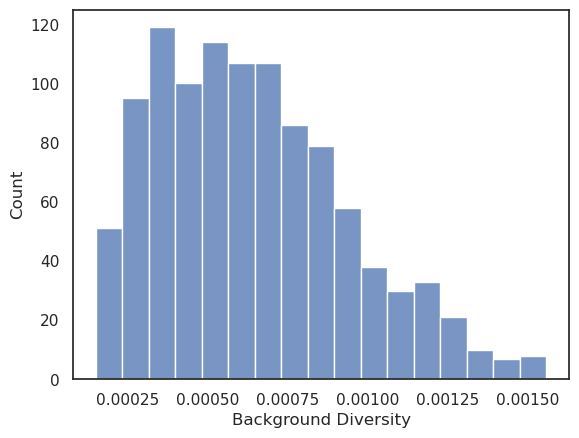

In [136]:
import matplotlib.ticker as ticker
g = sns.histplot(filter_qcut_chrX.loc[filter_qcut_chrX.Origin.isin(gog)], x="diversity", )
g.set(xlabel = "Background Diversity")
g.xaxis.set_major_locator(ticker.MultipleLocator(0.00025))

In [137]:
filter_qcut_chrX.loc[filter_qcut_chrX.Origin.isin(gog)].diversity.mean(), filter_qcut_chrX.loc[filter_qcut_chrX.Origin.isin(gog)].diversity.median()

(0.0006392304305855299, 0.0006023039215686274)

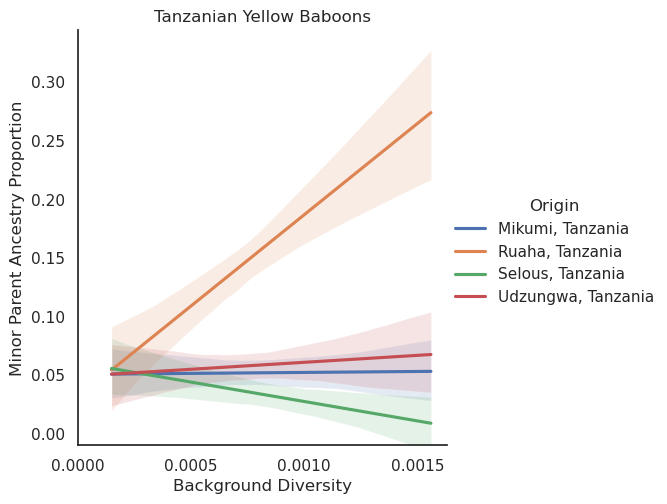

In [138]:
g = lmplot(filter_qcut_chrX.loc[filter_qcut_chrX.Origin.isin(yellows)], x="diversity", y="minor_parent_percentage",
                            scatter=False, hue="Origin", weighted=True, n_boot=1000, ci=99.5) #Additional bootstraps makes it take long
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Background Diversity", title="Tanzanian Yellow Baboons")
g.set(ylim=(-0.01, None))
g.set(xticks=[0, 0.0005, 0.001, 0.0015])

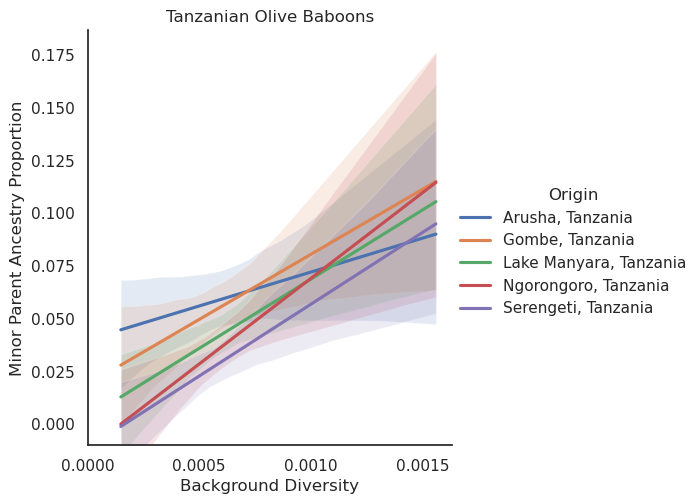

In [139]:
g = lmplot(filter_qcut_chrX.loc[filter_qcut_chrX.Origin.isin(olives)], x="diversity", y="minor_parent_percentage",
                            scatter=False, hue="Origin", weighted=True, n_boot=1000, ci=99.5) #Additional bootstraps makes it take long
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Background Diversity", title="Tanzanian Olive Baboons")
g.set(ylim=(-0.01, None))
g.set(xticks=[0, 0.0005, 0.001, 0.0015])

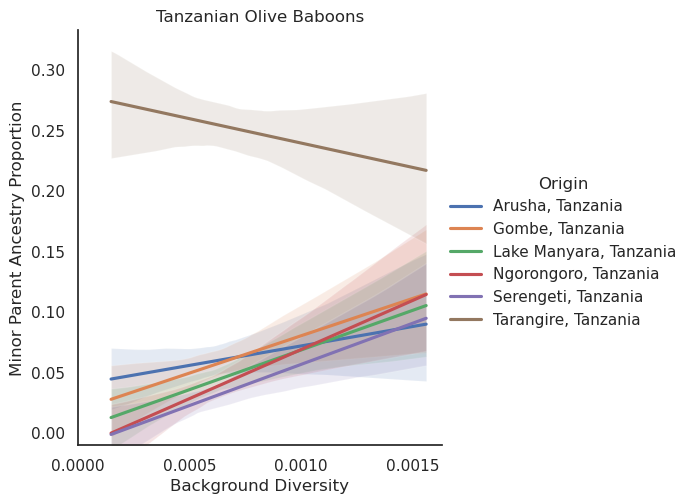

In [140]:
g = lmplot(filter_qcut_chrX.loc[filter_qcut_chrX.Origin.isin(olives_with_tarangire)], x="diversity", y="minor_parent_percentage",
                            scatter=False, hue="Origin", weighted=True, n_boot=1000, ci=99.5) #Additional bootstraps makes it take long
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Background Diversity", title="Tanzanian Olive Baboons")
g.set(ylim=(-0.01, None))
g.set(xticks=[0, 0.0005, 0.001, 0.0015])

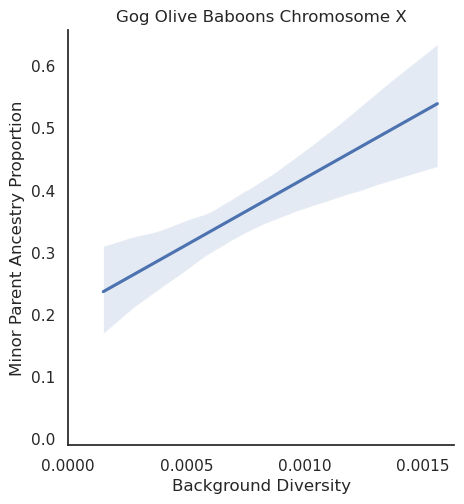

In [141]:
g = lmplot(filter_qcut_chrX.loc[filter_qcut_chrX.Origin.isin(gog)], x="diversity", y="minor_parent_percentage",
                            scatter=False, weighted=True, n_boot=1000, ci=99.5) #Additional bootstraps makes it take long
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Background Diversity", title="Gog Olive Baboons Chromosome X")
g.set(ylim=(-0.01, None))
g.set(xticks=[0, 0.0005, 0.001, 0.0015])

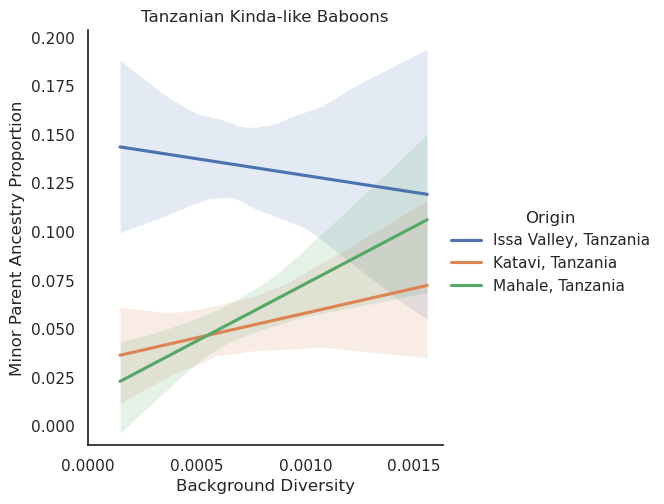

In [142]:
g = lmplot(filter_qcut_chrX.loc[filter_qcut_chrX.Origin.isin(["Mahale, Tanzania",
                                                           "Katavi, Tanzania",
                                                           "Issa Valley, Tanzania"])], x="diversity", y="minor_parent_percentage",
                            scatter=False, hue="Origin", weighted=True, n_boot=1000, ci=99.5) #Additional bootstraps makes it take long
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Background Diversity", title="Tanzanian Kinda-like Baboons")
g.set(ylim=(-0.01, None))
g.set(xticks=[0, 0.0005, 0.001, 0.0015])

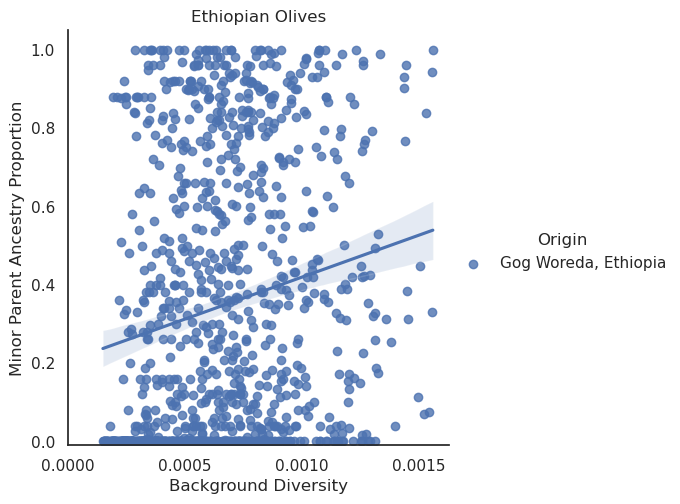

In [143]:
g = lmplot(filter_qcut_chrX.loc[filter_qcut_chrX.Origin.isin(gog)], x="diversity", y="minor_parent_percentage",
                             hue="Origin", weighted=True, n_boot=1000) #Additional bootstraps makes it take long
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Background Diversity", title="Ethiopian Olives")
g.set(ylim=(-0.01, None))
g.set(xticks=[0, 0.0005, 0.001, 0.0015])

In [144]:
filter_callable_chrX["average_cM_window"].quantile([0.005, 0.995])

0.005     1.96e-08
0.995     4.15e-06
Name: average_cM_window, dtype: float64

In [145]:
filter_qcut_recomb_chrX = filter_callable_chrX.loc[(filter_callable_chrX.average_cM_window >=1.96e-08) &
                                                      (filter_callable_chrX.average_cM_window <=4.15e-06)]
filter_qcut_recomb_chrX["window_cM"] = filter_qcut_recomb_chrX.average_cM_window*100000

/tmp/47761274/ipykernel_4122384/1395215121.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter_qcut_recomb_chrX["window_cM"] = filter_qcut_recomb_chrX.average_cM_window*100000


In [146]:
o_l, slope_l, intercept_l, pval_slope_l, pval_intercept_l, stderr_slope_l, stderr_intercept_l = [], [], [], [], [], [], []
for o in result_order:
    o_div = filter_qcut_recomb_chrX.loc[filter_qcut_recomb_chrX.Origin == o]
    glm_results = smf.glm(formula = "minor_parent_percentage ~ window_cM", data=o_div,
                         var_weights=np.asarray(o_div["diversity"])).fit()
    print(o, glm_results.summary())
    o_l.append(o), slope_l.append(glm_results.params[1]), intercept_l.append(glm_results.params[0])
    pval_slope_l.append(glm_results.pvalues[1]), pval_intercept_l.append(glm_results.pvalues[0])
    stderr_slope_l.append(glm_results.bse[1]), stderr_intercept_l.append(glm_results.bse[0])

Selous, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                 1063
Model:                                 GLM   Df Residuals:                     1061
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      1.0927e-05
Method:                               IRLS   Log-Likelihood:                 591.58
Date:                     Wed, 08 Jul 2026   Deviance:                     0.011594
Time:                             12:02:02   Pearson chi2:                   0.0116
No. Iterations:                          3   Pseudo R-squ. (CS):           0.001204
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------

In [147]:
glm_diversity_df = pd.DataFrame({"Origin": o_l, "Intercept": intercept_l, "Slope": slope_l, 
                                 "Intercept P-value": pval_intercept_l, "Slope P-value": pval_slope_l,
                                "Intercept stderr": stderr_intercept_l, "Slope stderr": stderr_slope_l})
glm_diversity_df

,Origin,Intercept,Slope,Intercept P-value,Slope P-value,Intercept stderr,Slope stderr
0,"Selous, Tanzania",0.0413,-0.075,1.8e-09,0.258,0.00686,0.0664
1,"Mikumi, Tanzania",0.0457,0.0751,2.91e-12,0.235,0.00654,0.0633
2,"Udzungwa, Tanzania",0.0479,0.122,4.06e-12,0.0672,0.0069,0.0668
3,"Ruaha, Tanzania",0.0961,0.658,5.88e-22,9.23e-12,0.00997,0.0965
4,"Tarangire, Tanzania",0.255,-0.0716,1.99e-109,0.519,0.0115,0.111
5,"Arusha, Tanzania",0.0479,0.201,6.34e-09,0.0118,0.00826,0.0798
6,"Ngorongoro, Tanzania",0.0235,0.337,0.00164,3.04e-06,0.00746,0.0722
7,"Gombe, Tanzania",0.0495,0.197,1.93e-11,0.00562,0.00737,0.0713
8,"Lake Manyara, Tanzania",0.0439,0.126,1.7e-10,0.0574,0.00687,0.0664
9,"Serengeti, Tanzania",0.0174,0.29,0.00695,3.57e-06,0.00646,0.0625


In [148]:
norm_filter_chrX = filter_qcut_chrX.loc[(filter_qcut_chrX.average_cM_window >=1.96e-08) &
                                                      (filter_qcut_chrX.average_cM_window <=4.15e-06)]
norm_filter_chrX["norm_diversity"] = (norm_filter_chrX.diversity-norm_filter_chrX.diversity.mean())/(norm_filter_chrX.diversity.std())
norm_filter_chrX["norm_recomb"] = (norm_filter_chrX.average_cM_window-norm_filter_chrX.average_cM_window.mean())/(norm_filter_chrX.average_cM_window.std())

/tmp/47761274/ipykernel_4122384/1252545395.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  norm_filter_chrX["norm_diversity"] = (norm_filter_chrX.diversity-norm_filter_chrX.diversity.mean())/(norm_filter_chrX.diversity.std())
/tmp/47761274/ipykernel_4122384/1252545395.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  norm_filter_chrX["norm_recomb"] = (norm_filter_chrX.average_cM_window-norm_filter_chrX.average_cM_window.mean())/(norm_filter_chrX.average_cM_window.std())


In [149]:
autosome_chrX_norm = pd.concat([norm_filter, norm_filter_chrX])
autosome_chrX_norm["chrom_type"] = ["autosome" if x != "chrX" else "chrX" for x in autosome_chrX_norm.chrom]

In [150]:
o_l, slope_l, pval_slope_l, slope_multi, stderr_slope_l, div_l, pdiv_l = [], [], [], [], [], [], []
for o in result_order:
    o_div = autosome_chrX_norm.loc[(autosome_chrX_norm.Origin == o)]
    glm_results = smf.glm(formula = "minor_parent_percentage ~ norm_diversity * chrom_type", data=o_div,
                         var_weights=np.asarray(o_div["diversity"])).fit()
    print(o, glm_results.summary())
    o_l.append(o), slope_l.append(glm_results.params[3])
    pval_slope_l.append(glm_results.pvalues[3])
    slope_multi.append(glm_results.params[3]/glm_results.params[2])
    div_l.append(glm_results.params[2]), pdiv_l.append(glm_results.pvalues[2])

Selous, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                26257
Model:                                 GLM   Df Residuals:                    26253
Model Family:                     Gaussian   Df Model:                            3
Link Function:                    Identity   Scale:                      1.3830e-06
Method:                               IRLS   Log-Likelihood:                 54892.
Date:                     Wed, 08 Jul 2026   Deviance:                     0.036309
Time:                             12:02:02   Pearson chi2:                   0.0363
No. Iterations:                          3   Pseudo R-squ. (CS):            0.02037
Covariance Type:                 nonrobust                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------

Ngorongoro, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                26257
Model:                                 GLM   Df Residuals:                    26253
Model Family:                     Gaussian   Df Model:                            3
Link Function:                    Identity   Scale:                      1.6171e-05
Method:                               IRLS   Log-Likelihood:                 22610.
Date:                     Wed, 08 Jul 2026   Deviance:                      0.42454
Time:                             12:02:02   Pearson chi2:                    0.425
No. Iterations:                          3   Pseudo R-squ. (CS):           0.002816
Covariance Type:                 nonrobust                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------

In [151]:
glm_diversity_df = pd.DataFrame({"Origin": o_l, "Autosome Slope": div_l, "Interaction Slope": slope_l,
                                 "Relative Increase": slope_multi, "Autosome P-value": pdiv_l,
                                 "Interaction Slope P-value": pval_slope_l
                               })
glm_diversity_df

,Origin,Autosome Slope,Interaction Slope,Relative Increase,Autosome P-value,Interaction Slope P-value
0,"Selous, Tanzania",-1.66e-05,-0.00973,586,0.923,4.72e-12
1,"Mikumi, Tanzania",0.0013,-0.00077,-0.591,5.61e-14,0.585
2,"Udzungwa, Tanzania",0.00224,0.00167,0.747,1.98e-16,0.451
3,"Ruaha, Tanzania",0.00532,0.0382,7.18,2.1e-18,1.16e-14
4,"Tarangire, Tanzania",-0.000155,-0.00934,60.1,0.877,0.252
5,"Arusha, Tanzania",0.0013,0.00952,7.32,0.0742,0.109
6,"Ngorongoro, Tanzania",0.00396,0.0218,5.5,2e-11,6e-06
7,"Gombe, Tanzania",0.00604,0.0125,2.08,5.56e-33,0.00228
8,"Lake Manyara, Tanzania",0.00277,0.0181,6.55,3.07e-09,1.88e-06
9,"Serengeti, Tanzania",0.00277,0.0188,6.78,2.78e-13,1.2e-09


In [152]:
selected_pops = ["Mahale, Tanzania","Katavi, Tanzania","Issa Valley, Tanzania"]

o_l, slope_l, pval_slope_l, slope_multi, stderr_slope_l, div_l, pdiv_l = [], [], [], [], [], [], []
for o in selected_pops:
    o_div = autosome_chrX_norm.loc[(autosome_chrX_norm.Origin == o)]
    glm_results = smf.glm(formula = "minor_parent_percentage ~ norm_diversity * chrom_type", data=o_div,
                         var_weights=np.asarray(o_div["diversity"])).fit()
    print(o, glm_results.summary())
    o_l.append(o), slope_l.append(glm_results.params[3])
    pval_slope_l.append(glm_results.pvalues[3])
    slope_multi.append(glm_results.params[3]/glm_results.params[2])
    div_l.append(glm_results.params[2]), pdiv_l.append(glm_results.pvalues[2])

Mahale, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                26257
Model:                                 GLM   Df Residuals:                    26253
Model Family:                     Gaussian   Df Model:                            3
Link Function:                    Identity   Scale:                      2.0476e-05
Method:                               IRLS   Log-Likelihood:                 19511.
Date:                     Wed, 08 Jul 2026   Deviance:                      0.53755
Time:                             12:02:03   Pearson chi2:                    0.538
No. Iterations:                          3   Pseudo R-squ. (CS):           0.004898
Covariance Type:                 nonrobust                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------

In [153]:
glm_diversity_df = pd.DataFrame({"Origin": o_l, "Autosome Slope": div_l, "Interaction Slope": slope_l,
                                 "Relative Increase": slope_multi, "Autosome P-value": pdiv_l,
                                 "Interaction Slope P-value": pval_slope_l
                               })
glm_diversity_df

,Origin,Autosome Slope,Interaction Slope,Relative Increase,Autosome P-value,Interaction Slope P-value
0,"Mahale, Tanzania",0.00496,0.0109,2.2,9.42e-14,0.0438
1,"Katavi, Tanzania",0.00608,0.000208,0.0343,5.84e-14,0.975
2,"Issa Valley, Tanzania",0.0195,-0.0301,-1.54,2.69e-22,0.0665


[None]

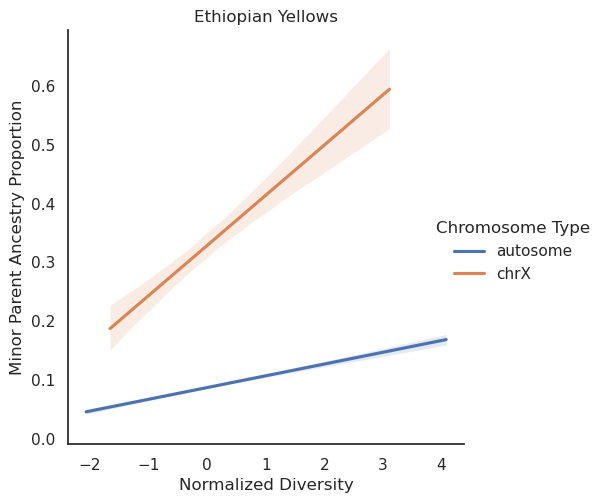

In [154]:
g = lmplot(autosome_chrX_norm.loc[autosome_chrX_norm.Origin.isin(gog)], x="norm_diversity", y="minor_parent_percentage",
                            scatter=False, hue="chrom_type", n_boot=1000) #Additional bootstraps makes it take long
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Normalized Diversity", title="Ethiopian Yellows")
g.set(ylim=(-0.01, None))
g._legend.set(title="Chromosome Type")
#g.set(xticks=[0, 0.0005, 0.001, 0.0015])

In [155]:
o_l, slope_l, pval_slope_l, slope_multi, stderr_slope_l = [], [], [], [], []
for o in result_order:
    o_div = autosome_chrX_norm.loc[autosome_chrX_norm.Origin == o]
    glm_results = smf.glm(formula = "minor_parent_percentage ~ norm_diversity * chrom_type", data=o_div,
                         var_weights=np.asarray(o_div["diversity"])).fit()
    print(o, glm_results.summary())
    o_l.append(o), slope_l.append(glm_results.params[3])
    pval_slope_l.append(glm_results.pvalues[3]), stderr_slope_l.append(glm_results.bse[3])
    slope_multi.append(glm_results.params[3]/glm_results.params[2])

Selous, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                26257
Model:                                 GLM   Df Residuals:                    26253
Model Family:                     Gaussian   Df Model:                            3
Link Function:                    Identity   Scale:                      1.3830e-06
Method:                               IRLS   Log-Likelihood:                 54892.
Date:                     Wed, 08 Jul 2026   Deviance:                     0.036309
Time:                             12:02:04   Pearson chi2:                   0.0363
No. Iterations:                          3   Pseudo R-squ. (CS):            0.02037
Covariance Type:                 nonrobust                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------

Ngorongoro, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                26257
Model:                                 GLM   Df Residuals:                    26253
Model Family:                     Gaussian   Df Model:                            3
Link Function:                    Identity   Scale:                      1.6171e-05
Method:                               IRLS   Log-Likelihood:                 22610.
Date:                     Wed, 08 Jul 2026   Deviance:                      0.42454
Time:                             12:02:05   Pearson chi2:                    0.425
No. Iterations:                          3   Pseudo R-squ. (CS):           0.002816
Covariance Type:                 nonrobust                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------

In [156]:
o_l, slope_l, pval_slope_l, slope_multi, stderr_slope_l = [], [], [], [], []
for o in range(1):
    o_div = autosome_chrX_norm.loc[autosome_chrX_norm.Origin.isin(["Mahale, Tanzania", "Katavi, Tanzania"])]
    glm_results = smf.glm(formula = "minor_parent_percentage ~ norm_diversity * chrom_type", data=o_div,
                         var_weights=np.asarray(o_div["diversity"])).fit()
    print(o, glm_results.summary())

0                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                52514
Model:                                 GLM   Df Residuals:                    52510
Model Family:                     Gaussian   Df Model:                            3
Link Function:                    Identity   Scale:                      2.5648e-05
Method:                               IRLS   Log-Likelihood:                 33106.
Date:                     Wed, 08 Jul 2026   Deviance:                       1.3468
Time:                             12:02:05   Pearson chi2:                     1.35
No. Iterations:                          3   Pseudo R-squ. (CS):           0.003515
Covariance Type:                 nonrobust                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------

[None]

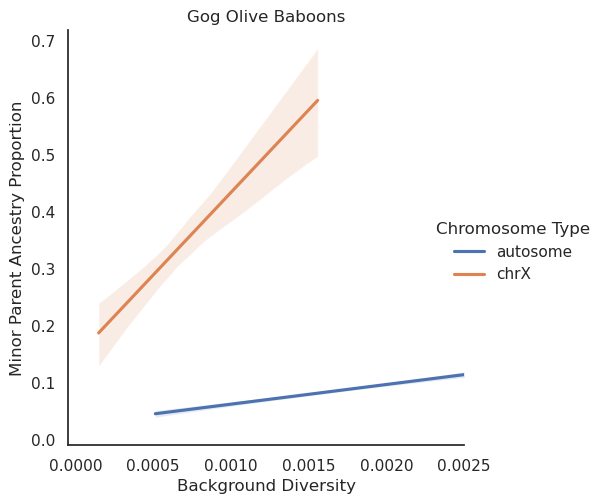

In [157]:
g = lmplot(autosome_chrX_norm.loc[autosome_chrX_norm.Origin.isin(gog)], x="diversity", y="minor_parent_percentage",
                            scatter=False, hue="chrom_type", n_boot=1000, ci=99.5) #Additional bootstraps makes it take long
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Background Diversity", title="Gog Olive Baboons")
g.set(ylim=(-0.01, None), xlim=(None, 0.0025))
g._legend.set(title="Chromosome Type")

[None, None]

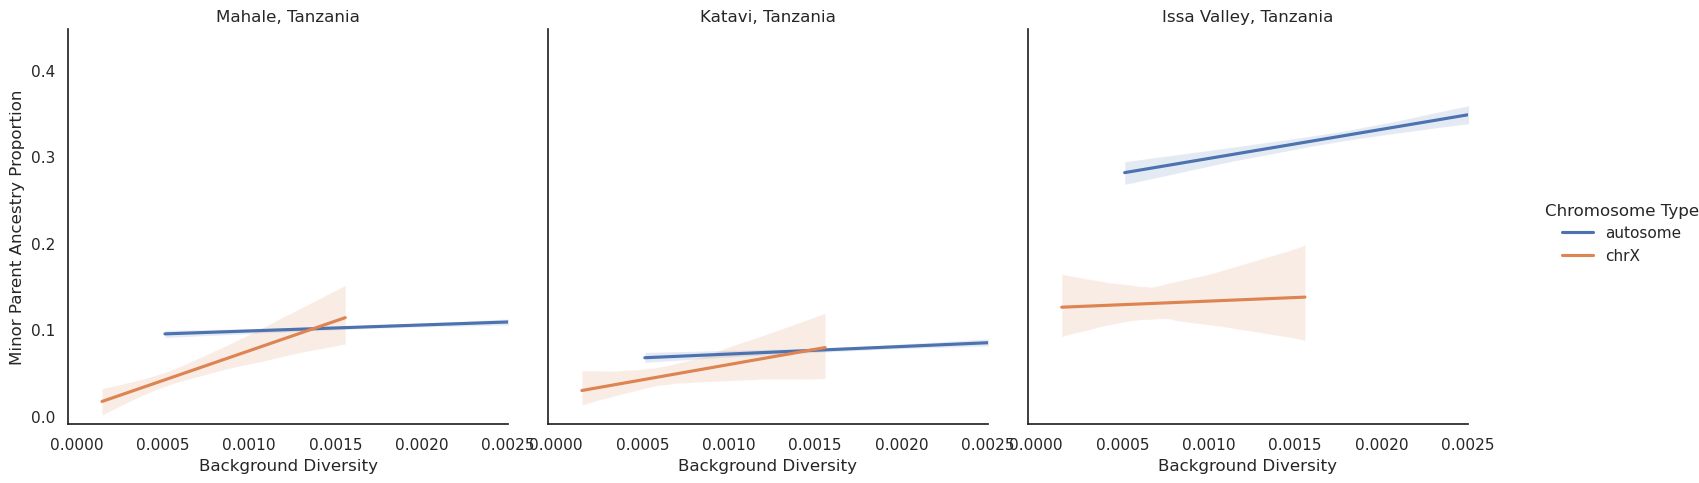

In [158]:
selected_pops = ["Mahale, Tanzania","Katavi, Tanzania","Issa Valley, Tanzania"]
g = lmplot(autosome_chrX_norm.loc[autosome_chrX_norm.Origin.isin(selected_pops)],
           x="diversity", y="minor_parent_percentage",
            scatter=False, hue="chrom_type", n_boot=1000, col="Origin", col_wrap=3,
          col_order=selected_pops, ci=99.5) #Additional bootstraps makes it take long
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Background Diversity")
g.set(ylim=(-0.01, None), xlim=(None, 0.0025))
g.set_titles(col_template="{col_name}")
g._legend.set(title="Chromosome Type", bbox_to_anchor=(1.05, 0.5))

[None]

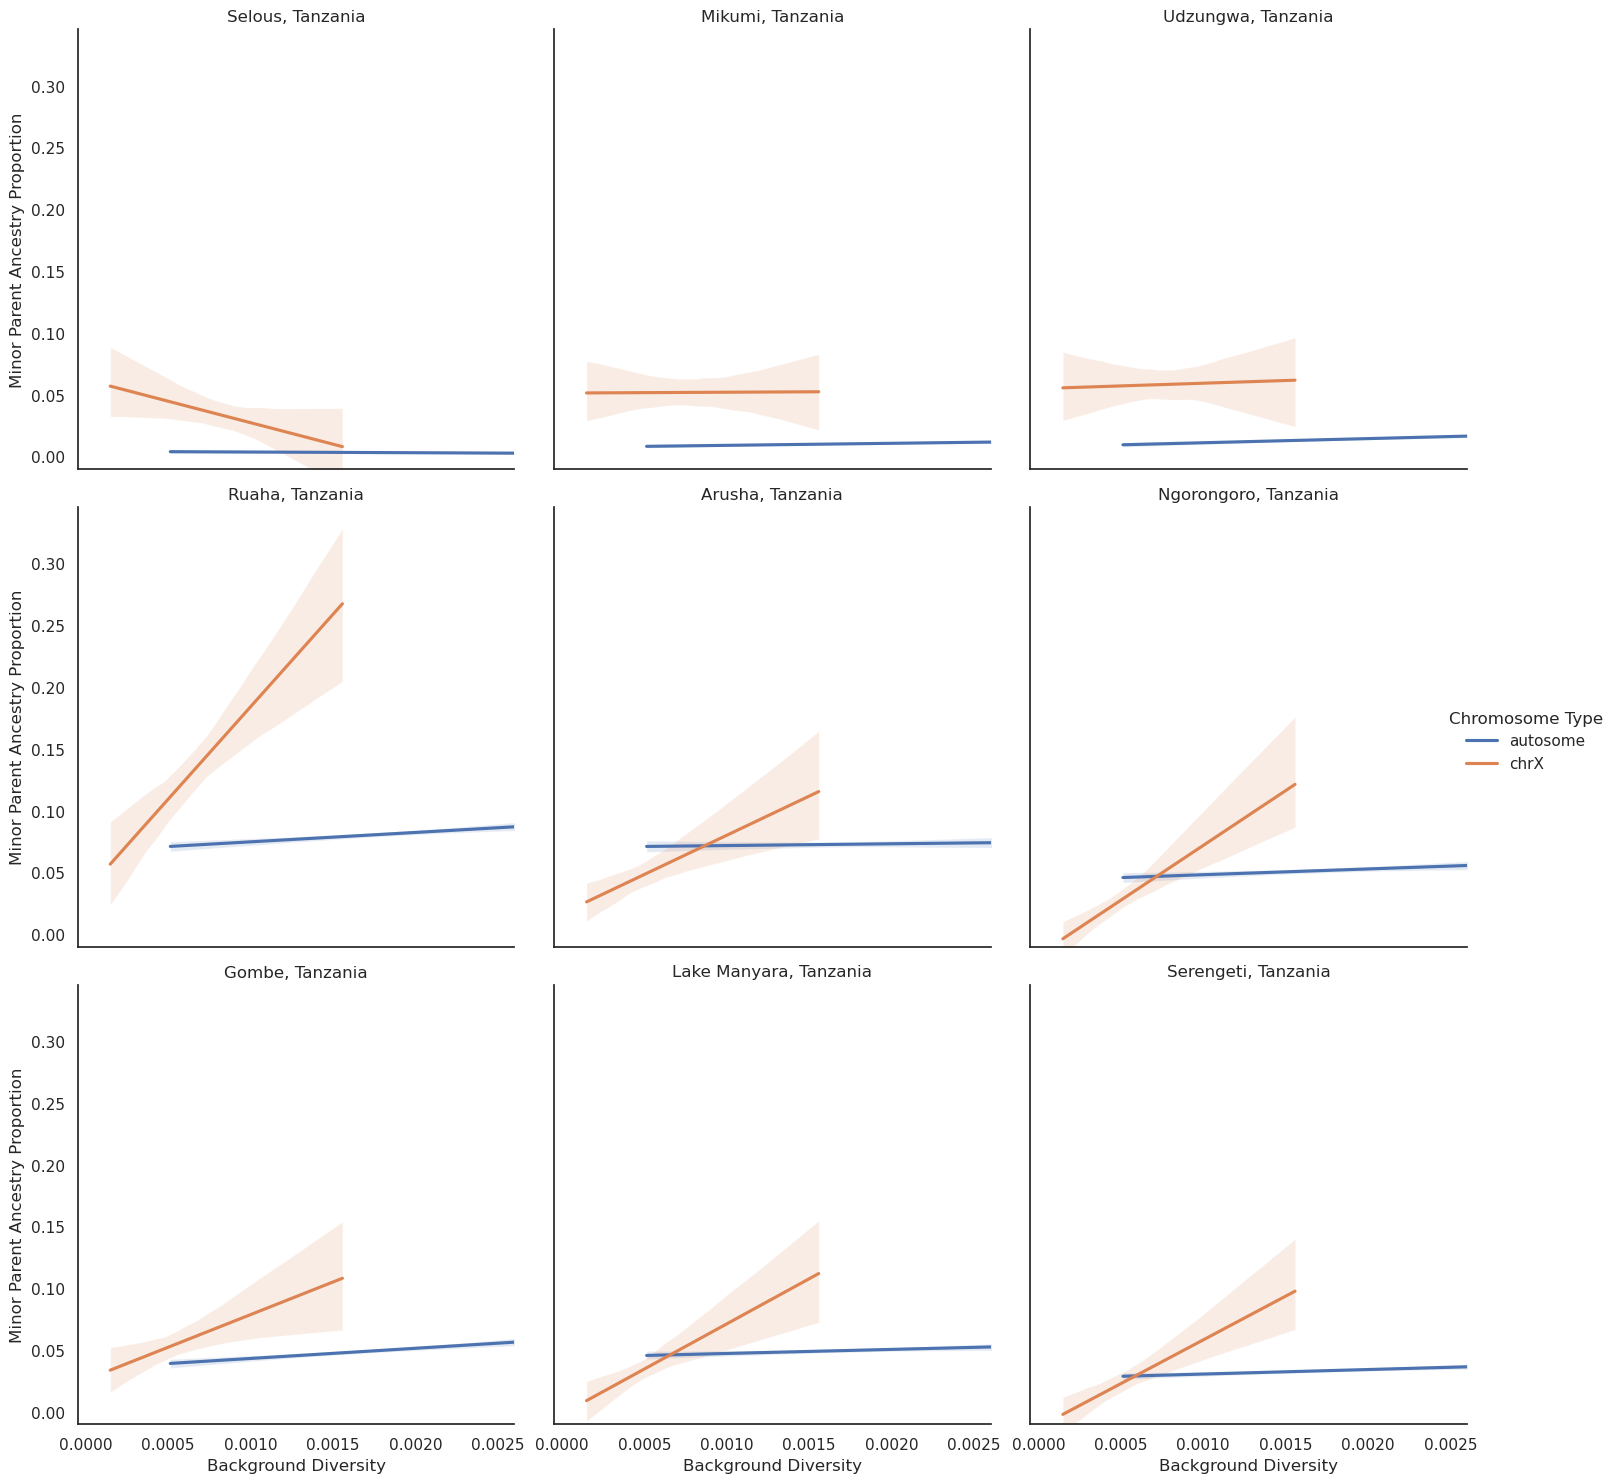

In [159]:
g = lmplot(autosome_chrX_norm.loc[autosome_chrX_norm.Origin.isin(result_order_no_gog)], x="diversity", y="minor_parent_percentage",
                            scatter=False, hue="chrom_type", n_boot=1000, col="Origin", col_wrap=3, col_order=result_order_no_gog, ci=99.5) #Additional bootstraps makes it take long
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Background Diversity")
g.set(ylim=(-0.01, None), xlim=(None, 0.0026))
g.set_titles(col_template="{col_name}")
g._legend.set(title="Chromosome Type")

In [160]:
glm_diversity_df = pd.DataFrame({"Origin": o_l, "Interaction Slope": slope_l, "Relative Increase": slope_multi, "Slope P-value": pval_slope_l,
                               "Slope stderr": stderr_slope_l})
glm_diversity_df

,Origin,Interaction Slope,Relative Increase,Slope P-value,Slope stderr


Removing high freq regions.

In [161]:
o_l, slope_l, pval_slope_l, slope_multi, stderr_slope_l, div_l, pdiv_l = [], [], [], [], [], [], []
for o in result_order:
    o_div = autosome_chrX_norm.loc[(autosome_chrX_norm.Origin == o) & (autosome_chrX_norm.minor_parent_percentage <= 0.25)]
    glm_results = smf.glm(formula = "minor_parent_percentage ~ norm_diversity * chrom_type", data=o_div,
                         var_weights=np.asarray(o_div["diversity"])).fit()
    print(o, glm_results.summary())
    o_l.append(o), slope_l.append(glm_results.params[3])
    pval_slope_l.append(glm_results.pvalues[3])
    slope_multi.append(glm_results.params[3]/glm_results.params[2])
    div_l.append(glm_results.params[2]), pdiv_l.append(glm_results.pvalues[2])

Selous, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                26151
Model:                                 GLM   Df Residuals:                    26147
Model Family:                     Gaussian   Df Model:                            3
Link Function:                    Identity   Scale:                      6.1354e-07
Method:                               IRLS   Log-Likelihood:                 65337.
Date:                     Wed, 08 Jul 2026   Deviance:                     0.016042
Time:                             12:02:16   Pearson chi2:                   0.0160
No. Iterations:                          3   Pseudo R-squ. (CS):           0.001387
Covariance Type:                 nonrobust                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------

Ngorongoro, Tanzania                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25036
Model:                                 GLM   Df Residuals:                    25032
Model Family:                     Gaussian   Df Model:                            3
Link Function:                    Identity   Scale:                      6.3320e-06
Method:                               IRLS   Log-Likelihood:                 33263.
Date:                     Wed, 08 Jul 2026   Deviance:                      0.15850
Time:                             12:02:17   Pearson chi2:                    0.159
No. Iterations:                          3   Pseudo R-squ. (CS):           0.001815
Covariance Type:                 nonrobust                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------

In [162]:
glm_diversity_df = pd.DataFrame({"Origin": o_l, "Autosome Slope": div_l, "Interaction Slope": slope_l,
                                 "Relative Increase": slope_multi, "Autosome P-value": pdiv_l,
                                 "Interaction Slope P-value": pval_slope_l
                               })
glm_diversity_df

,Origin,Autosome Slope,Interaction Slope,Relative Increase,Autosome P-value,Interaction Slope P-value
0,"Selous, Tanzania",0.000148,0.0017,11.5,0.199,0.0769
1,"Mikumi, Tanzania",0.00143,0.00887,6.19,1.43e-25,7.41e-15
2,"Udzungwa, Tanzania",0.00214,0.00794,3.71,2.59e-22,1.96e-05
3,"Ruaha, Tanzania",0.00287,0.0173,6.04,2e-10,2.38e-05
4,"Tarangire, Tanzania",-0.00115,0.00222,-1.92,0.052,0.654
5,"Arusha, Tanzania",0.000176,0.00121,6.92,0.711,0.75
6,"Ngorongoro, Tanzania",0.00175,0.0025,1.43,4.37e-06,0.43
7,"Gombe, Tanzania",0.00331,0.00243,0.734,4.59e-21,0.401
8,"Lake Manyara, Tanzania",0.00123,0.0102,8.25,0.000281,0.000251
9,"Serengeti, Tanzania",0.00175,0.0069,3.95,1.22e-09,0.00386


[None]

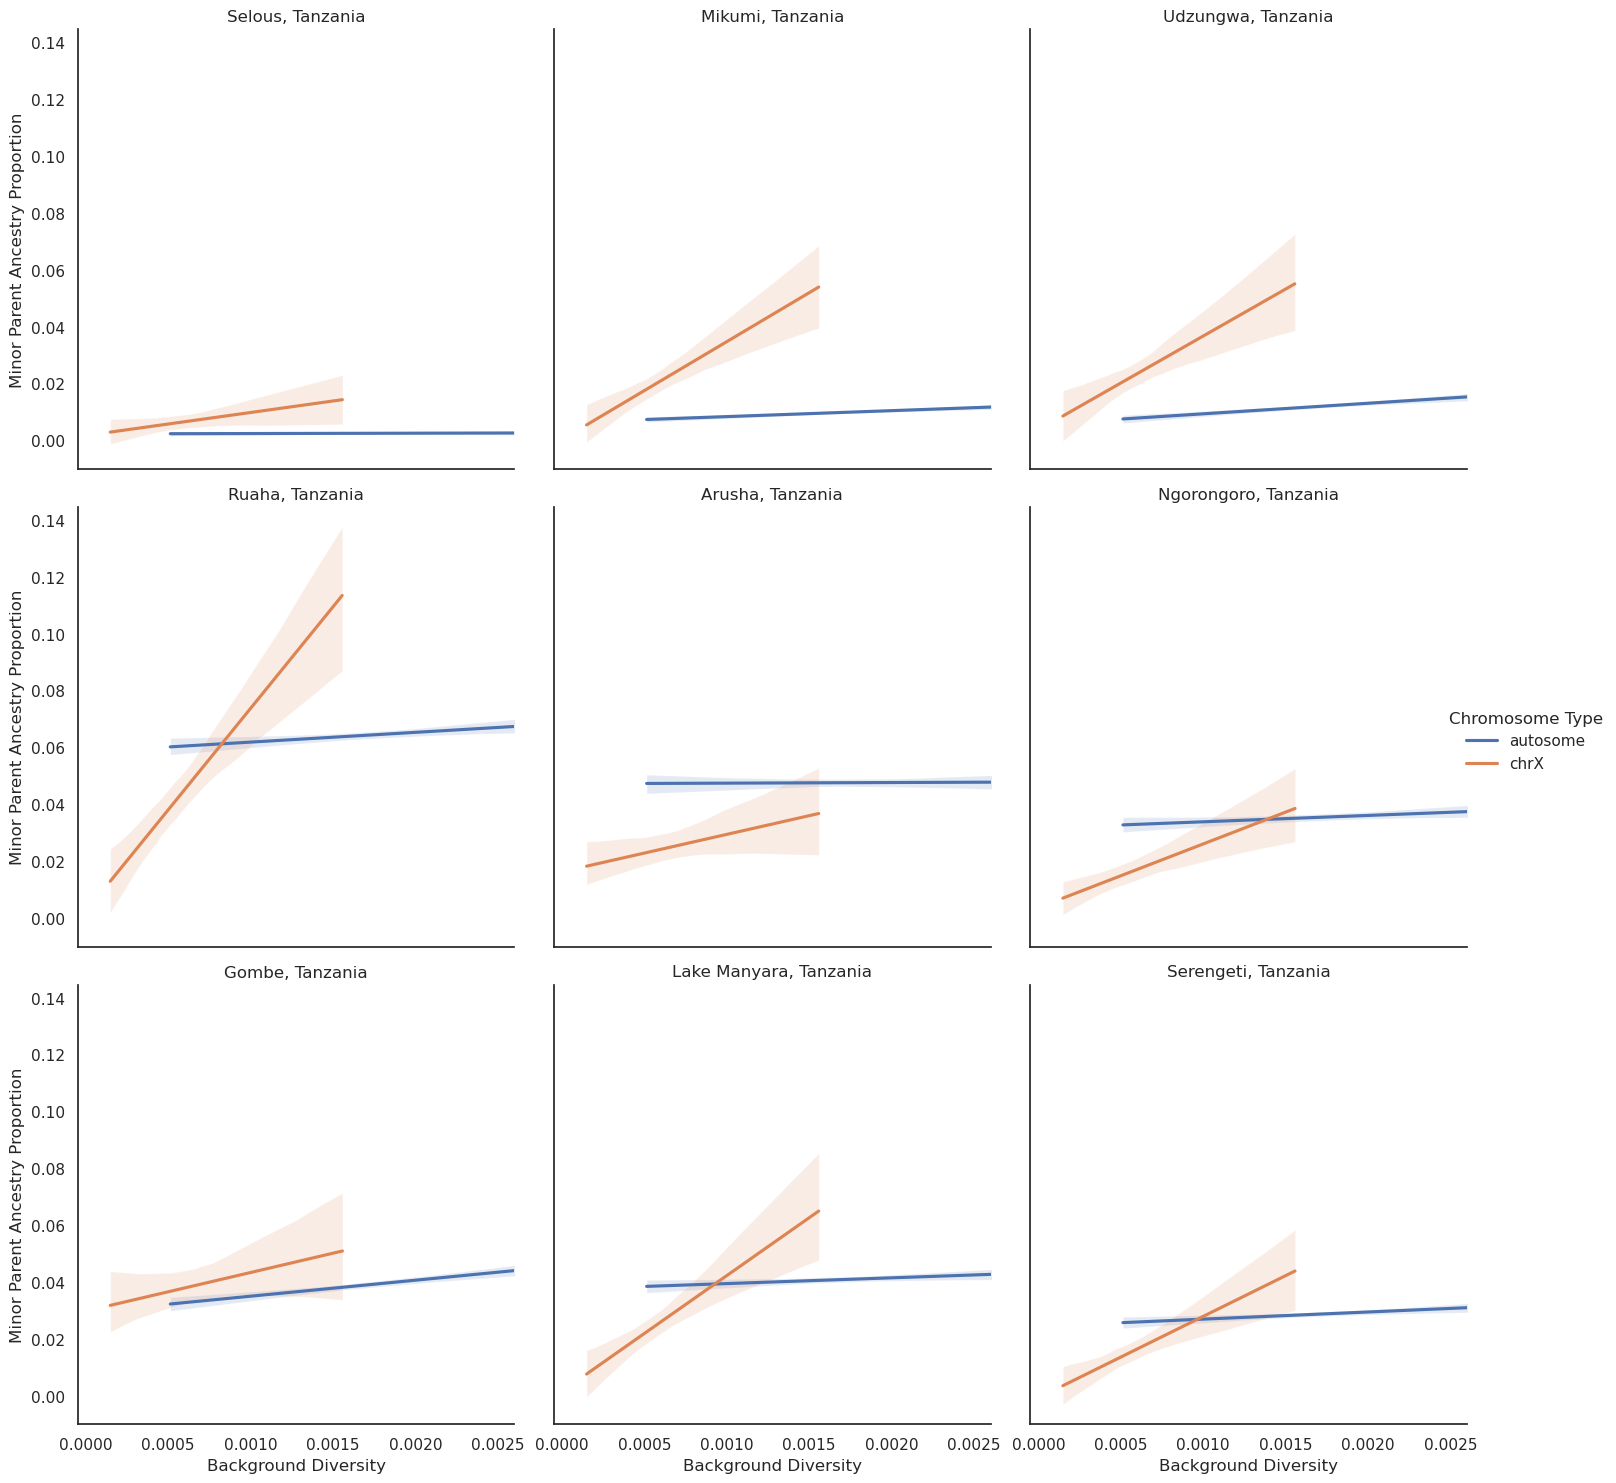

In [163]:
g = lmplot(autosome_chrX_norm.loc[autosome_chrX_norm.Origin.isin(result_order_no_gog) &
                                  (autosome_chrX_norm.minor_parent_percentage <= 0.25)], x="diversity", y="minor_parent_percentage",
                            scatter=False, hue="chrom_type", n_boot=1000, col="Origin", col_wrap=3, col_order=result_order_no_gog, ci=99.5) #Additional bootstraps makes it take long
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Background Diversity")
g.set(ylim=(-0.01, None), xlim=(None, 0.0026))
g.set_titles(col_template="{col_name}")
g._legend.set(title="Chromosome Type")

Quantiles of Admixture/Diversity

/tmp/47761274/ipykernel_4122384/3063631219.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter_qcut_chrX["ancestry"] = ["Pure Major" if x <= 0.1 else "Pure Minor" if x >= 0.9


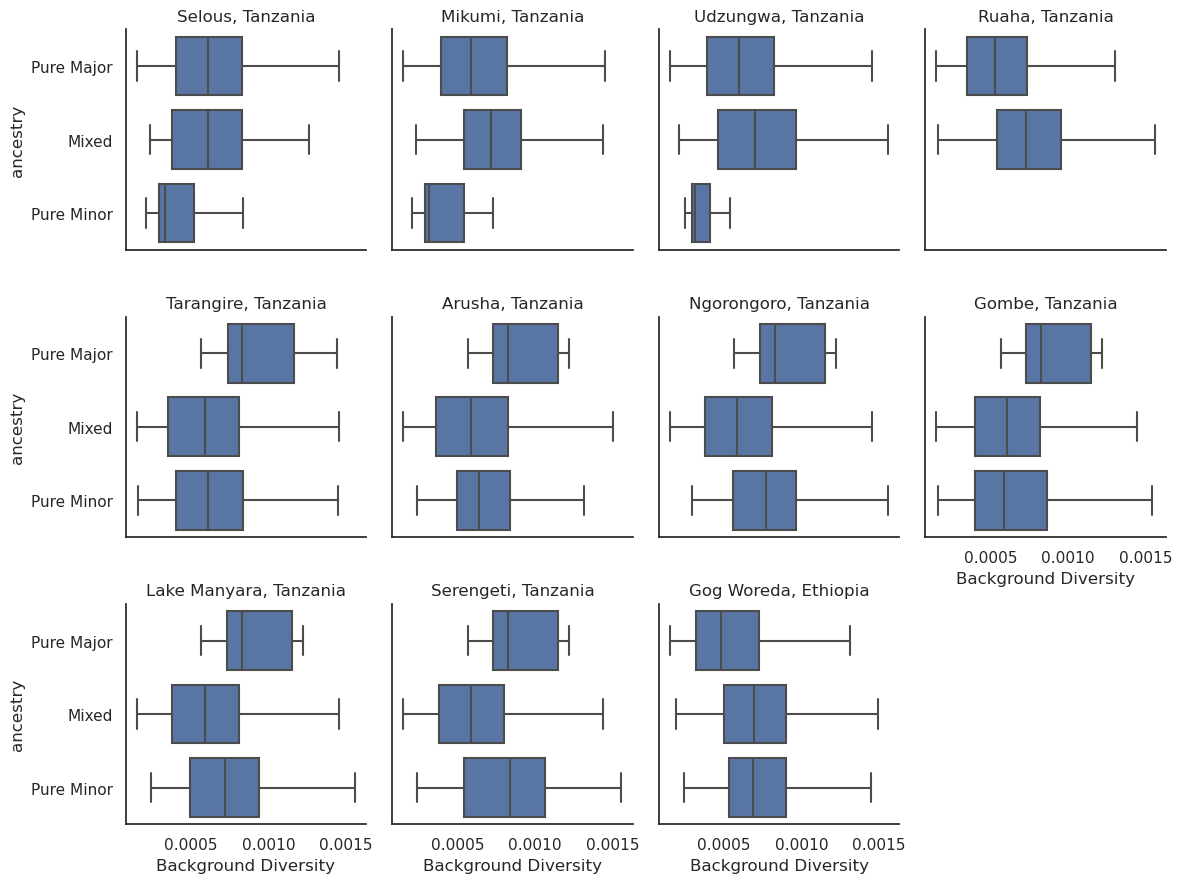

In [164]:
filter_qcut_chrX["ancestry"] = ["Pure Major" if x <= 0.1 else "Pure Minor" if x >= 0.9
                        else "Mixed" for x in filter_qcut_chrX["minor_parent_percentage"]]
g = sns.FacetGrid(filter_qcut_chrX.loc[filter_qcut_chrX.Origin.isin(result_order)], col="Origin",
                  col_wrap = 4, col_order=result_order)
g.map_dataframe(sns.boxplot, x="diversity", y="ancestry", fliersize=0)
g.set_titles(col_template="{col_name}")
g.set(xlabel="Background Diversity")

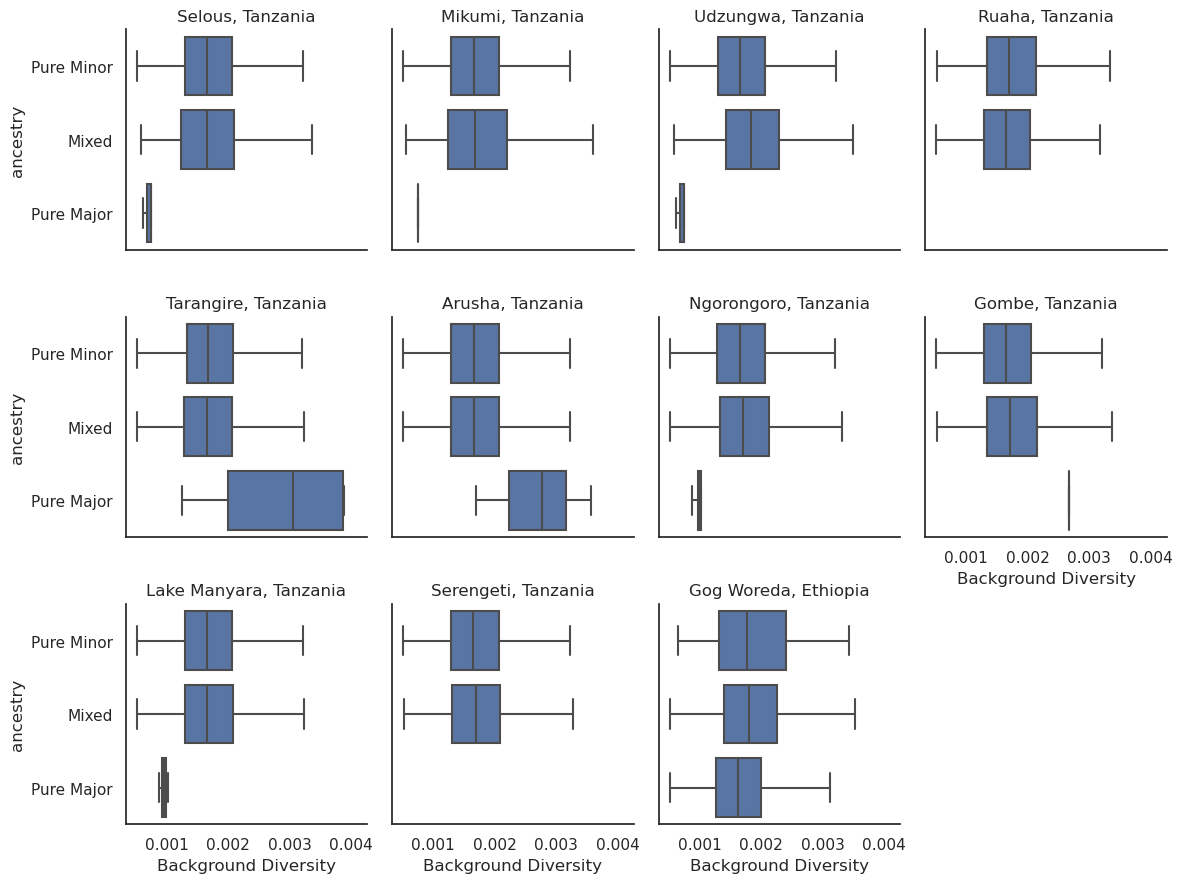

In [165]:
filter_qcut["ancestry"] = ["Pure Major" if x <= 0.1 else "Pure Minor" if x >= 0.9
                        else "Mixed" for x in filter_qcut["minor_parent_percentage"]]
g = sns.FacetGrid(filter_qcut.loc[filter_qcut.Origin.isin(result_order)], col="Origin",
                  col_wrap = 4, col_order=result_order)
g.map_dataframe(sns.boxplot, x="diversity", y="ancestry", fliersize=0)
g.set_titles(col_template="{col_name}")
g.set(xlabel="Background Diversity")

In [166]:
hama_df = filter_qcut.loc[(filter_qcut.Origin == "Gog Woreda, Ethiopia")][["chrom", "start", "ancestry"]]
hama_df_add = filter_qcut.merge(hama_df, on=["chrom", "start"])
hama_df_chrX = filter_qcut_chrX.loc[(filter_qcut_chrX.Origin == "Gog Woreda, Ethiopia")][["chrom", "start", "ancestry"]]
hama_df_add_chrX = filter_qcut_chrX.merge(hama_df_chrX, on=["chrom", "start"])

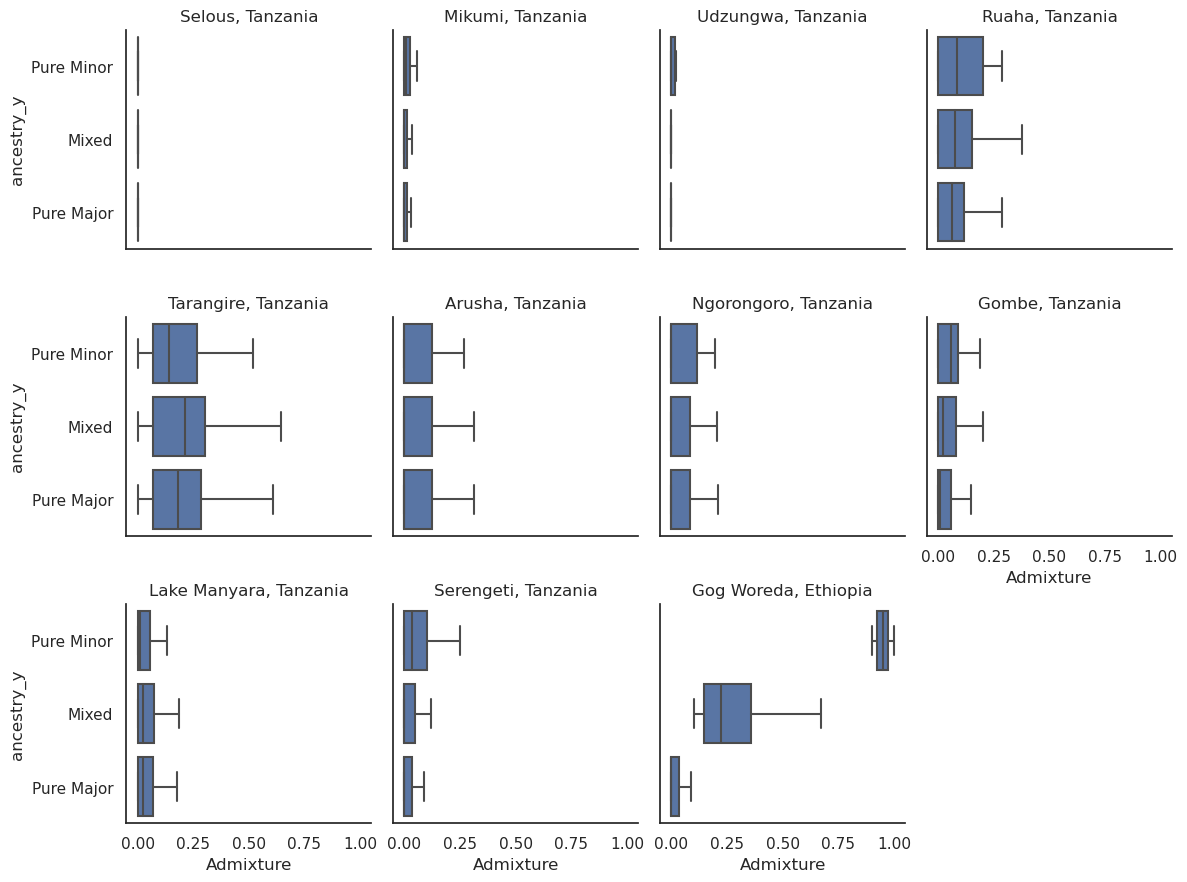

In [167]:
g = sns.FacetGrid(hama_df_add.loc[hama_df_add.Origin.isin(result_order)], col="Origin",
                  col_wrap = 4, col_order=result_order)
g.map_dataframe(sns.boxplot, x="minor_parent_percentage", y="ancestry_y", fliersize=0)
g.set_titles(col_template="{col_name}")
g.set(xlabel="Admixture")

In [168]:
for o in result_order:
    o_df = hama_df_add.loc[hama_df_add.Origin == o]
    print(o, o_df.groupby(["ancestry_y"])["minor_parent_percentage"].mean(),
         o_df.value_counts(["ancestry_y"]))
    print(mannwhitneyu(o_df.loc[o_df.ancestry_y == "Pure Minor"].minor_parent_percentage,
                   o_df.loc[o_df.ancestry_y == "Mixed"].minor_parent_percentage))

Selous, Tanzania ancestry_y
Mixed           0.00274
Pure Major      0.00314
Pure Minor       0.0288
Name: minor_parent_percentage, dtype: float64 ancestry_y
Pure Major    18927
Mixed          6412
Pure Minor       58
Name: count, dtype: int64
MannwhitneyuResult(statistic=198140.0, pvalue=0.0007232869510685112)
Mikumi, Tanzania ancestry_y
Mixed            0.0121
Pure Major      0.00934
Pure Minor         0.04
Name: minor_parent_percentage, dtype: float64 ancestry_y
Pure Major    18927
Mixed          6412
Pure Minor       58
Name: count, dtype: int64
MannwhitneyuResult(statistic=216121.5, pvalue=0.01676841942240746)
Udzungwa, Tanzania ancestry_y
Mixed            0.0144
Pure Major        0.013
Pure Minor       0.0428
Name: minor_parent_percentage, dtype: float64 ancestry_y
Pure Major    18927
Mixed          6412
Pure Minor       58
Name: count, dtype: int64
MannwhitneyuResult(statistic=207555.0, pvalue=0.014083313643888418)
Ruaha, Tanzania ancestry_y
Mixed            0.0885
Pure Major    

In [169]:
for o in result_order:
    o_df = hama_df_add_chrX.loc[hama_df_add_chrX.Origin == o]
    print(o, o_df.groupby(["ancestry_y"])["minor_parent_percentage"].mean(),
         o_df.value_counts(["ancestry_y"]))
    print(mannwhitneyu(o_df.loc[o_df.ancestry_y == "Pure Minor"].minor_parent_percentage,
                   o_df.loc[o_df.ancestry_y == "Mixed"].minor_parent_percentage))

Selous, Tanzania ancestry_y
Mixed            0.0432
Pure Major       0.0412
Pure Minor       0.0153
Name: minor_parent_percentage, dtype: float64 ancestry_y
Mixed         488
Pure Major    464
Pure Minor    111
Name: count, dtype: int64
MannwhitneyuResult(statistic=24550.0, pvalue=0.010375169578285156)
Mikumi, Tanzania ancestry_y
Mixed            0.0653
Pure Major       0.0424
Pure Minor       0.0295
Name: minor_parent_percentage, dtype: float64 ancestry_y
Mixed         488
Pure Major    464
Pure Minor    111
Name: count, dtype: int64
MannwhitneyuResult(statistic=24277.0, pvalue=0.06877729224937655)
Udzungwa, Tanzania ancestry_y
Mixed            0.0693
Pure Major       0.0494
Pure Minor       0.0392
Name: minor_parent_percentage, dtype: float64 ancestry_y
Mixed         488
Pure Major    464
Pure Minor    111
Name: count, dtype: int64
MannwhitneyuResult(statistic=22759.0, pvalue=0.0023240813010451705)
Ruaha, Tanzania ancestry_y
Mixed             0.172
Pure Major       0.0843
Pure Minor 

Merged quintiles

/tmp/47761274/ipykernel_4122384/2948258745.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter_qcut_chrX["Diversity Quintile"] = pd.qcut(filter_qcut_chrX.diversity, 5,
/tmp/47761274/ipykernel_4122384/2948258745.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter_qcut_chrX["Chromosome Type"] = "chrX"


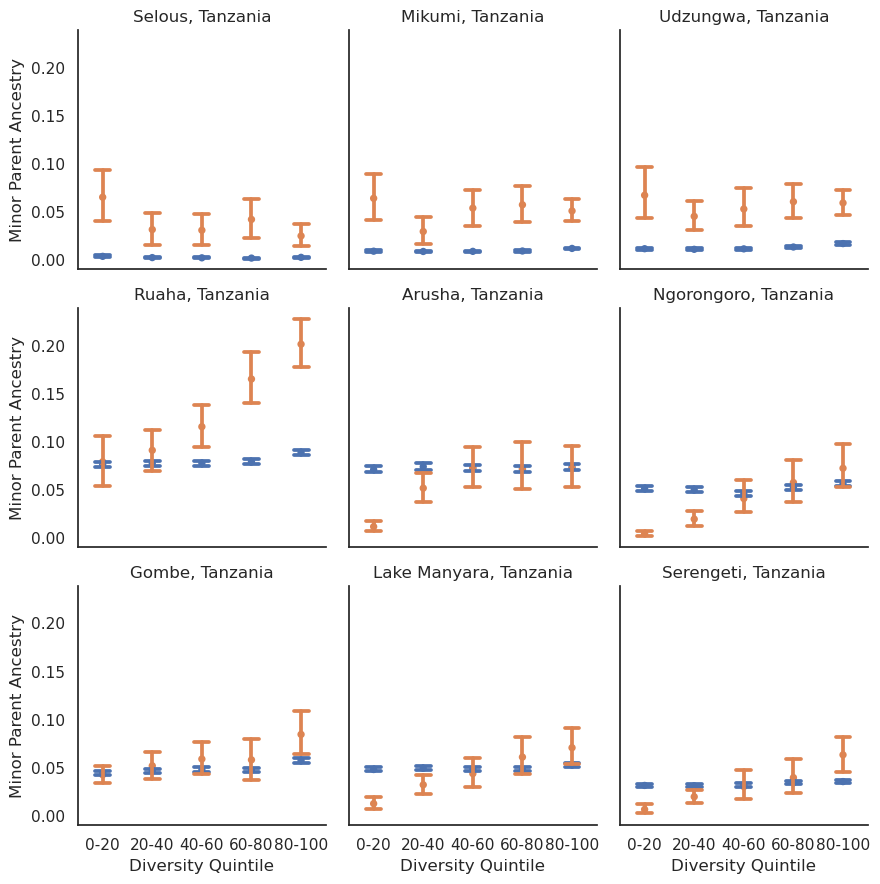

In [170]:
filter_qcut_chrX["Diversity Quintile"] = pd.qcut(filter_qcut_chrX.diversity, 5,
                                                       labels=["0-20","20-40",
                                                              "40-60","60-80",
                                                              "80-100"])
filter_qcut_chrX["Chromosome Type"] = "chrX"

filter_qcut["Diversity Quintile"] = pd.qcut(filter_qcut.diversity, 5,
                                                       labels=["0-20","20-40",
                                                              "40-60","60-80",
                                                              "80-100"])
filter_qcut["Chromosome Type"] = "autosome"
filter_qcut_both = pd.concat([filter_qcut, filter_qcut_chrX])
g = sns.FacetGrid(filter_qcut_both.loc[filter_qcut_both.Origin.isin(result_order_no_gog)], col="Origin",
                  col_wrap = 3, col_order=result_order_no_gog, hue="Chromosome Type")
g.map_dataframe(sns.pointplot, y="minor_parent_percentage", x="Diversity Quantile", 
                linestyles="none", capsize=.3, errorbar=("ci", 95), scale = 0.6)
#g.map_dataframe(sns.stripplot, x="minor_parent_percentage", y="Diversity Quantile", alpha=0.05)
#g.set(xlim=(0, 0.25))
g.set_titles(col_template="{col_name}")
g.set(xlabel="Diversity Quintile", ylabel="Minor Parent Ancestry")

/tmp/47761274/ipykernel_4122384/3327868747.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter_qcut_chrX["Diversity Quintile"] = pd.qcut(filter_qcut_chrX.diversity, 5,
/tmp/47761274/ipykernel_4122384/3327868747.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filter_qcut_chrX["Chromosome Type"] = "chrX"


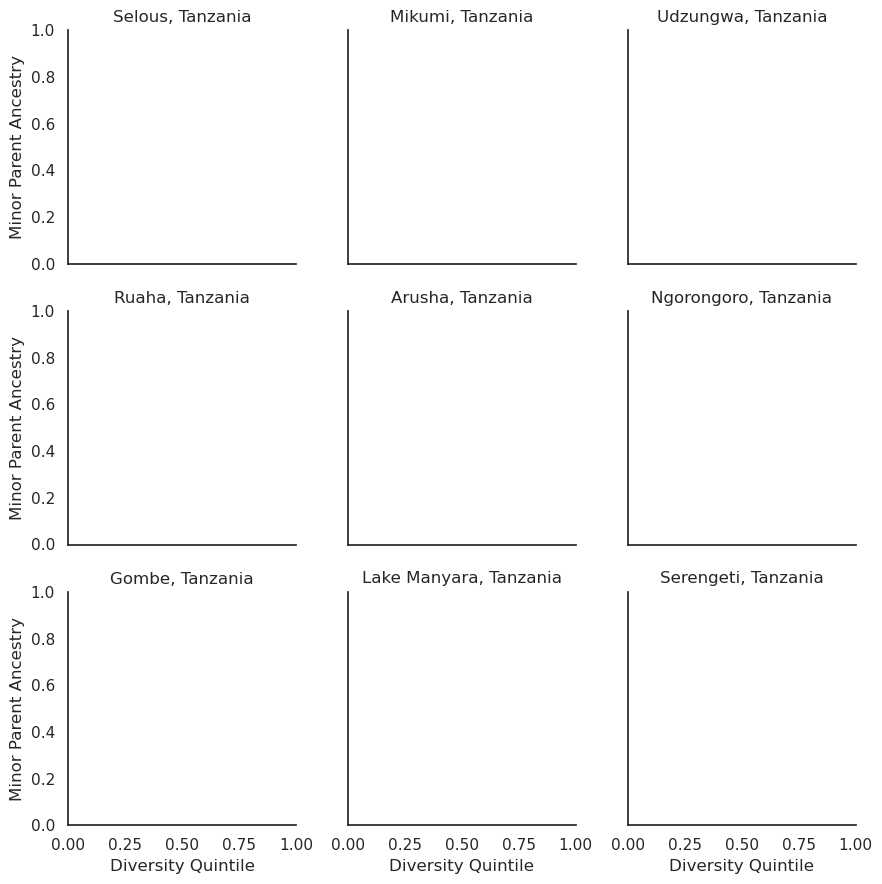

In [171]:
filter_qcut_chrX["Diversity Quintile"] = pd.qcut(filter_qcut_chrX.diversity, 5,
                                                       labels=["0-20","20-40",
                                                              "40-60","60-80",
                                                              "80-100"])
filter_qcut_chrX["Chromosome Type"] = "chrX"

filter_qcut["Diversity Quintile"] = pd.qcut(filter_qcut.diversity, 5,
                                                       labels=["0-20","20-40",
                                                              "40-60","60-80",
                                                              "80-100"])
filter_qcut["Chromosome Type"] = "autosome"
filter_qcut_both = pd.concat([filter_qcut, filter_qcut_chrX])
g = sns.FacetGrid(filter_qcut_both.loc[filter_qcut_both.Origin.isin(["Mahale, Tanzania", "Katavi, Tanzania",
                                                                     "Issa Valley, Tanzania"])], col="Origin",
                  col_wrap = 3, col_order=result_order_no_gog, hue="Chromosome Type")
g.map_dataframe(sns.pointplot, y="minor_parent_percentage", x="Diversity Quantile", 
                linestyles="none", capsize=.3, errorbar=("ci", 95), scale = 0.6)
#g.map_dataframe(sns.stripplot, x="minor_parent_percentage", y="Diversity Quantile", alpha=0.05)
#g.set(xlim=(0, 0.25))
g.set_titles(col_template="{col_name}")
g.set(xlabel="Diversity Quintile", ylabel="Minor Parent Ancestry")

In [172]:
mean_window_df_tanz_eth = window_df_tanz_eth.groupby(["chrom", "Origin", "individual", "start", "end"])[["north_sum"]].mean().reset_index()
mean_window_df_tanz = window_df_tanz.groupby(["chrom", "Origin", "individual", "start", "end"])[["north_sum"]].mean().reset_index()
admix_div_mean_ind = mean_diversity.merge(mean_window_df_tanz_eth, on=["chrom", "start"])
admix_div_mean_ind["Species"] = admix_div_mean_ind.Origin.map(dict(zip(meta_data_samples_sci.Origin, meta_data_samples_sci.Species)))
admix_div_mean_ind = admix_div_mean_ind.merge(c_r_g_df, on=["chrom", "start"])
admix_div_mean_ind["North Percentage"] = admix_div_mean_ind.north_sum/100000

In [173]:
admix_div_mean_ind = admix_div_mean_ind.loc[admix_div_mean_ind.Origin.isin(origins_interest)]
admix_div_mean_ind["minor_parent_percentage"] = [x if y == ("cynocephalus") or z == "Gog Woreda, Gambella region, Ethiopia_eth_case"
                                             else 1-x for x, y, z in zip(admix_div_mean_ind["North Percentage"],
                                                                         admix_div_mean_ind["Species"],
                                                                        admix_div_mean_ind["Origin"])]
admix_div_mean_ind["local_minor_ancestry"] = [min(x, 1-x) for x in admix_div_mean_ind["North Percentage"]]

In [174]:
filter_callable_ind = admix_div_mean_ind.loc[admix_div_mean_ind.callable_frac > 0.75]
filter_qcut_ind = filter_callable_ind.loc[(filter_callable_ind.diversity >= 0.000513) &
                                 (filter_callable_ind.diversity <= 0.00408)]

In [175]:
o_l, id_l, slope_l, intercept_l, pval_slope_l, pval_intercept_l, stderr_slope_l, stderr_intercept_l = [], [], [], [], [], [], [], []
for o in result_order:
    o_div = filter_qcut_ind.loc[(filter_qcut_ind.Origin == o)]
    for i in o_div.individual.unique():
        i_df = o_div.loc[o_div.individual == i]
        glm_results = smf.glm(formula = "minor_parent_percentage ~ diversity", data=i_df,
                         var_weights=np.asarray(i_df["diversity"])).fit()
        print(o, i, glm_results.summary())
        o_l.append(o), id_l.append(i)
        slope_l.append(glm_results.params[1]), intercept_l.append(glm_results.params[0])
        pval_slope_l.append(glm_results.pvalues[1]), pval_intercept_l.append(glm_results.pvalues[0])
        stderr_slope_l.append(glm_results.bse[1]), stderr_intercept_l.append(glm_results.bse[0])

Selous, Tanzania PD_0235                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25406
Model:                                 GLM   Df Residuals:                    25404
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      9.6179e-07
Method:                               IRLS   Log-Likelihood:                 58247.
Date:                     Wed, 08 Jul 2026   Deviance:                     0.024433
Time:                             12:02:45   Pearson chi2:                   0.0244
No. Iterations:                          3   Pseudo R-squ. (CS):          4.628e-06
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------

Mikumi, Tanzania PD_0272                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25406
Model:                                 GLM   Df Residuals:                    25404
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      5.7597e-06
Method:                               IRLS   Log-Likelihood:                 35511.
Date:                     Wed, 08 Jul 2026   Deviance:                      0.14632
Time:                             12:02:46   Pearson chi2:                    0.146
No. Iterations:                          3   Pseudo R-squ. (CS):           0.001569
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------

Mikumi, Tanzania PD_0746                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25406
Model:                                 GLM   Df Residuals:                    25404
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      7.0898e-06
Method:                               IRLS   Log-Likelihood:                 32872.
Date:                     Wed, 08 Jul 2026   Deviance:                      0.18011
Time:                             12:02:46   Pearson chi2:                    0.180
No. Iterations:                          3   Pseudo R-squ. (CS):           0.003910
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------

Mikumi, Tanzania PD_0757                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25406
Model:                                 GLM   Df Residuals:                    25404
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      8.2897e-06
Method:                               IRLS   Log-Likelihood:                 30886.
Date:                     Wed, 08 Jul 2026   Deviance:                      0.21059
Time:                             12:02:47   Pearson chi2:                    0.211
No. Iterations:                          3   Pseudo R-squ. (CS):          0.0008739
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------

Mikumi, Tanzania PD_0768                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25406
Model:                                 GLM   Df Residuals:                    25404
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      7.6112e-06
Method:                               IRLS   Log-Likelihood:                 31970.
Date:                     Wed, 08 Jul 2026   Deviance:                      0.19336
Time:                             12:02:47   Pearson chi2:                    0.193
No. Iterations:                          3   Pseudo R-squ. (CS):          1.762e-05
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------

...

Gombe, Tanzania PD_0509                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25406
Model:                                 GLM   Df Residuals:                    25404
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      3.9747e-05
Method:                               IRLS   Log-Likelihood:                 10973.
Date:                     Wed, 08 Jul 2026   Deviance:                       1.0097
Time:                             12:02:51   Pearson chi2:                     1.01
No. Iterations:                          3   Pseudo R-squ. (CS):           0.001483
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------

Lake Manyara, Tanzania PD_0238                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25406
Model:                                 GLM   Df Residuals:                    25404
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      4.1821e-05
Method:                               IRLS   Log-Likelihood:                 10327.
Date:                     Wed, 08 Jul 2026   Deviance:                       1.0624
Time:                             12:02:51   Pearson chi2:                     1.06
No. Iterations:                          3   Pseudo R-squ. (CS):          0.0001375
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------

Lake Manyara, Tanzania PD_0678                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25406
Model:                                 GLM   Df Residuals:                    25404
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      4.0664e-05
Method:                               IRLS   Log-Likelihood:                 10684.
Date:                     Wed, 08 Jul 2026   Deviance:                       1.0330
Time:                             12:02:52   Pearson chi2:                     1.03
No. Iterations:                          3   Pseudo R-squ. (CS):          0.0006777
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------

Serengeti, Tanzania PD_0199                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25406
Model:                                 GLM   Df Residuals:                    25404
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      2.6595e-05
Method:                               IRLS   Log-Likelihood:                 16077.
Date:                     Wed, 08 Jul 2026   Deviance:                      0.67563
Time:                             12:02:53   Pearson chi2:                    0.676
No. Iterations:                          3   Pseudo R-squ. (CS):          0.0002973
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------

Serengeti, Tanzania PD_0498                     Generalized Linear Model Regression Results                    
Dep. Variable:     minor_parent_percentage   No. Observations:                25406
Model:                                 GLM   Df Residuals:                    25404
Model Family:                     Gaussian   Df Model:                            1
Link Function:                    Identity   Scale:                      2.9924e-05
Method:                               IRLS   Log-Likelihood:                 14579.
Date:                     Wed, 08 Jul 2026   Deviance:                      0.76020
Time:                             12:02:53   Pearson chi2:                    0.760
No. Iterations:                          3   Pseudo R-squ. (CS):          0.0007043
Covariance Type:                 nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------

In [176]:
glm_diversity_df = pd.DataFrame({"Origin": o_l, "individual": id_l, "Intercept": intercept_l, "Slope": slope_l, 
                                 "Intercept P-value": pval_intercept_l, "Slope P-value": pval_slope_l,
                                "Intercept stderr": stderr_intercept_l, "Slope stderr": stderr_slope_l})
glm_diversity_df

,Origin,individual,Intercept,Slope,Intercept P-value,Slope P-value,Intercept stderr,Slope stderr
0,"Selous, Tanzania",PD_0235,0.00141,-0.0837,0.00409,0.732,0.00049,0.244
1,"Selous, Tanzania",PD_0236,0.00508,-1,1.12e-10,0.0107,0.000788,0.392
2,"Selous, Tanzania",PD_0237,0.0025,1.1,0.0103,0.0229,0.000974,0.485
3,"Mikumi, Tanzania",PD_0268,0.00405,4.58,0.0103,5.58e-09,0.00158,0.786
4,"Mikumi, Tanzania",PD_0269,0.0124,-0.858,7.36e-17,0.248,0.00149,0.742
...,...,...,...,...,...,...,...,...
114,"Serengeti, Tanzania",PD_0497,0.0303,2.15,9.09e-30,0.106,0.00267,1.33
115,"Serengeti, Tanzania",PD_0498,0.0258,5.76,4.1e-21,2.33e-05,0.00273,1.36
116,"Serengeti, Tanzania",PD_0499,0.026,4.98,1.65e-21,0.000253,0.00273,1.36
117,"Serengeti, Tanzania",PD_0500,0.023,7.52,4.13e-17,3.27e-08,0.00273,1.36


<Axes: xlabel='Slope', ylabel='Count'>

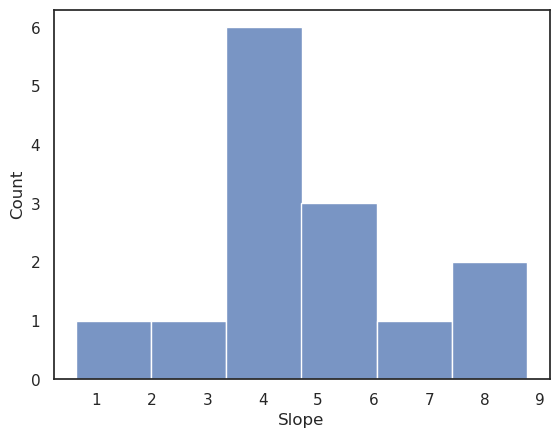

In [177]:
sns.histplot(data=glm_diversity_df.loc[glm_diversity_df.Origin == "Serengeti, Tanzania"], x="Slope")

In [178]:
glm_diversity_df.loc[glm_diversity_df.Origin == "Serengeti, Tanzania"]

,Origin,individual,Intercept,Slope,Intercept P-value,Slope P-value,Intercept stderr,Slope stderr
105,"Serengeti, Tanzania",PD_0199,0.0256,3.53,3.35e-23,0.00598,0.00258,1.28
106,"Serengeti, Tanzania",PD_0200,0.0237,6.16,5.97e-18,6.59e-06,0.00274,1.37
107,"Serengeti, Tanzania",PD_0201,0.0296,3.9,5.1e-26,0.00537,0.00281,1.4
108,"Serengeti, Tanzania",PD_0202,0.0228,3.85,1.81e-19,0.0022,0.00253,1.26
109,"Serengeti, Tanzania",PD_0203,0.0241,4.19,3.24e-21,0.000965,0.00255,1.27
110,"Serengeti, Tanzania",PD_0493,0.0249,4.37,4.96e-21,0.000932,0.00265,1.32
111,"Serengeti, Tanzania",PD_0494,0.0217,5.39,3.66e-16,4.79e-05,0.00266,1.33
112,"Serengeti, Tanzania",PD_0495,0.0236,3.72,2.11e-20,0.00343,0.00255,1.27
113,"Serengeti, Tanzania",PD_0496,0.0274,0.636,4.18e-29,0.602,0.00245,1.22
114,"Serengeti, Tanzania",PD_0497,0.0303,2.15,9.09e-30,0.106,0.00267,1.33


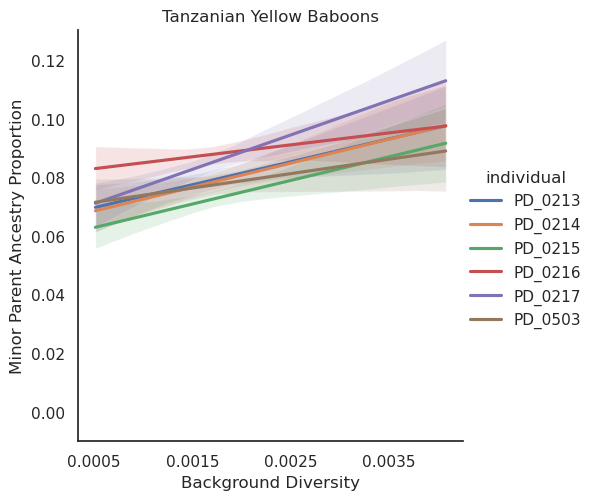

In [179]:
g = lmplot(filter_qcut_ind.loc[filter_qcut_ind.Origin.isin(["Ruaha, Tanzania"])], x="diversity", y="minor_parent_percentage",
                            scatter=False, hue="individual", ci=99.5) #Additional bootstraps makes it take long
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Background Diversity", title="Tanzanian Yellow Baboons")
g.set(ylim=(-0.01, None))
g.set(xticks=np.arange(0.0005, 0.004, 0.001))

In [ ]:
g = lmplot(admix_div_mean_ind.loc[admix_div_mean_ind.Origin.isin(yellows)], x="diversity", y="minor_parent_percentage",
                            scatter=False, hue="Origin", weighted=True, n_boot=1000, ci=99.5) #Additional bootstraps makes it take long
g.set(ylabel="Minor Parent Ancestry Proportion", xlabel="Background Diversity", title="Tanzanian Yellow Baboons")
g.set(ylim=(-0.01, None))
g.set(xticks=np.arange(0.0005, 0.004, 0.001))

Admixture per chromosome investigation

In [ ]:
ind_df = window_df_tanz_eth.groupby(["individual", "chrom", "Origin", "start", "end"])[["north_sum"]].mean().reset_index()
ind_df_div = mean_diversity.merge(ind_df, on=["chrom", "start"])
ind_df_div = ind_df_div.merge(c_r_g_df, on=["chrom", "start"])
ind_df_div["North Percentage"] = ind_df_div.north_sum/100000
ind_df_div["Species"] = ind_df_div.Origin.map(dict(zip(meta_data_samples_sci.Origin, meta_data_samples_sci.Species)))

#Selecting the cases of interest and setting Minor Parent Ancestry
origins_interest = ['Arusha, Tanzania',
       'Gog Woreda, Gambella region, Ethiopia',
       'Gog Woreda, Gambella region, Ethiopia_eth_case',
       'Gombe, Tanzania', 'Issa Valley, Tanzania',
       'Katavi, Tanzania','Lake Manyara, Tanzania',
       'Mahale, Tanzania',
       'Mikumi, Tanzania', 'Ngorongoro, Tanzania', 'Ruaha, Tanzania',
       'Selous, Tanzania', 'Serengeti, Tanzania', 'Tarangire, Tanzania',
       'Udzungwa, Tanzania']
ind_df_div = ind_df_div.loc[ind_df_div.Origin.isin(origins_interest)]
ind_df_div["minor_parent_percentage"] = [x if y == ("cynocephalus") or z == "Gog Woreda, Gambella region, Ethiopia_eth_case"
                                             else 1-x for x, y, z in zip(ind_df_div["North Percentage"],
                                                                         ind_df_div["Species"],
                                                                        ind_df_div["Origin"])]
ind_df_div = ind_df_div.loc[ind_df_div.callable_frac > 0.75]

In [ ]:
o_l, low_l, high_l, effect_l, admix_l, chr_l, ind_l = [], [], [], [], [], [], []
#filter_qcut_chrX["Diversity Quantile"] = pd.qcut(filter_qcut_chrX.diversity, 5,
#                                                       labels=["0-20","20-40",
#                                                              "40-60","60-80",
#                                                              "80-100"])

for o in ind_df_div.Origin.unique():
    print(o)
    for c in ind_df_div.chrom.unique():
        print(c)
        for i in ind_df_div.loc[(ind_df_div.Origin == o) & (ind_df_div.chrom == c)].individual.unique():
            i_s_df = ind_df_div.loc[(ind_df_div.individual == i) & (ind_df_div.chrom == c)]
            #print(i)
            o_l.append(o), ind_l.append(i), chr_l.append(c)
            i_s_df["Diversity Quantile"] = pd.qcut(i_s_df.diversity, 2,
                                                       labels=["0-50", "50-100"])
            low_mean = i_s_df.loc[i_s_df["Diversity Quantile"] == "0-50"][["minor_parent_percentage"]].mean()[0]*100
            high_mean = i_s_df.loc[i_s_df["Diversity Quantile"] == "50-100"][["minor_parent_percentage"]].mean()[0]*100
            low_l.append(low_mean)
            high_l.append(high_mean)
            effect_l.append(high_mean/low_mean)
            admix_l.append(i_s_df.minor_parent_percentage.mean())

In [ ]:
admix_df = pd.DataFrame({"Origin": o_l, "individual": ind_l, "chrom": chr_l, "Low Diversity Quantile": low_l,
              "High Diversity Quantile": high_l, "Relative Difference": effect_l, "Mean_Admixture": admix_l})
admix_df["Absolute_Difference"] = admix_df["High Diversity Quantile"]-admix_df["Low Diversity Quantile"]
admix_df["Concentration"] = admix_df["High Diversity Quantile"]/admix_df.Mean_Admixture*0.5

In [ ]:
sns.lmplot(admix_df.loc[admix_df.Origin == "Ruaha, Tanzania"],
           x="Mean_Admixture", y="Concentration")

In [ ]:
admix_df["Mean Admixture Bin"] = pd.cut(admix_df.Mean_Admixture, [0, 0.02, 0.04, 0.06,
                                                                  0.08, 0.1, 0.2, 1])
g = sns.FacetGrid(admix_df.loc[admix_df.Origin.isin(result_order_no_gog)], col="Origin",
                  col_wrap = 3, col_order=result_order_no_gog)
g.map_dataframe(sns.stripplot, y="Mean Admixture Bin", x="Concentration", alpha=.1, color="grey")
g.map_dataframe(sns.pointplot, y="Mean Admixture Bin", x="Concentration", 
                linestyles="none", capsize=.3, errorbar=("ci", 95), scale = 0.6)
#g.map_dataframe(sns.stripplot, x="minor_parent_percentage", y="Diversity Quantile", alpha=0.05)
g.set(xlim=(25, 75))
g.set_titles(col_template="{col_name}")
axes = g.axes.flatten()
for ax in g.axes.flat:
    ax.axvline(x=50, color='r', linestyle=':')
g.set(xlabel="MPA Concentration", ylabel="Autosome Admixture Bin")

In [ ]:
admix_df["Mean Admixture Bin"] = pd.cut(admix_df.Mean_Admixture, [0, 0.02, 0.04, 0.06,
                                                                  0.08, 0.1, 1])
admix_df["Species"] = admix_df.Origin.map(dict(zip(meta_data_samples_sci.Origin, meta_data_samples_sci.Species)))
g = sns.FacetGrid(admix_df.loc[admix_df.Origin.isin(result_order_no_gog)], col="Species",
                  col_wrap = 2)
g.map_dataframe(sns.pointplot, y="Mean Admixture Bin", x="Concentration", 
                linestyles="none", capsize=.3, errorbar=("ci", 95), scale = 0.6)
#g.map_dataframe(sns.stripplot, x="minor_parent_percentage", y="Diversity Quantile", alpha=0.05)
#g.set(xlim=(0, 0.25))
g.set_titles(col_template="{col_name}")
g.set(xlabel="Absolute Difference", ylabel="Mean Minor Parent Ancestry")

In [ ]:
glm_results = smf.glm(formula = "Absolute_Difference ~ Mean_Admixture+I(Mean_Admixture**2)",
                      data=admix_df.loc[admix_df.Origin == "Ruaha, Tanzania"]).fit()
print(glm_results.summary())

In [ ]:
glm_results = smf.glm(formula = "Absolute_Difference ~ Mean_Admixture", data=admix_df).fit()
print(glm_results.summary())